# 0. Data Downloading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## install finrl library
#!pip install wrds
#!pip install swig
#!pip install -q condacolab
#import condacolab
#condacolab.install()
#!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-s2vp9i97
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-s2vp9i97
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-abvzdk7h/elegantrl_177821db4c634f7c9ea8bf8732ea8006
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git /tmp/pip-install-abvzdk7h/elegantrl_177821db4c634f7c9ea8bf8732ea8006
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 24228304867bdc80165de435a598ef90b1893598
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

import torch
# import torch.nn as nn
# import torch.optim as optim

from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent, DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from stable_baselines3 import PPO, A2C, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv

from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

%matplotlib inline

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
processed = pd.read_csv('/content/drive/MyDrive/RL/processed.csv', index_col=0, parse_dates=['date', 'date_available'])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# 1. Best Out-Of-Box Model

### 0. Feature Selection

#### 0.1 Correlation, VIF, Feature Importance

In [ ]:
processed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 79464 entries, 2010-01-04 to 2023-02-28
Data columns (total 61 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   close             79464 non-null  float64       
 1   high              79464 non-null  float64       
 2   low               79464 non-null  float64       
 3   open              79464 non-null  float64       
 4   volume            79464 non-null  int64         
 5   day               79464 non-null  int64         
 6   op_inc_q          79464 non-null  float64       
 7   rev_q             79464 non-null  float64       
 8   net_inc_q         79464 non-null  float64       
 9   tot_assets        79464 non-null  float64       
 10  sh_equity         79464 non-null  float64       
 11  eps_incl_ex       79464 non-null  float64       
 12  com_eq            79464 non-null  float64       
 13  sh_outstanding    79464 non-null  float64       
 14  div_p

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Анализ корреляции с целевой переменной (например, future_return)
correlations = []
target = processed['close'].pct_change().shift(-1)  # завтрашняя доходность

for col in processed.select_dtypes(include=[np.number]).columns:
    if col != 'close':
        corr = processed[col].corr(target)
        correlations.append((col, abs(corr)))

correlations.sort(key=lambda x: x[1], reverse=True)
print("Топ-40 признаков по корреляции с будущей доходностью:")
for col, corr in correlations:
    print(f"{col}: {corr:.4f}")

Топ-40 признаков по корреляции с будущей доходностью:
forecast_1: 0.0231
forecast_3: 0.0229
open: 0.0228
forecast_4: 0.0228
low: 0.0227
forecast_5: 0.0227
forecast_2: 0.0227
high: 0.0226
rsi_30: 0.0140
enterprise_value: 0.0140
PE_ratio: 0.0140
macd: 0.0125
market_cap: 0.0125
div_per_sh: 0.0116
DPS: 0.0116
net_inc_q: 0.0104
dividend_yield: 0.0100
PB_ratio: 0.0100
PS_ratio: 0.0093
op_inc_q: 0.0082
turbulence: 0.0063
debt_ratio: 0.0061
revenue_growth: 0.0060
day: 0.0059
dx_30: 0.0058
cci_30: 0.0053
cur_ratio: 0.0043
cash_ratio: 0.0040
long_debt: 0.0040
acc_pay_turnover: 0.0039
eps_incl_ex: 0.0037
EPS: 0.0037
short_debt: 0.0037
acc_rec_turnover: 0.0034
BPS: 0.0034
cur_liabilities: 0.0033
quick_ratio: 0.0032
NPM: 0.0030
tot_liabilities: 0.0029
tot_assets: 0.0028
inventories: 0.0023
cash_eq: 0.0023
eps_growth: 0.0023
payables: 0.0022
com_eq: 0.0020
receivables: 0.0020
sh_equity: 0.0018
OPM: 0.0015
ROE: 0.0015
debt_to_equity: 0.0010
cur_assets: 0.0010
EV_EBITDA: 0.0010
sh_outstanding: 0.0009


In [ ]:
print("Топ-20 признаков по корреляции с будущей доходностью:")
for col, corr in correlations[20:]:
    print(f"{col}: {corr:.4f}")

Топ-20 признаков по корреляции с будущей доходностью:
turbulence: 0.0063
debt_ratio: 0.0061
revenue_growth: 0.0060
day: 0.0059
dx_30: 0.0058
cci_30: 0.0053
cur_ratio: 0.0043
cash_ratio: 0.0040
long_debt: 0.0040
acc_pay_turnover: 0.0039
eps_incl_ex: 0.0037
EPS: 0.0037
short_debt: 0.0037
acc_rec_turnover: 0.0034
BPS: 0.0034
cur_liabilities: 0.0033
quick_ratio: 0.0032
NPM: 0.0030
tot_liabilities: 0.0029
tot_assets: 0.0028
inventories: 0.0023
cash_eq: 0.0023
eps_growth: 0.0023
payables: 0.0022
com_eq: 0.0020
receivables: 0.0020
sh_equity: 0.0018
OPM: 0.0015
ROE: 0.0015
debt_to_equity: 0.0010
cur_assets: 0.0010
EV_EBITDA: 0.0010
sh_outstanding: 0.0009
rev_q: 0.0009
inv_turnover: 0.0007
cogs_q: 0.0006
volume: 0.0004
ROA: 0.0003


In [ ]:
# Топ признаков по корреляции + важные дополнения
TOP_CORRELATED_FEATURES = [
    # 1. Прогнозы GRU (первые 3 - самые сильные)
    'forecast_1', 'forecast_2', 'forecast_3','forecast_4', 'forecast_5',

    # 2. Ценовые данные (4 признака)
    'open', 'low', 'high', 'close',

    # 3. Объем (важен для подтверждения трендов)
    'volume',

    # 4. Технические индикаторы (4 признака)
    'rsi_30', 'macd', 'cci_30','dx_30',

    # 5. Фундаментальные (2 признака из топа)
    'PE_ratio', 'enterprise_value',

    'OPM', 'NPM', 'ROA', 'ROE', 'cur_ratio',
    'quick_ratio', 'cash_ratio',
    'inv_turnover', 'acc_rec_turnover', 'acc_pay_turnover',
    'debt_ratio','debt_to_equity', 'PB_ratio', 'dividend_yield',

    # 6. Риск-метрика
    'turbulence',

    # 7. Дивиденды (сигнал устойчивости компании)
    'div_per_sh'
]

In [ ]:
TOP_CORRELATED_FEATURES = [
    # 1. Прогнозы GRU (только лучшие 3 - остальные слишком коррелированы)
    'forecast_1', 'forecast_2', 'forecast_3',

    # 2. Ценовые данные (упрощаем - high/low/open сильно коррелируют с close)
    'close', 'open',  # open важен для gaps

    # 3. Технические индикаторы (выбираем диверсифицированные)
    'rsi_30',      # осциллятор (0.0140)
    'macd',        # тренд (0.0125)
    'dx_30',       # сила тренда (0.0058)
    # 'cci_30' исключаем - коррелирует с rsi_30 (0.0053)

    # 4. Фундаментальные (выбираем НЕкоррелирующие между собой)
    'PE_ratio',          # оценка (0.0140)
    'enterprise_value',  # размер компании (0.0140)
    'div_per_sh',        # дивиденды (0.0116)
    'debt_ratio',        # долговая нагрузка (0.0061)
    'revenue_growth',    # рост (0.0060)

    # 5. Показатели эффективности (по 1 из каждой категории)
    'NPM',               # маржа чистой прибыли (0.0030)
    # исключаем OPM, ROA, ROE - низкая корреляция

    # 6. Ликвидность (выбираем 1-2)
    'cur_ratio',         # текущая ликвидность (0.0043)
    # исключаем quick_ratio, cash_ratio - похожи

    # 7. Деловая активность (выбираем 1)
    'acc_pay_turnover',  # оборачиваемость кредиторки (0.0039)
    # исключаем inv_turnover, acc_rec_turnover - низкая корреляция

    # 8. Риск
    'turbulence',        # турбулентность (0.0063)

    # 9. Время (слабая, но может быть полезна для сезонности)
    'day',               # день месяца (0.0059)
]

print(f"Итого признаков для VIF-анализа: {len(TOP_CORRELATED_FEATURES)}")


print(f"Отобранных признаков: {len(TOP_CORRELATED_FEATURES)}")
def check_vif(features_df):
    """Проверка мультиколлинеарности через VIF"""
    vif_data = pd.DataFrame()
    vif_data["feature"] = features_df.columns

    # Вычисляем VIF
    vif_data["VIF"] = [variance_inflation_factor(features_df.values, i)
                       for i in range(len(features_df.columns))]

    return vif_data.sort_values("VIF", ascending=False)

# Создаем DataFrame с выбранными признаками
features_df = processed[TOP_CORRELATED_FEATURES].dropna()

Итого признаков для VIF-анализа: 18
Отобранных признаков: 18


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Проверяем VIF
vif_results = check_vif(features_df)
print("Мультиколлинеарность (VIF > 10 - проблема):")
print(vif_results)

Мультиколлинеарность (VIF > 10 - проблема):
             feature           VIF
4               open  11712.279644
2         forecast_3   6328.476170
3              close   5468.589397
0         forecast_1   5271.403371
1         forecast_2   2202.557631
5             rsi_30     25.049043
11        debt_ratio     14.504754
14         cur_ratio      8.083324
10        div_per_sh      6.166212
13               NPM      4.197852
15  acc_pay_turnover      3.582487
7              dx_30      3.103086
8           PE_ratio      3.087091
17               day      3.041703
9   enterprise_value      2.642484
16        turbulence      1.665835
6               macd      1.342587
12    revenue_growth      1.192416


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_feature_reduction(data, features, n_components=0.95):
    """
    Сокращение признаков с помощью PCA
    """
    df = data[features].copy().fillna(method='ffill')

    # Стандартизация
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # PCA
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(scaled_data)

    print(f"PCA результаты:")
    print(f"Оригинальные признаки: {len(features)}")
    print(f"PCA компоненты: {pca.n_components_}")
    print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

    # Важность признаков в каждой компоненте
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=features
    )

    print("\nТоп-5 признаков по важности в первой компоненте:")
    print(loadings['PC1'].abs().sort_values(ascending=False))

    return pca_data, loadings

# Если VIF показывает высокую мультиколлинеарность
pca_features, loadings = pca_feature_reduction(
    processed,
    TOP_CORRELATED_FEATURES,
    n_components=0.95  # объяснить 95% дисперсии
)

/tmp/ipython-input-3312914694.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = data[features].copy().fillna(method='ffill')


PCA результаты:
Оригинальные признаки: 18
PCA компоненты: 12
Объясненная дисперсия: 0.956

Топ-5 признаков по важности в первой компоненте:
forecast_2          0.402279
open                0.402268
close               0.402254
forecast_3          0.401960
forecast_1          0.401665
div_per_sh          0.252283
debt_ratio          0.206754
enterprise_value    0.193279
PE_ratio            0.153713
cur_ratio           0.100090
macd                0.081861
acc_pay_turnover    0.071525
revenue_growth      0.030504
rsi_30              0.029088
turbulence          0.023284
NPM                 0.007879
dx_30               0.006563
day                 0.000496
Name: PC1, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def feature_importance_analysis(data, features, target='close'):
    """Анализ важности признаков"""
    # Подготовка данных
    X = data[features].copy().fillna(method='ffill')
    y = data[target].pct_change().shift(-1)  # будущая доходность

    # Выравнивание
    aligned_idx = X.index.intersection(y.dropna().index)
    X = X.loc[aligned_idx]
    y = y.loc[aligned_idx]

    # Разделение
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )

    # Обучение
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Важность признаков
    importance = pd.DataFrame({
        'feature': features,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Топ-15 важных признаков по RandomForest:")
    print(importance.head(15).to_string())

    return importance

# Анализ
importance_df = feature_importance_analysis(processed, TOP_CORRELATED_FEATURES)

# Выбор признаков по порогу важности
threshold = 0.01  # 1%
selected_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()
print(f"\nПризнаки с важностью >{threshold}: {len(selected_features)}")
print(selected_features)

/tmp/ipython-input-3285813482.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = data[features].copy().fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#### 0.2 Visualisations

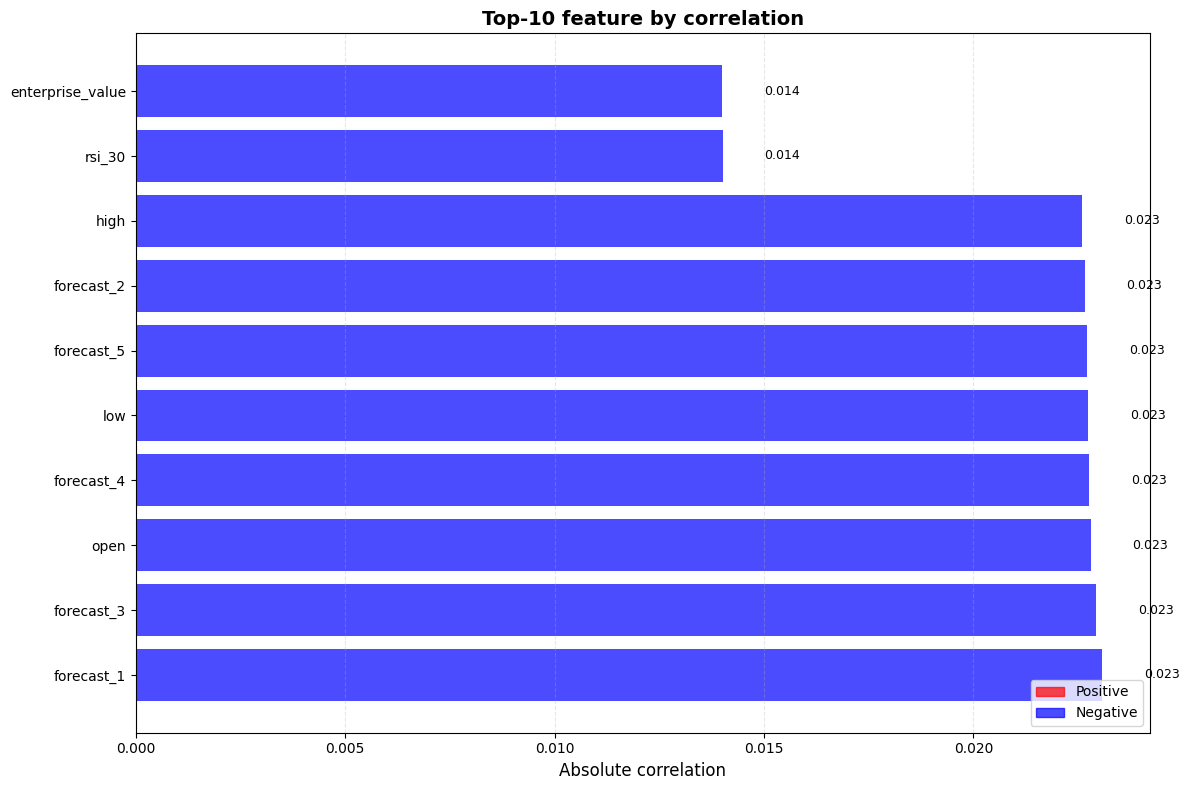

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_correlation_results(correlations, top_n=20):
    """
    График корреляций признаков с целевой переменной
    """
    # Берем топ-N признаков
    top_corr = correlations[:top_n]
    features, corr_values = zip(*top_corr)

    # Создаем цветовую схему (красный для положительной, синий для отрицательной корреляции)
    colors = ['red' if processed[feat].corr(target) > 0 else 'blue'
              for feat in features]

    fig, ax = plt.subplots(figsize=(12, 8))

    # Горизонтальный барплот
    bars = ax.barh(features, corr_values, color=colors, alpha=0.7)
    ax.set_xlabel('Absolute correlation', fontsize=12)
    ax.set_title(f'Top-{top_n} feature by correlation',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Добавляем значения на бары
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    # Линия нулевой корреляции
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

    # Легенда
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='red', alpha=0.7, label='Positive')
    blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='Negative')
    ax.legend(handles=[red_patch, blue_patch], loc='lower right')

    plt.tight_layout()
    return fig

# Использование
fig1 = plot_correlation_results(correlations, top_n=10)
plt.show()

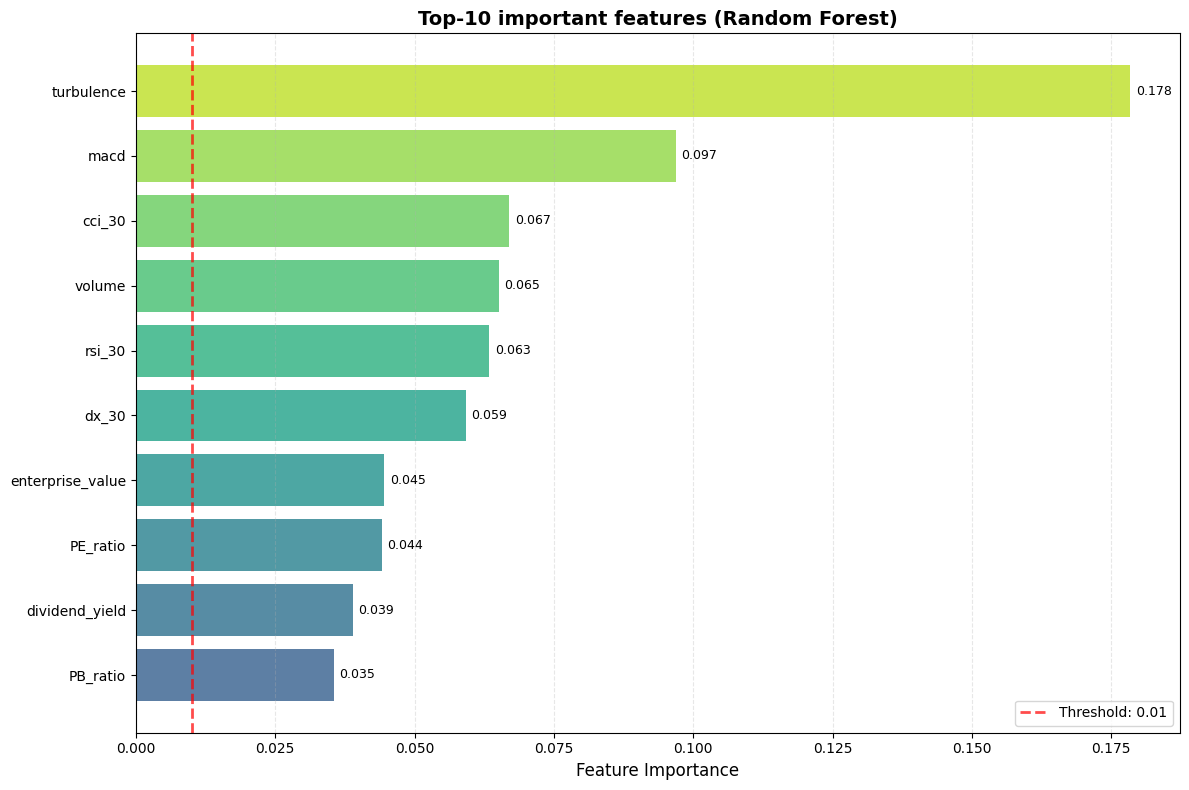

In [ ]:
def plot_feature_importance(importance_df, top_n=20, threshold=None):
    """
    График важности признаков из Random Forest
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Берем топ-N признаков
    top_features = importance_df.head(top_n).copy()

    # Сортировка для горизонтального графика
    top_features = top_features.sort_values('importance', ascending=True)

    # Создаем градиент цветов
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))

    # Горизонтальный барплот
    bars = ax.barh(top_features['feature'], top_features['importance'],
                   color=colors, alpha=0.8)

    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top-{top_n} important features (Random Forest)',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Добавляем пороговую линию если указана
    if threshold:
        ax.axvline(x=threshold, color='red', linestyle='--',
                   linewidth=2, alpha=0.7, label=f'Threshold: {threshold}')
        ax.legend()

    # Добавляем значения на бары
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    return fig

# Использование
fig2 = plot_feature_importance(importance_df, top_n=10, threshold=0.01)
plt.show()

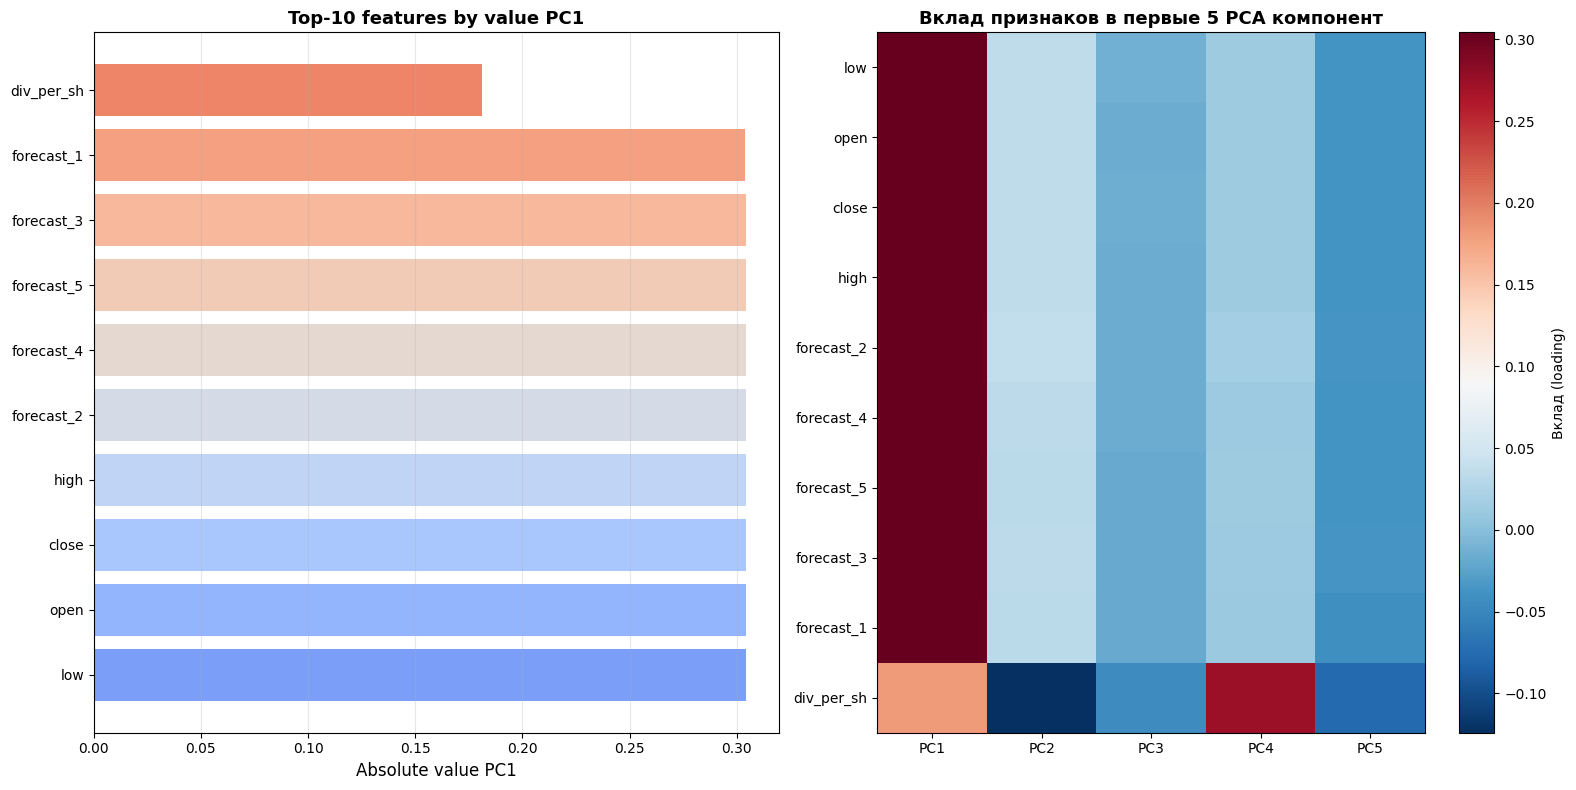

In [ ]:
def plot_pca_loadings(loadings, top_n=15):
    """
    График вклада признаков в основные PCA компоненты
    """
    # Берем топ-N признаков по первой компоненте
    top_loadings = loadings['PC1'].abs().sort_values(ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # График 1: Вклад в первую компоненту
    colors1 = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(top_loadings)))
    bars1 = axes[0].barh(top_loadings.index, top_loadings.values, color=colors1)
    axes[0].set_xlabel('Absolute value PC1', fontsize=12)
    axes[0].set_title(f'Top-{top_n} features by value PC1',
                     fontsize=13, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # График 2: Heatmap вкладов в первые 5 компонент
    # Берем топ-10 признаков по PC1 и смотрим их вклад в первые 5 компонент
    top_features = top_loadings.index[:10]
    component_loadings = loadings.loc[top_features, ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]

    # Heatmap
    im = axes[1].imshow(component_loadings.values, cmap='RdBu_r', aspect='auto')
    axes[1].set_xticks(range(5))
    axes[1].set_xticklabels(['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
    axes[1].set_yticks(range(len(top_features)))
    axes[1].set_yticklabels(top_features)
    axes[1].set_title('Вклад признаков в первые 5 PCA компонент',
                     fontsize=13, fontweight='bold')

    # Цветовая шкала
    plt.colorbar(im, ax=axes[1], label='Вклад (loading)')

    plt.tight_layout()
    return fig

# Использование
fig3 = plot_pca_loadings(loadings, top_n=10)
plt.show()

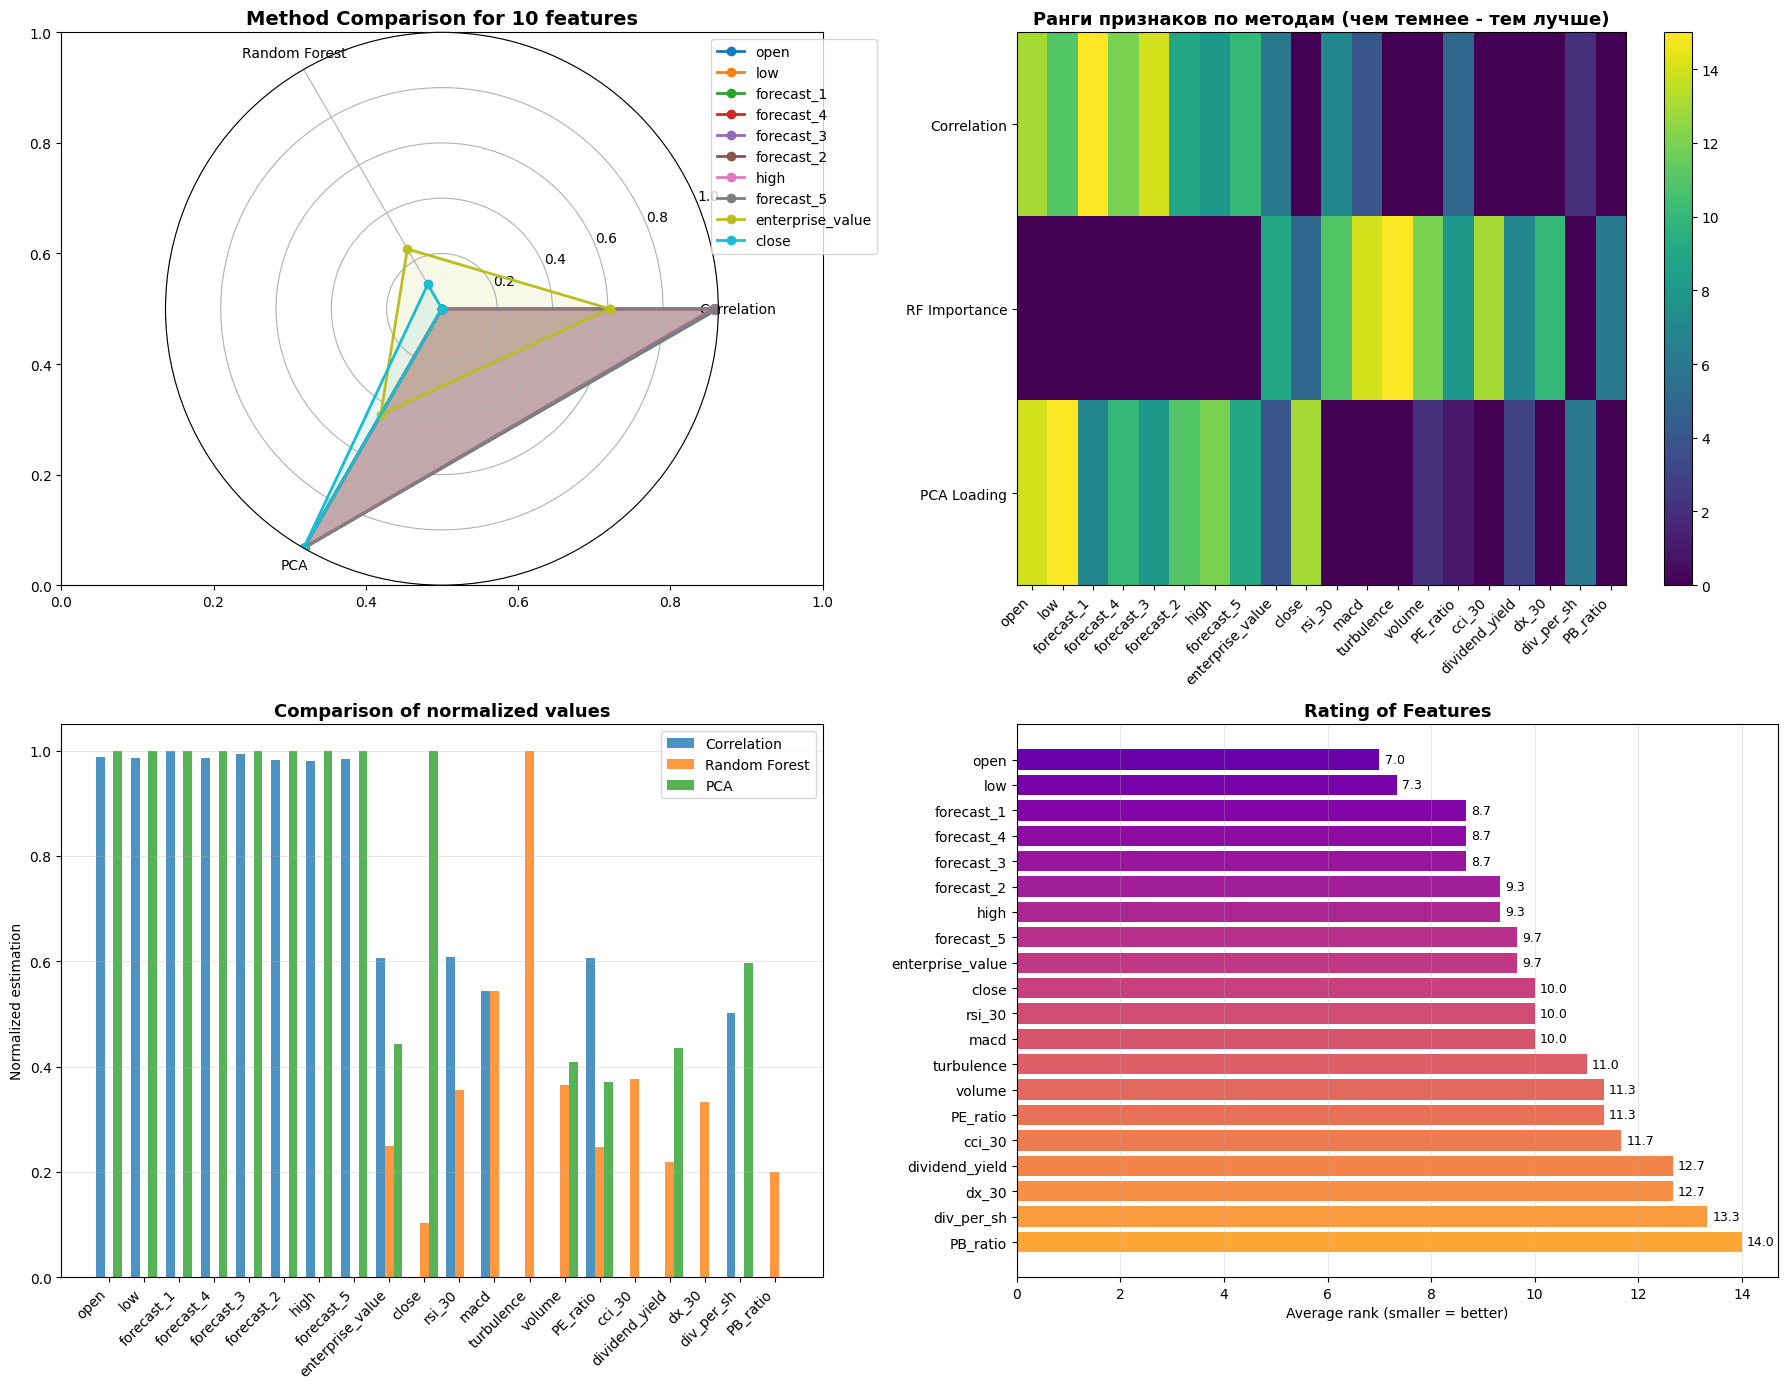

In [ ]:
def plot_comparative_analysis(correlations, importance_df, loadings, top_n=15):
    """
    Комбинированный график сравнения трех методов отбора признаков
    """
    # Подготовка данных
    # 1. Корреляции
    corr_features = [f[0] for f in correlations[:top_n]]
    corr_scores = [abs(f[1]) for f in correlations[:top_n]]

    # 2. Важность признаков
    imp_features = importance_df.head(top_n)['feature'].tolist()
    imp_scores = importance_df.head(top_n)['importance'].tolist()

    # 3. PCA loadings
    pca_features = loadings['PC1'].abs().sort_values(ascending=False).head(top_n).index.tolist()
    pca_scores = loadings['PC1'].abs().sort_values(ascending=False).head(top_n).values.tolist()

    # Находим общие признаки
    all_features = set(corr_features) | set(imp_features) | set(pca_features)

    # Создаем DataFrame для сравнения
    comparison_data = []
    for feature in all_features:
        row = {'feature': feature}

        # Получаем ранги из каждого метода
        row['corr_rank'] = corr_features.index(feature) + 1 if feature in corr_features else top_n + 1
        row['rf_rank'] = imp_features.index(feature) + 1 if feature in imp_features else top_n + 1
        row['pca_rank'] = pca_features.index(feature) + 1 if feature in pca_features else top_n + 1

        # Нормализованные оценки
        row['corr_score'] = corr_scores[corr_features.index(feature)] if feature in corr_features else 0
        row['rf_score'] = imp_scores[imp_features.index(feature)] if feature in imp_features else 0
        row['pca_score'] = pca_scores[pca_features.index(feature)] if feature in pca_features else 0

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)

    # Нормализуем оценки для сравнения
    for col in ['corr_score', 'rf_score', 'pca_score']:
        comparison_df[f'{col}_norm'] = comparison_df[col] / comparison_df[col].max()

    # Берем топ-20 признаков по сумме рангов
    comparison_df['avg_rank'] = comparison_df[['corr_rank', 'rf_rank', 'pca_rank']].mean(axis=1)
    comparison_df = comparison_df.sort_values('avg_rank').head(20)

    # Создаем график
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # График 1: Radar chart для топ-5 признаков
    top5 = comparison_df.head(10)['feature'].tolist()

    # Данные для radar chart
    categories = ['Correlation', 'Random Forest', 'PCA']
    N = len(categories)

    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    ax1 = fig.add_subplot(2, 2, 1, polar=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(top5)))

    for idx, feature in enumerate(top5):
        row = comparison_df[comparison_df['feature'] == feature].iloc[0]
        values = [row['corr_score_norm'], row['rf_score_norm'], row['pca_score_norm']]
        values += values[:1]

        ax1.plot(angles, values, 'o-', linewidth=2, label=feature, color=colors[idx])
        ax1.fill(angles, values, alpha=0.1, color=colors[idx])

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(categories)
    ax1.set_ylim(0, 1)
    ax1.set_title('Method Comparison for 10 features', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    # График 2: Heatmap рангов
    ax2 = axes[0, 1]
    rank_data = comparison_df.set_index('feature')[['corr_rank', 'rf_rank', 'pca_rank']]

    # Инвертируем ранги для лучшей визуализации (1 = лучший)
    rank_data_inv = (top_n + 1) - rank_data

    im2 = ax2.imshow(rank_data_inv.T, cmap='viridis', aspect='auto')
    ax2.set_xticks(range(len(rank_data)))
    ax2.set_xticklabels(rank_data.index, rotation=45, ha='right')
    ax2.set_yticks(range(3))
    ax2.set_yticklabels(['Correlation', 'RF Importance', 'PCA Loading'])
    ax2.set_title('Ранги признаков по методам (чем темнее - тем лучше)',
                 fontsize=13, fontweight='bold')

    plt.colorbar(im2, ax=ax2)

    # График 3: Сравнение нормализованных оценок
    ax3 = axes[1, 0]

    x = np.arange(len(comparison_df))
    width = 0.25

    bars1 = ax3.bar(x - width, comparison_df['corr_score_norm'], width,
                    label='Correlation', alpha=0.8)
    bars2 = ax3.bar(x, comparison_df['rf_score_norm'], width,
                    label='Random Forest', alpha=0.8)
    bars3 = ax3.bar(x + width, comparison_df['pca_score_norm'], width,
                    label='PCA', alpha=0.8)

    ax3.set_xticks(x)
    ax3.set_xticklabels(comparison_df['feature'], rotation=45, ha='right')
    ax3.set_ylabel('Normalized estimation')
    ax3.set_title('Comparison of normalized values',
                 fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

    # График 4: Консенсус (средний ранг)
    ax4 = axes[1, 1]

    # Сортируем по среднему рангу
    consensus_df = comparison_df.sort_values('avg_rank')

    colors_consensus = plt.cm.plasma(np.linspace(0.2, 0.8, len(consensus_df)))
    bars = ax4.barh(consensus_df['feature'], consensus_df['avg_rank'],
                    color=colors_consensus)

    ax4.set_xlabel('Average rank (smaller = better)')
    ax4.set_title('Rating of Features',
                 fontsize=13, fontweight='bold')
    ax4.invert_yaxis()  # Лучшие признаки сверху
    ax4.grid(axis='x', alpha=0.3)

    # Добавляем значения
    for bar in bars:
        width = bar.get_width()
        ax4.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    return fig, comparison_df

# Использование
fig4, comparison_df = plot_comparative_analysis(correlations, importance_df, loadings, top_n=15)
plt.show()

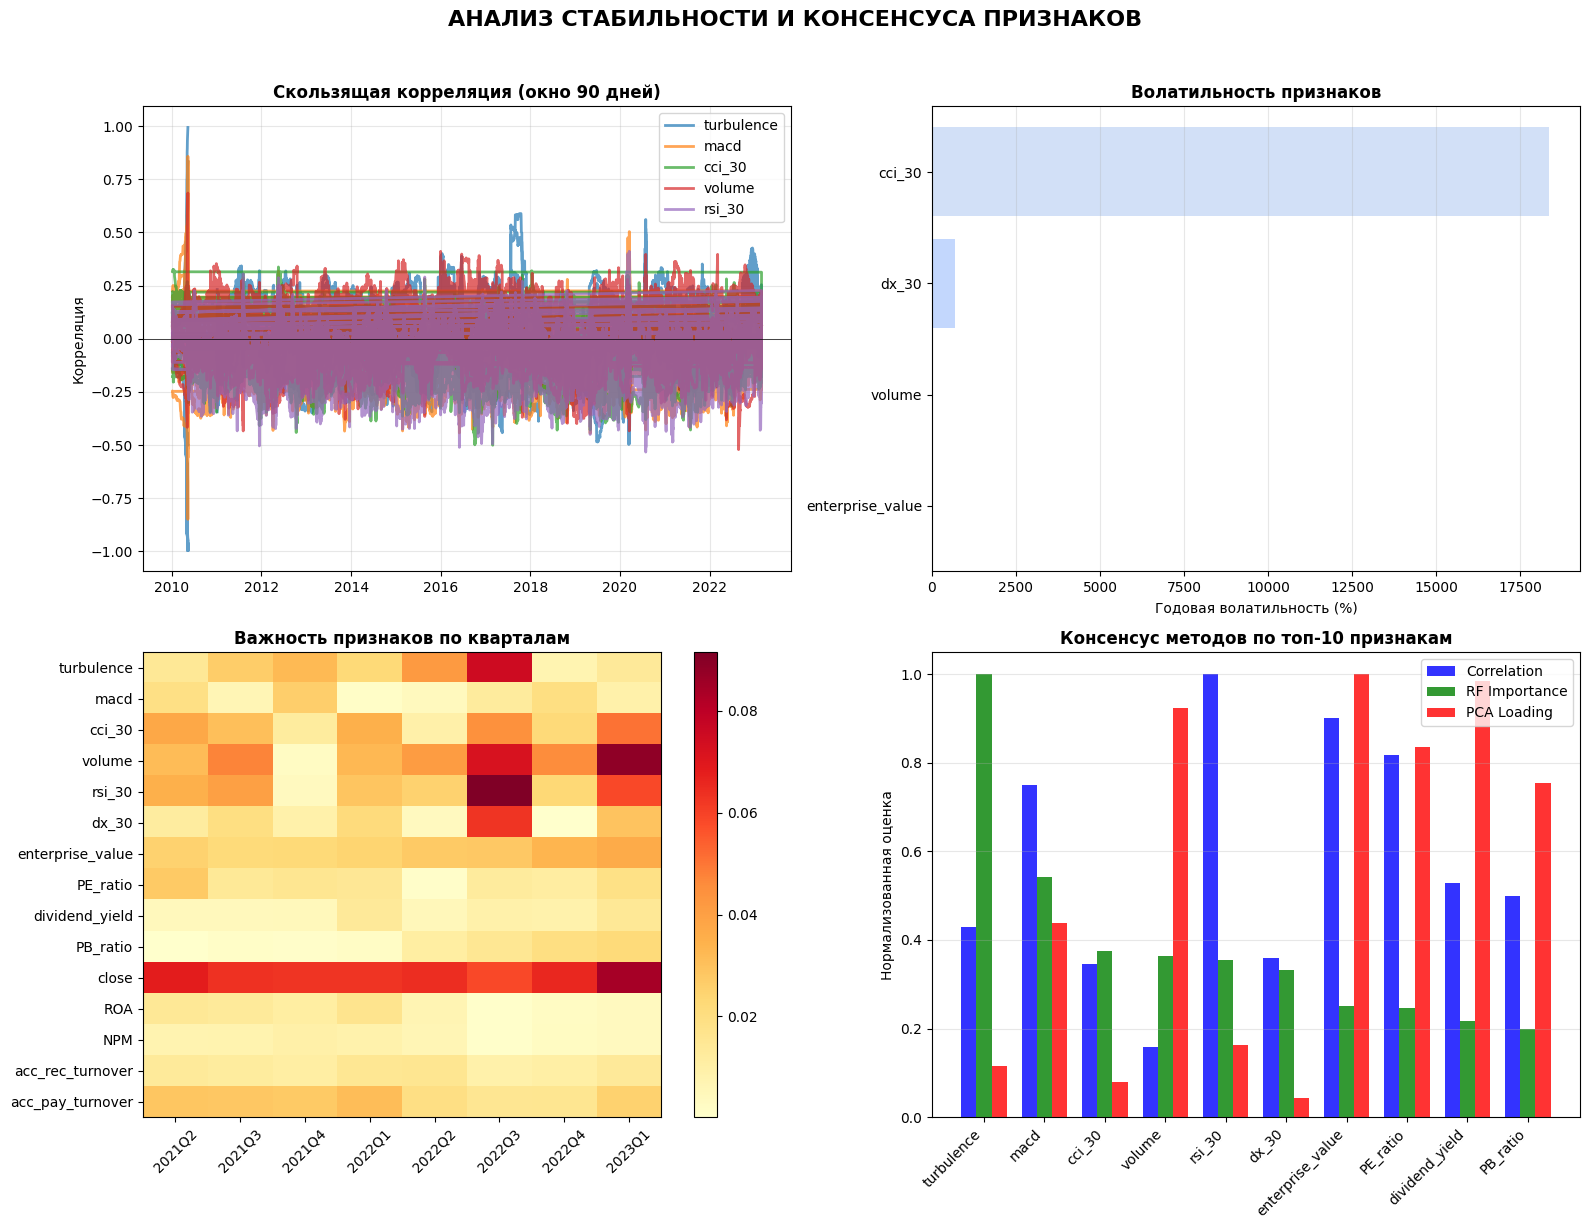

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def plot_temporal_feature_stability(data, selected_features, window_days=90):
    """
    Анализ стабильности важности признаков во времени
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Скользящая корреляция для топ-5 признаков
    top_features = selected_features[:5]

    for feature in top_features:
        # Скользящая корреляция с целевой переменной
        rolling_corr = data[feature].rolling(window=window_days).corr(
            data['close'].pct_change().shift(-1)
        )
        axes[0, 0].plot(rolling_corr.index, rolling_corr.values,
                       label=feature, linewidth=2, alpha=0.7)

    axes[0, 0].set_title(f'Скользящая корреляция (окно {window_days} дней)',
                        fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Корреляция')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # 2. Волатильность важности признаков
    volatility_data = []
    for feature in selected_features[:10]:
        feature_series = data[feature].dropna()
        # Мера изменчивости (стандартное отклонение изменений)
        volatility = feature_series.pct_change().std() * np.sqrt(252)  # Годовая волатильность
        volatility_data.append((feature, volatility))

    volatility_df = pd.DataFrame(volatility_data, columns=['feature', 'volatility'])
    volatility_df = volatility_df.sort_values('volatility')

    colors_vol = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(volatility_df)))
    axes[0, 1].barh(volatility_df['feature'], volatility_df['volatility'],
                    color=colors_vol, alpha=0.7)
    axes[0, 1].set_title('Волатильность признаков', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Годовая волатильность (%)')
    axes[0, 1].grid(axis='x', alpha=0.3)

    # 3. Heatmap важности по периодам (кварталам)
    data['quarter'] = data.index.to_period('Q')
    quarterly_importance = []

    for quarter in sorted(data['quarter'].unique())[-8:]:  # Последние 8 кварталов
        quarter_data = data[data['quarter'] == quarter]
        if len(quarter_data) > 30:  # Минимум 30 наблюдений
            correlations_q = []
            target_q = quarter_data['close'].pct_change().shift(-1)

            for feature in selected_features[:15]:
                corr = quarter_data[feature].corr(target_q)
                correlations_q.append(abs(corr) if not pd.isna(corr) else 0)

            quarterly_importance.append(correlations_q)

    if quarterly_importance:
        quarterly_df = pd.DataFrame(
            quarterly_importance,
            columns=selected_features[:15],
            index=sorted(data['quarter'].unique())[-len(quarterly_importance):]
        )

        im = axes[1, 0].imshow(quarterly_df.T, cmap='YlOrRd', aspect='auto')
        axes[1, 0].set_xticks(range(len(quarterly_df)))
        axes[1, 0].set_xticklabels([str(q) for q in quarterly_df.index], rotation=45)
        axes[1, 0].set_yticks(range(len(quarterly_df.columns)))
        axes[1, 0].set_yticklabels(quarterly_df.columns)
        axes[1, 0].set_title('Важность признаков по кварталам',
                           fontsize=12, fontweight='bold')
        plt.colorbar(im, ax=axes[1, 0])

    # 4. Матрица консенсуса методов
    consensus_matrix = np.zeros((len(selected_features[:10]), 3))

    for i, feature in enumerate(selected_features[:10]):
        # Корреляция
        corr_rank = next((idx for idx, (f, _) in enumerate(correlations)
                         if f == feature), 100)
        consensus_matrix[i, 0] = 1 / (corr_rank + 1)  # Обратный ранг

        # Random Forest
        rf_row = importance_df[importance_df['feature'] == feature]
        consensus_matrix[i, 1] = rf_row['importance'].values[0] if not rf_row.empty else 0

        # PCA
        if feature in loadings.index:
            consensus_matrix[i, 2] = abs(loadings.loc[feature, 'PC1'])

    # Нормализация
    consensus_matrix = consensus_matrix / consensus_matrix.max(axis=0)

    x = np.arange(len(selected_features[:10]))
    width = 0.25

    axes[1, 1].bar(x - width, consensus_matrix[:, 0], width,
                   label='Correlation', alpha=0.8, color='blue')
    axes[1, 1].bar(x, consensus_matrix[:, 1], width,
                   label='RF Importance', alpha=0.8, color='green')
    axes[1, 1].bar(x + width, consensus_matrix[:, 2], width,
                   label='PCA Loading', alpha=0.8, color='red')

    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(selected_features[:10], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Нормализованная оценка')
    axes[1, 1].set_title('Консенсус методов по топ-10 признакам',
                        fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.suptitle('АНАЛИЗ СТАБИЛЬНОСТИ И КОНСЕНСУСА ПРИЗНАКОВ',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    return fig

# Использование
fig5 = plot_temporal_feature_stability(processed, selected_features, window_days=90)
plt.show()

Используем только прогнозы GRU по следующим причинам:

Прогнозы GRU уже включают информацию о ценах (они обучены на них)

PCA показывает, что прогнозы имеют максимальную нагрузку в первой компоненте

Избегаем мультиколлинеарности - убираем open, close

Сохраняем информативность - прогнозы лучше чем сырые цены

Таким образом оптимальный набор

#### 0.3 Final Features

In [ ]:
OPTIMIZED_FEATURES = [
    # 1. Прогнозы GRU (2 лучших)
    'forecast_1', 'forecast_3',  # forecast_2 исключаем как промежуточный

    # 2. Технические индикаторы (3 разных типа)
    'macd',      # тренд и моментум
    'rsi_30',    # осциллятор, перекупленность
    'dx_30',     # сила тренда

    # 3. Фундаментальные (2 некоррелированных)
    'PE_ratio',          # оценка компании
    'enterprise_value',  # размер компании

    # 4. Финансовое здоровье
    'debt_ratio',        # долговая нагрузка

    # 5. Операционная эффективность
    'acc_pay_turnover',  # оборачиваемость кредиторки
    'NPM',               # чистая маржа

    # 6. Рост бизнеса
    'revenue_growth',    # рост выручки

    # 7. Риск-метрика (самый важный!)
    'turbulence',

    # 8. Временной фактор
    'day'               # день месяца для сезонности
]

In [ ]:
def check_final_vif(data, features):
    """Проверка VIF для финального набора"""
    df = data[features].copy().fillna(method='ffill')

    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(len(df.columns))
    ]

    vif_data = vif_data.sort_values("VIF", ascending=False)

    print("Мультиколлинеарность финального набора:")
    print(vif_data.to_string())
    print(f"\nМаксимальный VIF: {vif_data['VIF'].max():.2f}")
    print(f"Средний VIF: {vif_data['VIF'].mean():.2f}")

    # Проверка порогов
    high_vif = vif_data[vif_data['VIF'] > 10]
    moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]

    if len(high_vif) > 0:
        print(f"\n⚠️  ВНИМАНИЕ: {len(high_vif)} признаков с VIF > 10:")
        print(high_vif[['feature', 'VIF']].to_string())
    else:
        print("✓ Нет признаков с VIF > 10")

    return vif_data

In [ ]:
# Проверяем
# optimal_vif = check_final_vif(processed, OPTIMIZED_FEATURES)

In [ ]:
# Убираем rsi_30 и debt_ratio
# Преобразуем forecast в одну переменную
def create_forecast_features(data):
    """Создание агрегированных признаков из прогнозов"""
    df = data.copy()

    # 1. Средний прогноз
    df['forecast_mean'] = df[['forecast_1', 'forecast_3']].mean(axis=1)

    # 2. Разброс прогнозов (неопределенность)
    df['forecast_std'] = df[['forecast_1', 'forecast_3']].std(axis=1)

    # 3. Тренд прогнозов
    df['forecast_trend'] = df['forecast_3'] - df['forecast_1']

    return df

# 1. Создаем агрегированные прогнозные признаки
processed = create_forecast_features(processed)

# 2. Финальный проверенный набор
FINAL_FEATURES = [
    # Прогнозные (агрегированные)
    'forecast_mean',      # основной сигнал
    'forecast_std',       # уверенность прогноза
    'forecast_trend',     # изменение прогнозов

    # Технические
    'macd',
    'dx_30',

    # Фундаментальные
    'PE_ratio',

    # Бизнес-метрики
    'NPM',
    'acc_pay_turnover',
    'revenue_growth',

    # Риск
    'turbulence',

    # Время
    'day'
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 3. Проверяем VIF
print("Проверка финального набора...")
# final_vif = check_final_vif(processed, FINAL_FEATURES)

Проверка финального набора...


### RL Algorithms Overview for FinRL

| Algorithm | Description | When to Use | Key Logic Difference |
|-----------|-------------|-------------|----------------------|
| **A2C** | Synchronous Actor-Critic. One agent collects data and updates. | Simple environments, low compute, stability over speed. | **Synchronous**, single thread → lower variance, slower. |
| **DDPG** | Deep Deterministic Policy Gradient. Off-policy Actor-Critic for **continuous actions**. | Continuous action spaces (e.g., trade size), unstable dynamics. | **Off-policy + deterministic policy**; uses Q-learning for critic. |
| **PPO** | Proximal Policy Optimization. On-policy with **clipped probability ratio**. | **Default choice** in FinRL — stable, sample-efficient. | **On-policy + clipping** → prevents large policy shifts. |
| **TD3** | Twin Delayed DDPG. Fixes overestimation with **dual critics**, delayed updates, target noise. | Continuous actions + **Q-value overestimation** issues. | **Twin critics + delay + noise** → more robust Q-learning. |
| **SAC** | Soft Actor-Critic. Off-policy, maximizes **entropy** for exploration. | Complex environments, sparse rewards, need adaptive exploration. | **Entropy regularization** → balances exploration automatically. |


### 1.0 Setting up the Test period, Environment and Model

In [ ]:
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2021-10-01'
TEST_START_DATE = '2021-10-01'
TEST_END_DATE = '2023-03-01'

In [ ]:
processed = processed.reset_index()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
processed

,date,close,high,low,open,volume,day,op_inc_q,rev_q,net_inc_q,...,dx_30,turbulence,forecast_1,forecast_2,forecast_3,forecast_4,forecast_5,forecast_mean,forecast_std,forecast_trend
0,2010-01-04,32.555485,32.698691,32.133824,32.467973,6894300,0,843.0,6559.0,640.0,...,100.000000,0.000000,33.360706,33.869236,34.112818,34.596245,34.784816,33.736762,0.531824,0.752112
1,2010-01-05,32.483871,32.802105,32.117899,32.483871,10641200,1,843.0,6559.0,640.0,...,100.000000,0.000000,33.360706,33.869236,34.112818,34.596245,34.784816,33.736762,0.531824,0.752112
2,2010-01-06,33.008957,33.152160,32.754366,32.802102,8399400,2,843.0,6559.0,640.0,...,100.000000,0.000000,33.360706,33.869236,34.112818,34.596245,34.784816,33.736762,0.531824,0.752112
3,2010-01-07,33.544331,33.752087,32.849154,32.969010,8981700,3,843.0,6559.0,640.0,...,100.000000,0.000000,33.360706,33.869236,34.112818,34.596245,34.784816,33.736762,0.531824,0.752112
4,2010-01-08,33.520351,33.943850,33.080872,33.368529,7907700,4,843.0,6559.0,640.0,...,100.000000,0.000000,33.360706,33.869236,34.112818,34.596245,34.784816,33.736762,0.531824,0.752112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79459,2023-02-22,46.447548,47.519857,45.970962,47.262245,29844000,2,6909.0,138310.0,2730.0,...,9.765563,7.736607,47.855617,45.237896,45.117106,47.288696,46.529797,46.486361,1.936420,-2.738511
79460,2023-02-23,45.755215,46.489409,45.310830,46.489409,22021200,3,6909.0,138310.0,2730.0,...,2.963158,10.269498,47.855617,45.237896,45.117106,47.288696,46.529797,46.486361,1.936420,-2.738511
79461,2023-02-24,45.877579,45.964523,44.930849,45.352692,20623500,4,6909.0,138310.0,2730.0,...,9.425905,11.886652,47.855617,45.237896,45.117106,47.288696,46.529797,46.486361,1.936420,-2.738511
79462,2023-02-27,45.545906,46.077231,45.294732,45.954865,16647300,0,6909.0,138310.0,2730.0,...,7.162916,4.804969,47.855617,45.237896,45.117106,47.288696,46.529797,46.486361,1.936420,-2.738511


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Data Split
# Since Ensemble tested from 2022-01-03 to 2023-01-03

train_start = '2010-01-01'
train_end = '2022-01-03'
test_start = '2022-01-03'
test_end = '2023-01-03'


In [ ]:
train = data_split(processed, train_start, train_end)
trade = data_split(processed, test_start, test_end)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
A2C_model_kwargs = {
                    'n_steps': 5,
                    'ent_coef': 0.005,
                    'learning_rate': 0.0007
                    }

PPO_model_kwargs = {
                    "ent_coef":0.01,
                    "n_steps": 2048,
                    "learning_rate": 0.00025,
                    "batch_size": 128
                    }

DDPG_model_kwargs = {
                      #"action_noise":"ornstein_uhlenbeck",
                      "buffer_size": 10_000,
                      "learning_rate": 0.0005,
                      "batch_size": 64
                    }

In [ ]:
# Env kwargs
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(FINAL_FEATURES)*stock_dimension

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": [0.001]*stock_dimension,
    "sell_cost_pct": [0.001]*stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": FINAL_FEATURES,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "num_stock_shares": [0]*stock_dimension,
    "print_verbosity":5
}


In [ ]:
#Establish the training environment using StockTradingEnv() class
e_train_gym = StockTradingEnv(df = train, **env_kwargs)

In [ ]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


### 1.1 Train Out-Of-Box Models

In [ ]:
agent = DRLAgent(env = env_train)

model_ppo = agent.get_model("ppo",model_kwargs = PPO_model_kwargs)
trained_ppo = agent.train_model(model=model_ppo,
                             tb_log_name='ppo',
                             total_timesteps=10000)

In [ ]:
agent = DRLAgent(env = env_train)
model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_model_kwargs)
trained_ddpg = agent.train_model(model=model_ddpg,
                             tb_log_name='ddpg',
                             total_timesteps=10000)

In [ ]:
agent = DRLAgent(env = env_train)
model_a2c = agent.get_model("a2c",model_kwargs = A2C_model_kwargs)
trained_a2c = agent.train_model(model=model_a2c,
                             tb_log_name='a2c',
                             total_timesteps=10000)

In [ ]:
e_trade_gym = StockTradingEnv(df = trade, **env_kwargs)

In [ ]:
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment = e_trade_gym)

In [ ]:
df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
    model=trained_ddpg,
    environment = e_trade_gym)

df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c,
    environment = e_trade_gym)

NameError: name 'DRLAgent' is not defined

### 1.2 Backtest Out-Of-Box Models

In [ ]:
perf_stats_ppo = backtest_stats(account_value=df_account_value_ppo)
perf_stats_ppo = pd.DataFrame(perf_stats_ppo)

In [ ]:
perf_stats_ddpg = backtest_stats(account_value=df_account_value_ddpg)
perf_stats_ddpg = pd.DataFrame(perf_stats_ddpg)

In [ ]:
perf_stats_a2c = backtest_stats(account_value=df_account_value_a2c)
perf_stats_a2c = pd.DataFrame(perf_stats_a2c)

In [ ]:
#baseline stats
print("==============Get Baseline Stats===========")
df_dji_ = get_baseline(
        ticker="^DJI",
        start = df_account_value_ppo.loc[0,'date'],
        end = df_account_value_ppo.loc[len(df_account_value_ppo)-1,'date'])

perf_stats_dji = backtest_stats(df_dji_, value_col_name = 'close')

In [ ]:
df_dji = pd.DataFrame()
df_dji['date'] = df_account_value_ppo['date']
df_dji['dji'] = df_dji_['close'] / df_dji_['close'][0] * env_kwargs["initial_amount"]
df_dji = df_dji.set_index(df_dji.columns[0])



In [ ]:
df_result_ppo = df_account_value_ppo.set_index(df_account_value_ppo.columns[0])

NameError: name 'df_account_value_ppo' is not defined

In [ ]:
df_result_a2c = df_account_value_a2c.set_index(df_account_value_a2c.columns[0])
df_result_ddpg = df_account_value_ddpg.set_index(df_account_value_ddpg.columns[0])


In [ ]:
result = pd.DataFrame(
    {
        "a2c": df_result_a2c["account_value"],
        "ddpg": df_result_ddpg["account_value"],
        "ppo": df_result_ppo["account_value"],
        "dji": df_dji["dji"],
    }
)

NameError: name 'result' is not defined

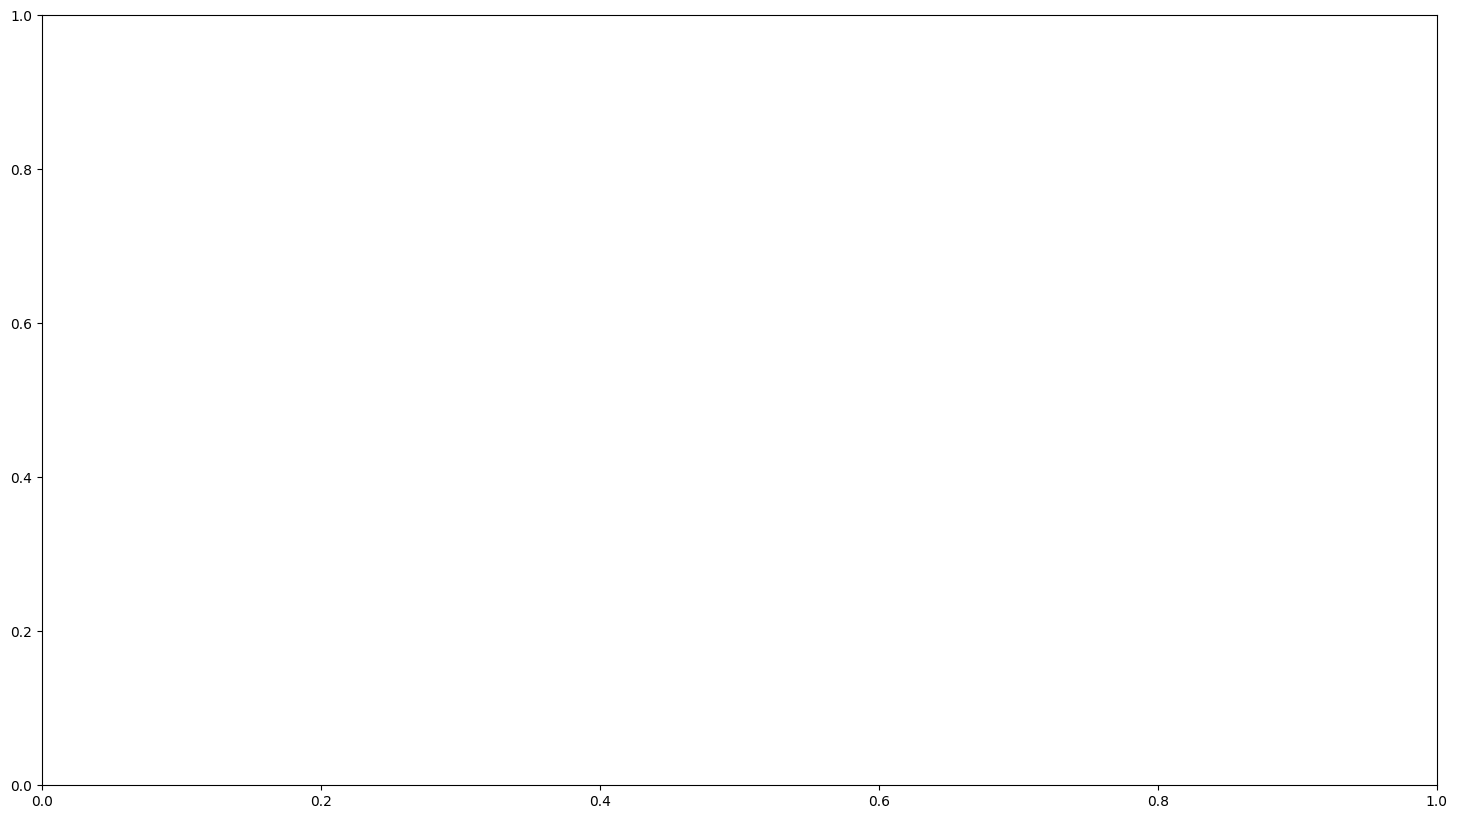

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import os
%matplotlib inline

# Ячейка: Создание основного графика (только cumulative returns)
fig, ax = plt.subplots(figsize=(18, 10))

# Цветовая схема для моделей
model_colors = {
    'a2c': '#FF6B6B',      # Красный
    'ddpg': '#4ECDC4',     # Бирюзовый
    'ppo': '#45B7D1',      # Голубой
    'dji': '#96CEB4',      # Зеленый
}

model_names_full = {
    'a2c': 'A2C',
    'ddpg': 'DDPG',
    'ppo': 'PPO',
    'dji': 'DJI Index',
}

# Проверяем, какие модели действительно есть в данных
available_models = [col for col in ['ppo', 'a2c', 'ddpg', 'dji'] if col in result.columns]
print(f"Available models in results: {available_models}")

# Убедимся, что индексы в datetime формате
if hasattr(result.index, 'dtype') and result.index.dtype == 'object':
    result.index = pd.to_datetime(result.index)

# Толщина линий (PPO - немного толще как потенциально лучшая модель)
line_widths = {
    'a2c': 3.0,
    'ddpg': 3.0,
    'ppo': 3.5,
    'dji': 3.0
}

# Сортируем модели по итоговой доходности (для порядка в легенде)
final_returns = {}
for model in available_models:
    if len(result[model].dropna()) > 0:
        final_value = result[model].dropna().iloc[-1]
        initial_value = result[model].dropna().iloc[0]
        if initial_value != 0:
            final_returns[model] = (final_value / initial_value - 1) * 100
            print(f"{model_names_full[model]}: Initial={initial_value:.2f}, Final={final_value:.2f}, Return={final_returns[model]:.2f}%")

# Сортируем модели по убыванию доходности для порядка в легенде
if final_returns:
    models_sorted = sorted(final_returns.keys(), key=lambda x: final_returns[x], reverse=True)
else:
    models_sorted = available_models

# Рисуем линии в порядке убывания доходности
for model in models_sorted:
    if model in result.columns:
        data = result[model].dropna()
        if len(data) > 1:  # Нужно как минимум 2 точки для графика
            # Нормализуем к начальному капиталу 1,000,000 для процентного отображения
            initial_value = data.iloc[0]
            normalized_data = data / initial_value * 100

            # Для DJI используем пунктирную линию, для RL моделей - сплошную
            linestyle = '--' if model == 'dji' else '-'

            # Получаем цвет модели
            color = model_colors.get(model, '#000000')  # Черный по умолчанию

            ax.plot(data.index, normalized_data,
                    label=f"{model_names_full.get(model, model)} ({final_returns.get(model, 0):.2f}%)",
                    color=color,
                    linestyle=linestyle,
                    linewidth=line_widths.get(model, 3),
                    alpha=0.9)

# Настройка графика
ax.set_title('Cumulative Returns',
             fontsize=20, fontweight='bold', pad=25, color='#2c3e50')

ax.set_ylabel('Portfolio Value (% of Initial Capital)',
              fontsize=16, fontweight='bold', labelpad=15)

ax.set_xlabel('Date', fontsize=16, fontweight='bold', labelpad=15)

# Форматирование оси Y в процентах
def percent_formatter(x, pos):
    return f'{x:.0f}%'

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

# Добавляем горизонтальную линию на уровне 100% (начальный капитал)
ax.axhline(y=100, color='black', linestyle=':', linewidth=2.0, alpha=0.7,
           label='Initial Capital (100%)')

# Добавляем фон с горизонтальными уровнями для лучшей читаемости
for level in [80, 90, 100, 110, 120, 130, 140]:
    if level == 100:
        continue  # Уже нарисовали выше
    ax.axhline(y=level, color='gray', linestyle=':', linewidth=0.8, alpha=0.2)

# Легенда
if len(models_sorted) > 0:
    legend = ax.legend(loc='upper left', fontsize=12, frameon=True,
                      framealpha=0.95, edgecolor='#2c3e50',
                      facecolor='white', title='Models (Final Return %):',
                      title_fontsize=12)
    legend.get_frame().set_linewidth(2)

# Сетка
ax.grid(True, alpha=0.3, linestyle='-', which='both')

# Добавляем аннотации для минимумов и максимумов каждой модели
for model in available_models:
    if model in result.columns:
        data = result[model].dropna()
        if len(data) > 1:
            initial_value = data.iloc[0]
            normalized_data = data / initial_value * 100

            # Находим минимум и максимум
            min_idx = normalized_data.idxmin()
            min_value = normalized_data.min()
            max_idx = normalized_data.idxmax()
            max_value = normalized_data.max()

            color = model_colors.get(model, '#000000')

            # Аннотация для минимума
            if min_value < 100:  # Только если минимум ниже начального капитала
                ax.annotate(f'{model_names_full.get(model, model)} Min: {min_value:.1f}%',
                          xy=(min_idx, min_value),
                          xytext=(min_idx, min_value - 8),
                          arrowprops=dict(arrowstyle='->',
                                         color=color,
                                         alpha=0.8,
                                         lw=1.5,
                                         connectionstyle="arc3,rad=-0.2"),
                          fontsize=10,
                          fontweight='bold',
                          color=color,
                          ha='center',
                          bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor="white",
                                   alpha=0.8,
                                   edgecolor=color))

            # Аннотация для максимума (если значительно выше 100%)
            if max_value > 105:  # Только если максимум значительно выше начального капитала
                ax.annotate(f'{model_names_full.get(model, model)} Max: {max_value:.1f}%',
                          xy=(max_idx, max_value),
                          xytext=(max_idx, max_value + 5),
                          arrowprops=dict(arrowstyle='->',
                                         color=color,
                                         alpha=0.8,
                                         lw=1.5,
                                         connectionstyle="arc3,rad=0.2"),
                          fontsize=10,
                          fontweight='bold',
                          color=color,
                          ha='center',
                          bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor="white",
                                   alpha=0.8,
                                   edgecolor=color))

# Добавляем информационный блок
if len(result) > 0:
    start_date = result.index[0].strftime('%Y-%m-%d')
    end_date = result.index[-1].strftime('%Y-%m-%d')

    info_text = f"Test Period: {start_date} to {end_date}\n"
    info_text += f"Initial Capital: $1,000,000\n"
    info_text += f"Number of Trading Days: {len(result)}\n"

    # Добавляем лучшую и худшую модели
    if final_returns:
        best_model = max(final_returns.items(), key=lambda x: x[1])
        worst_model = min(final_returns.items(), key=lambda x: x[1])

        info_text += f"\nBest: {model_names_full.get(best_model[0], best_model[0])} ({best_model[1]:.2f}%)\n"
        info_text += f"Worst: {model_names_full.get(worst_model[0], worst_model[0])} ({worst_model[1]:.2f}%)"

    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', pad=0.5)
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=props, fontfamily='monospace',
            linespacing=1.5)

# Поворот дат на оси X для лучшей читаемости
plt.xticks(rotation=45, ha='right')

# Устанавливаем отступы для осей
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

# Автоматическое масштабирование оси Y с небольшим запасом
if len(result) > 0:
    all_values = []
    for model in available_models:
        if model in result.columns:
            data = result[model].dropna()
            if len(data) > 0:
                initial_value = data.iloc[0]
                normalized = data / initial_value * 100
                all_values.extend(normalized.values)

    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        y_padding = max((y_max - y_min) * 0.1, 5)  # Минимальный запас 5%
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

# Добавляем подзаголовок с информацией о гиперпараметрах
if 'ppo' in result.columns:
    plt.figtext(0.5, 0.01,
                "RL Algorithms Comparison: PPO vs A2C vs DDPG vs DJI Benchmark",
                ha='center', fontsize=12, style='italic', color='#555555')

plt.tight_layout()
plt.show()

# Сохранение графика
save_dir = "/content/drive/MyDrive/RL/visualizations"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(f'{save_dir}/cumulative_returns_base.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

print(f"✓ График сохранен: {save_dir}/cumulative_returns_base.png")
print(f"  Размер: {fig.get_size_inches()[0]:.0f}x{fig.get_size_inches()[1]:.0f} inches")
print(f"  Разрешение: 300 DPI")

# Также сохраняем в SVG для векторного формата
fig.savefig(f'{save_dir}/cumulative_returns_base.svg',
            format='svg',
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
print(f"✓ Векторная версия сохранена: {save_dir}/cumulative_returns_base.svg")

In [ ]:
all_models = {
    'PPO': perf_stats_ppo,
    'DDPG': perf_stats_ddpg,
    'A2C': perf_stats_a2c,
    'DJI': perf_stats_dji
}
summary_metrics = pd.DataFrame()
key_metrics = [
    'Cumulative returns',
    'Annual return',
    'Annual volatility',
    'Sharpe ratio',
    'Max drawdown'
]
for model_name, model_stats in all_models.items():
    if model_stats is not None:

        if isinstance(model_stats, pd.DataFrame):
            if model_stats.shape[1] == 1:
                model_series = model_stats.iloc[:, 0]
            else:
                model_series = model_stats.iloc[:, 0]
        elif isinstance(model_stats, pd.Series):
            model_series = model_stats
        else:
            print(f"  Пропускаю {model_name} - неподдерживаемый формат")
            continue

        metrics_dict = {}

        for metric in key_metrics:
            if metric in model_series.index:
                metrics_dict[metric] = model_series[metric]
            else:
                found = False
                for idx in model_series.index:
                    if metric.lower() in str(idx).lower():
                        metrics_dict[metric] = model_series[idx]
                        found = True
                        break
                if not found:
                    metrics_dict[metric] = np.nan
                    print(f"  Метрика '{metric}' не найдена в {model_name}")

        summary_metrics[model_name] = pd.Series(metrics_dict)

summary_metrics = summary_metrics.T

print(summary_metrics)

In [ ]:
summary_metrics.sort_values("Cumulative returns", ascending=False)

Best Model - PPO

- It'll be used for experimentation

 ### 1.3 Applicability of GRU features?

Compare PPO on GRU vs PPO with technical indicators

In [ ]:

df = YahooDownloader(start_date = train_start,
                     end_date = test_end,
                     ticker_list = DOW_30_TICKER).fetch_data()


In [ ]:
INDICATORS = ['macd',
              'rsi_30',
              'cci_30',
              'dx_30']
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_turbulence=True,
                     user_defined_feature = False)

techs = fe.preprocess_data(df)
techs = techs.copy()
techs = techs.fillna(0)
techs = techs.replace(np.inf,0)

In [ ]:
stock_dimension = len(techs.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

In [ ]:
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": [0.001]*stock_dimension,
    "sell_cost_pct": [0.001]*stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5
}

In [ ]:
train_tech = data_split(techs, train_start, train_end)
trade_tech = data_split(techs, test_start, test_end)


In [ ]:

#Establish the training environment using StockTradingEnv() class
e_train_gym_tech = StockTradingEnv(df = train_tech, num_stock_shares=[0]*stock_dimension,**env_kwargs)
env_train_tech, _ = e_train_gym_tech.get_sb_env()
print(type(env_train_tech))
agent_tech = DRLAgent(env = env_train_tech)
PPO_model_kwargs = {
                    "ent_coef":0.01,
                    "n_steps": 2048,
                    "learning_rate": 0.00025,
                    "batch_size": 128
                    }
model_ppo_tech = agent_tech.get_model("ppo",model_kwargs = PPO_model_kwargs)
trained_ppo_tech = agent_tech.train_model(model=model_ppo_tech,
                             tb_log_name="ppo",total_timesteps=10000)

In [ ]:
e_trade_gym_tech = StockTradingEnv(df = trade_tech, num_stock_shares=[0]*stock_dimension,**env_kwargs)
env_trade_tech, _ = e_trade_gym_tech.get_sb_env()
df_account_value_ppo_tech, df_actions_ppo_tech = DRLAgent.DRL_prediction(
    model=trained_ppo_tech,
    environment = e_trade_gym_tech)
perf_stats_ppo_tech = backtest_stats(account_value=df_account_value_ppo_tech)
perf_stats_ppo_tech = pd.DataFrame(perf_stats_ppo_tech)

In [ ]:
perf_stats_ppo

In [ ]:
perf_stats_ppo_tech

# 2. Combinations

## In the next section I'll test 6 different approaches using PPO model

- There're 3 different reward functions and 2 NN of policies


### 2.1 Reward functions


#### 2.1.1 Custom Environment with Quadratic Utility Reward

In [ ]:
state_space

313

In [ ]:
# Custom Environment with Quadratic Utility Reward
class CustomStockTradingEnv(StockTradingEnv):
    """
    Функция награды (адаптированная для среды FinRL):
    R_t = (σ_tgt / σ_{t-1}) * [ A_{t-1} * r_t — λ * (A_{t-1} * r_t)^2 ] — bp * p_{t-1} * | (σ_tgt/σ_{t-1})*A_{t-1} — (σ_tgt/σ_{t-2})*A_{t-2} |

    Где:
    - μ: масштабирующий коэффициент (risk aversion или leverage)
    - A_{t-1}: нормализованная позиция на предыдущем шаге
    - σ_tgt: целевая волатильность
    - σ_{t-1}: реализованная волатильность на предыдущем шаге
    - r_t: доходность актива
    - bp: стоимость транзакции (basis points)
    - p_{t-1}: цена актива на предыдущем шаге
    """

    def __init__(self, *args, sigma_target=0.15/252**0.5, lambda_param=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        # Параметры функции награды
        self.sigma_target = sigma_target  # целевая дневная волатильность (15% годовых / √252)
        self.lambda_param = lambda_param  # коэффициент неприятия риска

        # Для отслеживания истории
        self.previous_price = None
        self.previous_total_asset = None
        self.previous_position = None
        self.previous_sigma = None

        # История доходностей для расчета волатильности
        self.returns_history = []
        self.window_size = 20  # окно для расчета волатильности

    def _calculate_reward(self, action):
        # Текущие значения
        current_price = self.state[2]  # цена актива
        current_total_asset = self.state[0]  # общий капитал

        # Инициализация на первом шаге
        if self.previous_price is None:
            self.previous_price = current_price
            self.previous_total_asset = current_total_asset
            self.previous_position = self.state[1]  # количество акций
            self.previous_sigma = 0.01  # начальное значение волатильности
            return 0

        # 1. Рассчитываем доходность актива
        asset_return = (current_price - self.previous_price) / self.previous_price

        # 2. Обновляем историю доходностей и рассчитываем волатильность
        self.returns_history.append(asset_return)
        if len(self.returns_history) > self.window_size:
            self.returns_history.pop(0)

        # Текущая оценка волатильности (σ_{t-1} для следующего шага)
        current_sigma = np.std(self.returns_history) if len(self.returns_history) > 1 else 0.01

        # 3. Рассчитываем нормализованную позицию A_{t-1}
        # В статье: A ∈ [-1, 1] - нормализованная позиция
        # У нас: позиция в акциях, нормализуем к максимально возможной
        max_position = self.previous_total_asset / self.previous_price
        A_t_minus_1 = self.previous_position / max_position if max_position > 0 else 0

        # 4. Рассчитываем r_t (аддитивная доходность на одну единицу позиции)
        # В статье: r_t = p_t - p_{t-1} (для одного контракта)
        # У нас адаптируем: r_t = (p_t - p_{t-1}) / p_{t-1} (доходность)
        r_t = asset_return

        # 5. Основная часть функции награды: квадратичная полезность с волатильностным масштабированием
        scale_factor = self.sigma_target / self.previous_sigma if self.previous_sigma > 0 else 1.0

        # Квадратичная полезность: A_{t-1} * r_t - λ * (A_{t-1} * r_t)^2
        position_return = A_t_minus_1 * r_t
        utility = position_return - self.lambda_param * (position_return ** 2)

        # Масштабируем
        reward_before_cost = scale_factor * utility

        # 6. Транзакционные издержки (адаптировано под нашу среду)
        # В статье: bp * p_{t-1} * | (σ_tgt/σ_{t-1})*A_{t-1} - (σ_tgt/σ_{t-2})*A_{t-2} |
        # У нас упрощаем: стандартные издержки среды

        # Рассчитываем изменение позиции в нормализованном виде
        current_max_position = current_total_asset / current_price if current_price > 0 else 0
        A_t = self.state[1] / current_max_position if current_max_position > 0 else 0

        # Транзакционные издержки как в оригинальной статье
        if hasattr(self, 'previous_scale_factor') and hasattr(self, 'previous_A_t_minus_2'):
            # Если есть данные о двух предыдущих шагах
            cost = self.buy_cost_pct * self.previous_price * abs(
                scale_factor * A_t_minus_1 - self.previous_scale_factor * self.previous_A_t_minus_2
            )
        else:
            # Упрощенный расчет на первых шагах
            trades = action - self.previous_position
            cost = np.abs(trades) * current_price * self.buy_cost_pct

        # 7. Итоговая награда
        step_reward = reward_before_cost * self.previous_total_asset - cost

        # 8. Сохраняем значения для следующего шага
        self.previous_price = current_price
        self.previous_total_asset = current_total_asset
        self.previous_position = self.state[1]

        # Для расчета издержек на следующем шаге
        self.previous_A_t_minus_2 = A_t_minus_1
        self.previous_scale_factor = scale_factor
        self.previous_sigma = current_sigma

        return step_reward * self.reward_scaling

    def reset(self, seed=None, options=None):
        """
        Переопределяем reset с поддержкой seed для Stable-Baselines3
        """
        # Вызываем родительский reset с seed, если он поддерживается
        try:
            state = super().reset(seed=seed)
        except TypeError:
            # Если родительский класс не принимает seed
            state = super().reset()

        # Сбрасываем наши дополнительные переменные
        self.previous_price = None
        self.previous_total_asset = None
        self.previous_position = None
        self.previous_sigma = None
        self.previous_scale_factor = None
        self.previous_A_t_minus_2 = None
        self.returns_history = []

        return state



# Env kwargs
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(FINAL_FEATURES)*stock_dimension



#### 2.1.2 Custom Environment
- "Deep Reinforcement Learning for Trading" Zihao Zhang, Stefan Zohren, and Stephen Roberts

In [ ]:
class ZhangStockTradingEnv(StockTradingEnv):
    """
    Среда с функцией вознаграждения из статьи:
    Zihao Zhang, Stefan Zohren, Stephen Roberts.
    "Deep Reinforcement Learning for Trading" (2019) [citation:2][citation:6].

    Функция награды (адаптированная для среды FinRL):
    R_t = μ * [ A_{t-1} * (σ_tgt / σ_{t-1}) * r_t — bp * p_{t-1} * | (σ_tgt/σ_{t-1}) * A_{t-1} — (σ_tgt/σ_{t-2}) * A_{t-2} | ]

    Где:
    - μ: масштабирующий коэффициент (risk aversion или leverage)
    - A_{t-1}: нормализованная позиция на предыдущем шаге
    - σ_tgt: целевая волатильность
    - σ_{t-1}: реализованная волатильность на предыдущем шаге
    - r_t: доходность актива
    - bp: стоимость транзакции (basis points)
    - p_{t-1}: цена актива на предыдущем шаге
    """
    def __init__(self, *args, sigma_target=0.15/252**0.5, mu=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        # Параметры функции награды из статьи Zhang et al.
        self.sigma_target = sigma_target  # целевая дневная волатильность
        self.mu = mu  # коэффициент масштабирования (μ в формуле)

        # Для отслеживания истории (аналогично вашему классу)
        self.previous_price = None
        self.previous_total_asset = None
        self.previous_position = None
        self.previous_sigma = None
        self.previous_A_t_minus_2 = None
        self.previous_scale_factor = None

        # История доходностей для расчета волатильности
        self.returns_history = []
        self.window_size = 20  # окно для расчета волатильности

    def _calculate_reward(self, action):
        """
        Вычисляет награду по формуле из статьи Zhang et al.
        R_t = μ * [ A_{t-1} * (σ_tgt / σ_{t-1}) * r_t — bp * p_{t-1} * | (σ_tgt/σ_{t-1}) * A_{t-1} — (σ_tgt/σ_{t-2}) * A_{t-2} | ]
        """
        # Текущие значения
        current_price = self.state[2]  # цена актива
        current_total_asset = self.state[0]  # общий капитал

        # Инициализация на первом шаге
        if self.previous_price is None:
            self.previous_price = current_price
            self.previous_total_asset = current_total_asset
            self.previous_position = self.state[1]  # количество акций
            self.previous_sigma = 0.01  # начальное значение волатильности
            return 0

        # 1. Рассчитываем доходность актива
        # ВАЖНО: В оригинальной статье r_t может быть определено как p_t - p_{t-1} (абсолютное изменение)
        # или как (p_t - p_{t-1})/p_{t-1} (относительное). Мы используем относительное для согласованности.
        asset_return = (current_price - self.previous_price) / self.previous_price

        # 2. Обновляем историю доходностей и рассчитываем волатильность
        self.returns_history.append(asset_return)
        if len(self.returns_history) > self.window_size:
            self.returns_history.pop(0)

        # Текущая оценка волатильности (σ_{t-1} для следующего шага)
        current_sigma = np.std(self.returns_history) if len(self.returns_history) > 1 else 0.01

        # 3. Рассчитываем нормализованную позицию A_{t-1}
        # В статье: A ∈ [-1, 1] - нормализованная позиция (long/short)
        max_position = self.previous_total_asset / self.previous_price if self.previous_price > 0 else 0
        A_t_minus_1 = self.previous_position / max_position if max_position > 0 else 0

        # Ограничиваем диапазон позиции в соответствии со статьей
        A_t_minus_1 = np.clip(A_t_minus_1, -1.0, 1.0)

        # 4. Коэффициент масштабирования волатильности
        scale_factor = self.sigma_target / self.previous_sigma if self.previous_sigma > 0 else 1.0

        # 5. ОСНОВНАЯ ЧАСТЬ ФОРМУЛЫ
        # В статье Zhang et al.: A_{t-1} * (σ_tgt/σ_{t-1}) * r_t
        # НЕТ квадратичного члена λ * (A_{t-1} * r_t)^2
        position_scaled_return = A_t_minus_1 * scale_factor * asset_return

        # 6. Транзакционные издержки
        # bp * p_{t-1} * | (σ_tgt/σ_{t-1})*A_{t-1} - (σ_tgt/σ_{t-2})*A_{t-2} |
        transaction_cost = 0.0
        if hasattr(self, 'previous_scale_factor') and hasattr(self, 'previous_A_t_minus_2'):
            # Если есть данные о двух предыдущих шагах
            term1 = scale_factor * A_t_minus_1
            term2 = self.previous_scale_factor * self.previous_A_t_minus_2
            position_change = abs(term1 - term2)

            # bp преобразуется в процент от стоимости транзакции
            # В статье bp - basis points, у нас buy_cost_pct - процент
            transaction_cost = self.buy_cost_pct * self.previous_price * position_change
        else:
            # Упрощенный расчет на первых шагах
            trades = action - self.previous_position
            transaction_cost = np.abs(trades) * current_price * self.buy_cost_pct

        # 7. Итоговая награда по формуле статьи
        # R_t = μ * [position_scaled_return - transaction_cost]
        reward_before_scaling = position_scaled_return - transaction_cost
        step_reward = self.mu * reward_before_scaling * self.previous_total_asset

        # 8. Сохраняем значения для следующего шага
        self.previous_price = current_price
        self.previous_total_asset = current_total_asset
        self.previous_position = self.state[1]

        # Для расчета издержек на следующем шаге
        self.previous_A_t_minus_2 = A_t_minus_1
        self.previous_scale_factor = scale_factor
        self.previous_sigma = current_sigma

        return step_reward * self.reward_scaling

    def reset(self, seed=None, options=None):
        """
        Переопределяем reset с поддержкой seed для Stable-Baselines3.
        """
        try:
            state = super().reset(seed=seed)
        except TypeError:
            state = super().reset()

        # Сбрасываем наши дополнительные переменные
        self.previous_price = None
        self.previous_total_asset = None
        self.previous_position = None
        self.previous_sigma = None
        self.previous_scale_factor = None
        self.previous_A_t_minus_2 = None
        self.returns_history = []

        return state

#### 2.1.3 FinRL Environment

In [ ]:
# Defined Before
# e_train_gym = StockTradingEnv(df = train, **env_kwargs)
# env_train, _ = e_train_gym.get_sb_env()
# e_trade_gym = StockTradingEnv(df = trade, **env_kwargs)

In [ ]:
sigma_target = 0.15 / (252 ** 0.5)  # Целевая волатильность (15% годовых)
lambda_param = 0.01  # Коэффициент неприятия риска для вашей функции
mu_param = 1.0  # Коэффициент масштабирования для функции Zhang
finrl_policy_kwargs = None

### 2.2 Custom Policy

In [ ]:
import torch
custom_policy_kwargs = dict(
    net_arch=dict(
        pi=[256, 128],  # Сеть актора: 313 -> 256 -> 128 -> action
        vf=[256, 128]   # Сеть критика: 313 -> 256 -> 128 -> 1
    ),
    activation_fn=torch.nn.ReLU,
    ortho_init=False
)

### 2.3 Creating Combinations

In [ ]:
# ==================== СОЗДАНИЕ ВСЕХ 6 КОНФИГУРАЦИЙ ====================
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": [0.001]*stock_dimension,
    "sell_cost_pct": [0.001]*stock_dimension,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": FINAL_FEATURES,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5
}

# 1. PPO, FinRL env, FinRL policy
e_train_finrl_finrl = StockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension, **env_kwargs)
env_train_finrl_finrl, _ = e_train_finrl_finrl.get_sb_env()
e_trade_finrl_finrl = StockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                      turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# 2. PPO, FinRL env, Custom policy
e_train_finrl_custom = StockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension, **env_kwargs)
env_train_finrl_custom, _ = e_train_finrl_custom.get_sb_env()
e_trade_finrl_custom = StockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                      turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# 3. PPO, Zhang env, FinRL policy
e_train_zhang_finrl = ZhangStockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension,
                                          sigma_target=sigma_target, mu=mu_param, **env_kwargs)
env_train_zhang_finrl, _ = e_train_zhang_finrl.get_sb_env()
e_trade_zhang_finrl = ZhangStockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                          sigma_target=sigma_target, mu=mu_param,
                                          turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# 4. PPO, Zhang env, Custom policy
e_train_zhang_custom = ZhangStockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension,
                                           sigma_target=sigma_target, mu=mu_param, **env_kwargs)
env_train_zhang_custom, _ = e_train_zhang_custom.get_sb_env()
e_trade_zhang_custom = ZhangStockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                           sigma_target=sigma_target, mu=mu_param,
                                           turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# 5. PPO, Custom env, FinRL policy
e_train_custom_finrl = CustomStockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension,
                                            sigma_target=sigma_target, lambda_param=lambda_param, **env_kwargs)
env_train_custom_finrl, _ = e_train_custom_finrl.get_sb_env()
e_trade_custom_finrl = CustomStockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                            sigma_target=sigma_target, lambda_param=lambda_param,
                                            turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# 6. PPO, Custom env, Custom policy
e_train_custom_custom = CustomStockTradingEnv(df=train, num_stock_shares=[0]*stock_dimension,
                                             sigma_target=sigma_target, lambda_param=lambda_param, **env_kwargs)
env_train_custom_custom, _ = e_train_custom_custom.get_sb_env()
e_trade_custom_custom = CustomStockTradingEnv(df=trade, num_stock_shares=[0]*stock_dimension,
                                             sigma_target=sigma_target, lambda_param=lambda_param,
                                             turbulence_threshold=70, risk_indicator_col='turbulence', **env_kwargs)

# Словарь для удобного доступа ко всем конфигурациям
train_environments = {
    'finrl_finrl': (env_train_finrl_finrl, e_train_finrl_finrl, finrl_policy_kwargs),
    'finrl_custom': (env_train_finrl_custom, e_train_finrl_custom, custom_policy_kwargs),
    'zhang_finrl': (env_train_zhang_finrl, e_train_zhang_finrl, finrl_policy_kwargs),
    'zhang_custom': (env_train_zhang_custom, e_train_zhang_custom, custom_policy_kwargs),
    'custom_finrl': (env_train_custom_finrl, e_train_custom_finrl, finrl_policy_kwargs),
    'custom_custom': (env_train_custom_custom, e_train_custom_custom, custom_policy_kwargs)
}

trade_environments = {
    'finrl_finrl': e_trade_finrl_finrl,
    'finrl_custom': e_trade_finrl_custom,
    'zhang_finrl': e_trade_zhang_finrl,
    'zhang_custom': e_trade_zhang_custom,
    'custom_finrl': e_trade_custom_finrl,
    'custom_custom': e_trade_custom_custom
}


### 2.4 Train & Backtest 6 different approaches
- PPO, FinRL env, FinRL policy
- PPO, FinRL env, Custom policy
- PPO, Zhang env, FinRL policy
- PPO, Zhang env, Custom policy
- PPO, Custom env, FinRL policy
- PPO, Custom env, Custom policy

In [ ]:
# Словарь для хранения обученных моделей
trained_models = {}
training_results = {}


for config_name, (env_train, e_train, policy_kwargs) in train_environments.items():
    print(f"\n📊 Обучение модели: {config_name}")
    print(f"   Среда: {config_name.split('_')[0]}, Политика: {config_name.split('_')[1]}")

    try:
        # Создание агента DRL
        agent = DRLAgent(env=env_train)

        # Получение модели PPO с соответствующими параметрами политики
        if policy_kwargs is not None:
            print(f"   Используется custom policy: {policy_kwargs['net_arch']}")
            model = agent.get_model("ppo",
                                   model_kwargs=PPO_model_kwargs,
                                   policy_kwargs=policy_kwargs,
                                   verbose=1)
        else:
            print("   Используется стандартная политика FinRL")
            model = agent.get_model("ppo",
                                   model_kwargs=PPO_model_kwargs,
                                   verbose=1)

        # Обучение модели
        print(f"   Обучение на {10000} шагах...")
        trained_model = agent.train_model(model=model,
                                        tb_log_name=f"ppo_{config_name}",
                                        total_timesteps=10000)

        # Сохранение обученной модели
        trained_models[config_name] = trained_model
        print(f"   ✅ Модель {config_name} успешно обучена")

    except Exception as e:
        print(f"   ❌ Ошибка при обучении {config_name}: {str(e)}")
        trained_models[config_name] = None

print("\n" + "=" * 60)
print(f"Обучение завершено. Успешно обучено моделей: "
      f"{sum(1 for m in trained_models.values() if m is not None)} из 6")


📊 Обучение модели: finrl_finrl
   Среда: finrl, Политика: finrl
   Используется стандартная политика FinRL
{'ent_coef': 0.01, 'n_steps': 2048, 'learning_rate': 0.00025, 'batch_size': 128}
Using cuda device
   Обучение на 10000 шагах...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| time/              |             |
|    fps             | 107         |
|    iterations      | 1           |
|    time_elapsed    | 18          |
|    total_timesteps | 2048        |
| train/             |             |
|    reward          | 2.3621893   |
|    reward_max      | 7.4119687   |
|    reward_mean     | 0.096684285 |
|    reward_min      | -14.723205  |
------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 101         |
|    iterations           | 2           |
|    time_elapsed         | 40          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012525504 |
|    clip_fraction        | 0.166       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | 0.0177      |
|    learning_rate        | 0.00025     |
|    loss 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 95          |
|    iterations           | 3           |
|    time_elapsed         | 64          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.016023107 |
|    clip_fraction        | 0.181       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | -0.0016     |
|    learning_rate        | 0.00025     |
|    loss                 | 24.5        |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0153     |
|    reward               | -0.5323888  |
|    reward_max           | 21.585304   |
|    reward_mean          | 0.089870095 |
|    reward_min           | -24.275345  |
|    std                  | 1           |
|    value_loss           | 63.7        |
-----------------------------------------


...

-----------------------------------------
| time/                   |             |
|    fps                  | 77          |
|    iterations           | 3           |
|    time_elapsed         | 78          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 2238776.8   |
|    clip_fraction        | 0.994       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | -0.459      |
|    learning_rate        | 0.00025     |
|    loss                 | 69          |
|    n_updates            | 20          |
|    policy_gradient_loss | 0.126       |
|    reward               | -0.83391213 |
|    reward_max           | 29.246336   |
|    reward_mean          | 0.20407106  |
|    reward_min           | -36.827187  |
|    std                  | 1           |
|    value_loss           | 4.2e+03     |
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 79          |
|    iterations           | 4           |
|    time_elapsed         | 103         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 8636086.0   |
|    clip_fraction        | 0.994       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | -1.49       |
|    learning_rate        | 0.00025     |
|    loss                 | 276         |
|    n_updates            | 30          |
|    policy_gradient_loss | 0.138       |
|    reward               | -1.2324663  |
|    reward_max           | 6.0449467   |
|    reward_mean          | 0.0699409   |
|    reward_min           | -11.0199375 |
|    std                  | 1           |
|    value_loss           | 1.61e+03    |
-----------------------------------------
----------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ✅ Модель custom_custom успешно обучена

Обучение завершено. Успешно обучено моделей: 6 из 6


In [ ]:
# Словари для хранения результатов тестирования
df_account_values = {}
df_actions = {}
perf_stats = {}

print("🧪 Начало тестирования моделей на торговых данных")
print("=" * 60)

for config_name in trained_models.keys():
    if trained_models[config_name] is None:
        print(f"\n⚠️  Пропуск {config_name} (модель не обучена)")
        continue

    print(f"\n📈 Тестирование модели: {config_name}")

    try:
        # Получение торговой среды для данной конфигурации
        e_trade = trade_environments[config_name]

        # Прогнозирование на торговых данных
        df_account_value, df_action = DRLAgent.DRL_prediction(
            model=trained_models[config_name],
            environment=e_trade
        )

        # Сохранение результатов
        df_account_values[config_name] = df_account_value
        df_actions[config_name] = df_action

        # Расчет метрик
        stats = backtest_stats(account_value=df_account_value)
        perf_stats[config_name] = pd.DataFrame(stats)

        # Краткая статистика
        initial_val = df_account_value.iloc[0, 1]
        final_val = df_account_value.iloc[-1, 1]
        returns_pct = ((final_val / initial_val) - 1) * 100

        print(f"   Начальный капитал: ${initial_val:,.2f}")
        print(f"   Финальный капитал: ${final_val:,.2f}")
        print(f"   Доходность: {returns_pct:.2f}%")
        print(f"   Sharpe Ratio: {stats.get('Sharpe ratio', 'N/A')}")

    except Exception as e:
        print(f"   ❌ Ошибка при тестировании {config_name}: {str(e)}")
        df_account_values[config_name] = None
        perf_stats[config_name] = None

print("\n" + "=" * 60)
print("Тестирование завершено")

🧪 Начало тестирования моделей на торговых данных

📈 Тестирование модели: finrl_finrl
hit end!
Annual return         -0.016835
Cumulative returns    -0.016769
Annual volatility      0.044132
Sharpe ratio          -0.364346
Calmar ratio          -0.331535
Stability              0.305880
Max drawdown          -0.050779
Omega ratio            0.912367
Sortino ratio         -0.603165
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.786706
Daily value at risk   -0.005624
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $983,231.29
   Доходность: -1.68%
   Sharpe Ratio: -0.3643461229417654

📈 Тестирование модели: finrl_custom


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


hit end!
Annual return         -0.139092
Cumulative returns    -0.138580
Annual volatility      0.174774
Sharpe ratio          -0.772841
Calmar ratio          -0.596054
Stability              0.715531
Max drawdown          -0.233354
Omega ratio            0.871473
Sortino ratio         -1.036215
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.893084
Daily value at risk   -0.022555
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $861,420.29
   Доходность: -13.86%
   Sharpe Ratio: -0.7728412425127509

📈 Тестирование модели: zhang_finrl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


hit end!
Annual return         -0.039501
Cumulative returns    -0.039347
Annual volatility      0.060501
Sharpe ratio          -0.638712
Calmar ratio          -0.525160
Stability              0.629406
Max drawdown          -0.075217
Omega ratio            0.858452
Sortino ratio         -0.977466
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.886197
Daily value at risk   -0.007776
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $960,652.73
   Доходность: -3.93%
   Sharpe Ratio: -0.6387124875006823

📈 Тестирование модели: zhang_custom


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


hit end!
Annual return         -0.051166
Cumulative returns    -0.050968
Annual volatility      0.054638
Sharpe ratio          -0.937792
Calmar ratio          -0.832060
Stability              0.771505
Max drawdown          -0.061493
Omega ratio            0.806194
Sortino ratio         -1.300226
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.982704
Daily value at risk   -0.007087
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $949,031.80
   Доходность: -5.10%
   Sharpe Ratio: -0.9377916985333675

📈 Тестирование модели: custom_custom


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


hit end!
Annual return         -0.152866
Cumulative returns    -0.152308
Annual volatility      0.148432
Sharpe ratio          -1.047714
Calmar ratio          -0.828180
Stability              0.699589
Max drawdown          -0.184580
Omega ratio            0.827769
Sortino ratio         -1.407888
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.007124
Daily value at risk   -0.019318
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $847,692.05
   Доходность: -15.23%
   Sharpe Ratio: -1.0477140978741044

Тестирование завершено


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#### 2.4.1 Run Ensemble from 2022 to 2023
- "Deep Reinforcement Learning for Automated Stock Trading: An Ensemble Strategy" (ICAIF, 2020)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.config_tickers import DOW_30_TICKER
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent,DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import sys
sys.path.append("../FinRL-Library")

import itertools

In [ ]:
import os
from pathlib import Path
from finrl import config
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer

# 1. Создаем директории для результатов ансамбля
BASE_DIR = "/content/drive/MyDrive/RL"
ENSEMBLE_DIR = f"{BASE_DIR}/ensemble_results"

# Создаем поддиректории для ансамбля
ensemble_dirs = [
    f"{ENSEMBLE_DIR}/trained_models",
    f"{ENSEMBLE_DIR}/validation_results",
    f"{ENSEMBLE_DIR}/trading_results",
    f"{ENSEMBLE_DIR}/logs",
    f"{ENSEMBLE_DIR}/plots"
]

for dir_path in ensemble_dirs:
    os.makedirs(dir_path, exist_ok=True)
    print(f"Создана директория: {dir_path}")

print(f"\nВсе директории ансамбля созданы в: {ENSEMBLE_DIR}")

# 2. Создаем функцию для обновления config.RESULTS_DIR
# FinRL использует config.RESULTS_DIR для сохранения результатов
config.RESULTS_DIR = ENSEMBLE_DIR
print(f"config.RESULTS_DIR установлен в: {config.RESULTS_DIR}")

Создана директория: /content/drive/MyDrive/RL/ensemble_results/trained_models
Создана директория: /content/drive/MyDrive/RL/ensemble_results/validation_results
Создана директория: /content/drive/MyDrive/RL/ensemble_results/trading_results
Создана директория: /content/drive/MyDrive/RL/ensemble_results/logs
Создана директория: /content/drive/MyDrive/RL/ensemble_results/plots

Все директории ансамбля созданы в: /content/drive/MyDrive/RL/ensemble_results
config.RESULTS_DIR установлен в: /content/drive/MyDrive/RL/ensemble_results


In [ ]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TEST_END_DATE,
                     ticker_list = DOW_30_TICKER).fetch_data()


[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent da

Shape of DataFrame:  (93702, 8)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Simple Preprocessing

In [ ]:
INDICATORS = ['macd',
              'rsi_30',
              'cci_30',
              'dx_30']
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df)
processed = processed.copy()
processed = processed.fillna(0)
processed = processed.replace(np.inf,0)

Successfully added technical indicators


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Successfully added turbulence index


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Design Environment

In [ ]:
stock_dimension = len(processed.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 28, State Space: 169


In [ ]:
env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": 0.001,
    "sell_cost_pct": 0.001,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5

}

In [ ]:
rebalance_window = 63 # rebalance_window is the number of days to retrain the model
validation_window = 63 # validation_window is the number of days to do validation and trading (e.g. if validation_window=63, then both validation and trading period will be 63 days)


In [ ]:

ensemble_agent = DRLEnsembleAgent(df=processed,
                 train_period=(TRAIN_START_DATE,TRAIN_END_DATE),
                 val_test_period=(TEST_START_DATE,TEST_END_DATE),
                 rebalance_window=rebalance_window,
                 validation_window=validation_window,
                 **env_kwargs)

In [ ]:
A2C_model_kwargs = {
                    'n_steps': 5,
                    'ent_coef': 0.005,
                    'learning_rate': 0.0007
                    }

PPO_model_kwargs = {
                    "ent_coef":0.01,
                    "n_steps": 2048,
                    "learning_rate": 0.00025,
                    "batch_size": 128
                    }

DDPG_model_kwargs = {
                      #"action_noise":"ornstein_uhlenbeck",
                      "buffer_size": 10_000,
                      "learning_rate": 0.0005,
                      "batch_size": 64
                    }

SAC_model_kwargs = {
    "batch_size": 64,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

TD3_model_kwargs = {"batch_size": 100, "buffer_size": 1000000, "learning_rate": 0.0001}




timesteps_dict = {'a2c' : 10_000,
                 'ppo' : 10_000,
                 'ddpg' : 10_000,
                 'sac' : 10_000,
                 'td3' : 10_000
                 }

In [ ]:
import os

# Создаем директорию results в текущей рабочей директории
os.makedirs("results", exist_ok=True)
print(f"Создана директория: {os.path.abspath('results')}")

# Также убедимся, что config.RESULTS_DIR существует
os.makedirs(config.RESULTS_DIR, exist_ok=True)
print(f"config.RESULTS_DIR: {config.RESULTS_DIR}")

Создана директория: /content/results
config.RESULTS_DIR: /content/drive/MyDrive/RL/ensemble_results


In [ ]:
df_summary = ensemble_agent.run_ensemble_strategy(A2C_model_kwargs,
                                                 PPO_model_kwargs,
                                                 DDPG_model_kwargs,
                                                 SAC_model_kwargs,
                                                 TD3_model_kwargs,
                                                 timesteps_dict)

============Start Ensemble Strategy============
turbulence_threshold:  200.5353839414716
======Model training from:  2010-01-01 to  2021-10-04
======a2c Training========
{'n_steps': 5, 'ent_coef': 0.005, 'learning_rate': 0.0007}
Using cuda device
Logging to tensorboard_log/a2c/a2c_126_3


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------------
| time/                 |             |
|    fps                | 106         |
|    iterations         | 100         |
|    time_elapsed       | 4           |
|    total_timesteps    | 500         |
| train/                |             |
|    entropy_loss       | -39.9       |
|    explained_variance | -0.0289     |
|    learning_rate      | 0.0007      |
|    n_updates          | 99          |
|    policy_loss        | -41.1       |
|    reward             | -0.08661266 |
|    reward_max         | 2.1307926   |
|    reward_mean        | 0.78981966  |
|    reward_min         | -0.08661266 |
|    std                | 1.01        |
|    value_loss         | 1.18        |
---------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 91         |
|    iterations         | 200        |
|    time_elapsed       | 10         |
|    total_timesteps    | 1000       |
| trai

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------------
| time/                 |             |
|    fps                | 94          |
|    iterations         | 700         |
|    time_elapsed       | 37          |
|    total_timesteps    | 3500        |
| train/                |             |
|    entropy_loss       | -40         |
|    explained_variance | 0           |
|    learning_rate      | 0.0007      |
|    n_updates          | 699         |
|    policy_loss        | -44.3       |
|    reward             | 0.49462107  |
|    reward_max         | 0.9641929   |
|    reward_mean        | 0.42281708  |
|    reward_min         | -0.25708675 |
|    std                | 1.01        |
|    value_loss         | 1.44        |
---------------------------------------
---------------------------------------
| time/                 |             |
|    fps                | 90          |
|    iterations         | 800         |
|    time_elapsed       | 44          |
|    total_timesteps    | 4000        |


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


ppo Sharpe Ratio:  -0.16531543690382755
======Best Model Retraining from:  2010-01-01 to  2022-10-04
======Trading from:  2022-10-04 to  2023-01-04


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ensemble Strategy took:  51.132441234588626  minutes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#### 2.4.2 Get trained Ensemble results

In [ ]:
rebalance_window = 63 # rebalance_window is the number of days to retrain the model
validation_window = 63 # validation_window is the number of days to do validation and trading (e.g. if validation_window=63, then both validation and trading period will be 63 days)

In [ ]:
unique_trade_date = processed[(processed.date > TEST_START_DATE)&(processed.date <= TEST_END_DATE)].date.unique()

In [ ]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})
df_account_value_ensemble = pd.DataFrame()

for i in range(rebalance_window+validation_window, len(unique_trade_date)+1, rebalance_window):
    temp = pd.read_csv(f'/content/drive/MyDrive/RL/ensemble_results/results/account_value_trade_ensemble_{i}.csv')
    df_account_value_ensemble = pd.concat([df_account_value_ensemble, temp], ignore_index=True)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df_account_value_ensemble=df_account_value_ensemble.join(df_trade_date[validation_window:].reset_index(drop=True))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df_account_value_ensemble.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   account_value  252 non-null    float64       
 1   date           252 non-null    object        
 2   daily_return   248 non-null    float64       
 3   datadate       252 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 8.0+ KB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 2.5 Add trained Ensemble to results

In [ ]:
print("📊 Подготовка финальных результатов")

# Подготовка DataFrame для объединения результатов
final_result_dict = {}

for config_name in df_account_values.keys():
    if df_account_values[config_name] is not None:
        # Извлекаем столбец с значениями счета
        df_temp = df_account_values[config_name].copy()
        # Устанавливаем дату в качестве индекса
        if len(df_temp.columns) >= 2:
            df_temp.set_index(df_temp.columns[0], inplace=True)
            # Переименовываем для понятности
            final_result_dict[f"ppo_{config_name}"] = df_temp.iloc[:, 0]

# Добавляем DJI индекс (если есть)
# Замените 'df_dji' на ваш DataFrame с данными DJI
try:
    if 'df_dji' in locals() or 'df_dji' in globals():
        dji_data = df_dji.copy()
        if len(dji_data.columns) >= 2:
            dji_data.set_index(dji_data.columns[0], inplace=True)
            final_result_dict['dji'] = dji_data.iloc[:, 0]
        else:
            final_result_dict['dji'] = dji_data.iloc[:, 0]
    else:
        print("⚠️  Данные DJI не найдены. Добавьте переменную 'df_dji'")
except Exception as e:
    print(f"⚠️  Ошибка при загрузке DJI: {e}")
# КОД ДЛЯ ДОБАВЛЕНИЯ РЕЗУЛЬТАТОВ АНСАМБЛЯ (вставьте в Ячейку 7)

print("\n📥 Добавление результатов ансамбля...")

# 1. Убедимся, что df_account_value_ensemble существует
if 'df_account_value_ensemble' in locals() or 'df_account_value_ensemble' in globals():
    try:
        # Создаем копию для безопасности
        ensemble_df = df_account_value_ensemble.copy()

        # Проверяем структуру DataFrame ансамбля
        print(f"Структура ensemble DataFrame: {ensemble_df.shape}")
        print(f"Колонки: {ensemble_df.columns.tolist()}")
        print(f"Первые строки:\n{ensemble_df.head()}")

        # Преобразуем даты для корректного индексирования
        # Определяем имя колонки с датой (в вашем коде это 'datadate' в конце)
        date_column = None

        # Проверяем все возможные имена колонок с датой
        possible_date_cols = ['datadate']

        for col in ensemble_df.columns:
            if col in possible_date_cols:
                date_column = col
                break

        # Если не нашли, пробуем определить по типу данных
        if date_column is None:
            for col in ensemble_df.columns:
                if ensemble_df[col].dtype == 'object' or 'datetime' in str(ensemble_df[col].dtype):
                    try:
                        pd.to_datetime(ensemble_df[col])
                        date_column = col
                        break
                    except:
                        continue

        if date_column is None:
            # Если не нашли колонку с датой, используем индекс
            print("⚠️  Колонка с датой не найдена, используем индекс")
            # Выбираем первую колонку с числовыми данными как значения
            value_column = ensemble_df.select_dtypes(include=[np.number]).columns[0]
            ensemble_series = ensemble_df[value_column].reset_index(drop=True)
        else:
            print(f"  Используется колонка с датой: '{date_column}'")

            # Устанавливаем дату как индекс
            ensemble_df[date_column] = pd.to_datetime(ensemble_df[date_column])
            ensemble_df.set_index(date_column, inplace=True)

            # Выбираем колонку с значениями (обычно первая числовая колонка)
            numeric_cols = ensemble_df.select_dtypes(include=[np.number]).columns

            if len(numeric_cols) == 0:
                raise ValueError("❌ В данных ансамбля нет числовых колонок")

            # Используем первую числовую колонку
            value_column = numeric_cols[0]
            print(f"  Используется колонка со значениями: '{value_column}'")

            ensemble_series = ensemble_df[value_column]

        # 2. Выравниваем данные ансамбля по датам с другими моделями
        if len(final_result_dict) > 0:
            # Получаем общий временной период из уже имеющихся данных
            existing_models = list(final_result_dict.keys())
            if existing_models:
                # Берем первую модель в качестве референса
                reference_model = existing_models[0]
                reference_dates = final_result_dict[reference_model].index

                # Переиндексируем данные ансамбля по датам из референсной модели
                # (интерполяция или ближайшее значение)
                ensemble_aligned = ensemble_series.reindex(reference_dates, method='nearest')

                # Проверяем результат выравнивания
                print(f"  До выравнивания: {len(ensemble_series)} точек")
                print(f"  После выравнивания: {len(ensemble_aligned)} точек")

                # Добавляем в словарь
                final_result_dict['ensemble'] = ensemble_aligned
                print(f"  ✅ Ансамбль добавлен как 'ensemble' ({len(ensemble_aligned)} точек)")
            else:
                # Если других моделей нет, просто добавляем
                final_result_dict['ensemble'] = ensemble_series
                print(f"  ✅ Ансамбль добавлен как 'ensemble' (без выравнивания)")
        else:
            # Если словарь пуст, просто добавляем
            final_result_dict['ensemble'] = ensemble_series
            print(f"  ✅ Ансамбль добавлен как 'ensemble'")

        # 3. Рассчитываем доходность ансамбля для отчета
        if 'ensemble' in final_result_dict:
            ens_data = final_result_dict['ensemble'].dropna()
            if len(ens_data) > 1:
                initial_val = ens_data.iloc[0]
                final_val = ens_data.iloc[-1]
                returns_pct = ((final_val / initial_val) - 1) * 100
                print(f"  Доходность ансамбля: {returns_pct:.2f}% (${initial_val:,.0f} → ${final_val:,.0f})")

    except Exception as e:
        print(f"  ❌ Ошибка при обработке данных ансамбля: {str(e)}")
        import traceback
        traceback.print_exc()
else:
    print("  ⚠️  Переменная 'df_account_value_ensemble' не найдена")
    print("  Убедитесь, что код ансамбля выполнен перед этой ячейкой")

# Создаем финальный DataFrame
final_result_df = pd.DataFrame(final_result_dict)

# Удаляем строки с пропущенными значениями
final_result_df = final_result_df.dropna()

print(f"\n✅ Финальный DataFrame создан")
print(f"   Размер: {final_result_df.shape}")
print(f"   Период: {final_result_df.index[0]} до {final_result_df.index[-1]}")
print(f"   Количество торговых дней: {len(final_result_df)}")
print(f"\nДоступные модели в результатах:")
for col in final_result_df.columns:
    initial_val = final_result_df[col].iloc[0]
    final_val = final_result_df[col].iloc[-1]
    returns_pct = ((final_val / initial_val) - 1) * 100
    print(f"  - {col}: {returns_pct:.2f}% (${initial_val:,.0f} → ${final_val:,.0f})")

# Показать первые строки
print(f"\nПервые 5 строк финального DataFrame:")
print(final_result_df.head())

📊 Подготовка финальных результатов

📥 Добавление результатов ансамбля...
Структура ensemble DataFrame: (252, 4)
Колонки: ['account_value', 'date', 'daily_return', 'datadate']
Первые строки:
   account_value        date  daily_return   datadate
0   1.000000e+06  2022-01-03           NaN 2022-01-03
1   1.002023e+06  2022-01-04      0.002023 2022-01-04
2   9.928169e+05  2022-01-05     -0.009187 2022-01-05
3   9.920638e+05  2022-01-06     -0.000759 2022-01-06
4   9.909309e+05  2022-01-07     -0.001142 2022-01-07
  Используется колонка с датой: 'datadate'
  Используется колонка со значениями: 'account_value'
  До выравнивания: 252 точек
  После выравнивания: 251 точек
  ✅ Ансамбль добавлен как 'ensemble' (251 точек)
  Доходность ансамбля: -5.49% ($1,000,000 → $945,122)

✅ Финальный DataFrame создан
   Размер: (250, 8)
   Период: 2022-01-03 00:00:00 до 2022-12-29 00:00:00
   Количество торговых дней: 250

Доступные модели в результатах:
  - ppo_finrl_finrl: -1.64% ($1,000,000 → $983,582)
  -

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO (FinRL Env, FinRL Policy): Initial=$1,000,000.00, Final=$983,582.32, Return=-1.64%
PPO (FinRL Env, Custom Policy): Initial=$1,000,000.00, Final=$865,502.83, Return=-13.45%
PPO (Zhang Env, FinRL Policy): Initial=$1,000,000.00, Final=$962,988.80, Return=-3.70%
PPO (Zhang Env, Custom Policy): Initial=$1,000,000.00, Final=$846,026.82, Return=-15.40%
PPO (Custom Env, FinRL Policy): Initial=$1,000,000.00, Final=$952,318.57, Return=-4.77%
PPO (Custom Env, Custom Policy): Initial=$1,000,000.00, Final=$852,529.88, Return=-14.75%
DJI Index: Initial=$1,000,000.00, Final=$908,042.85, Return=-9.20%
Ensemble (A2C+PPO+DDPG+SAC+TD3): Initial=$1,000,000.00, Final=$948,939.48, Return=-5.11%


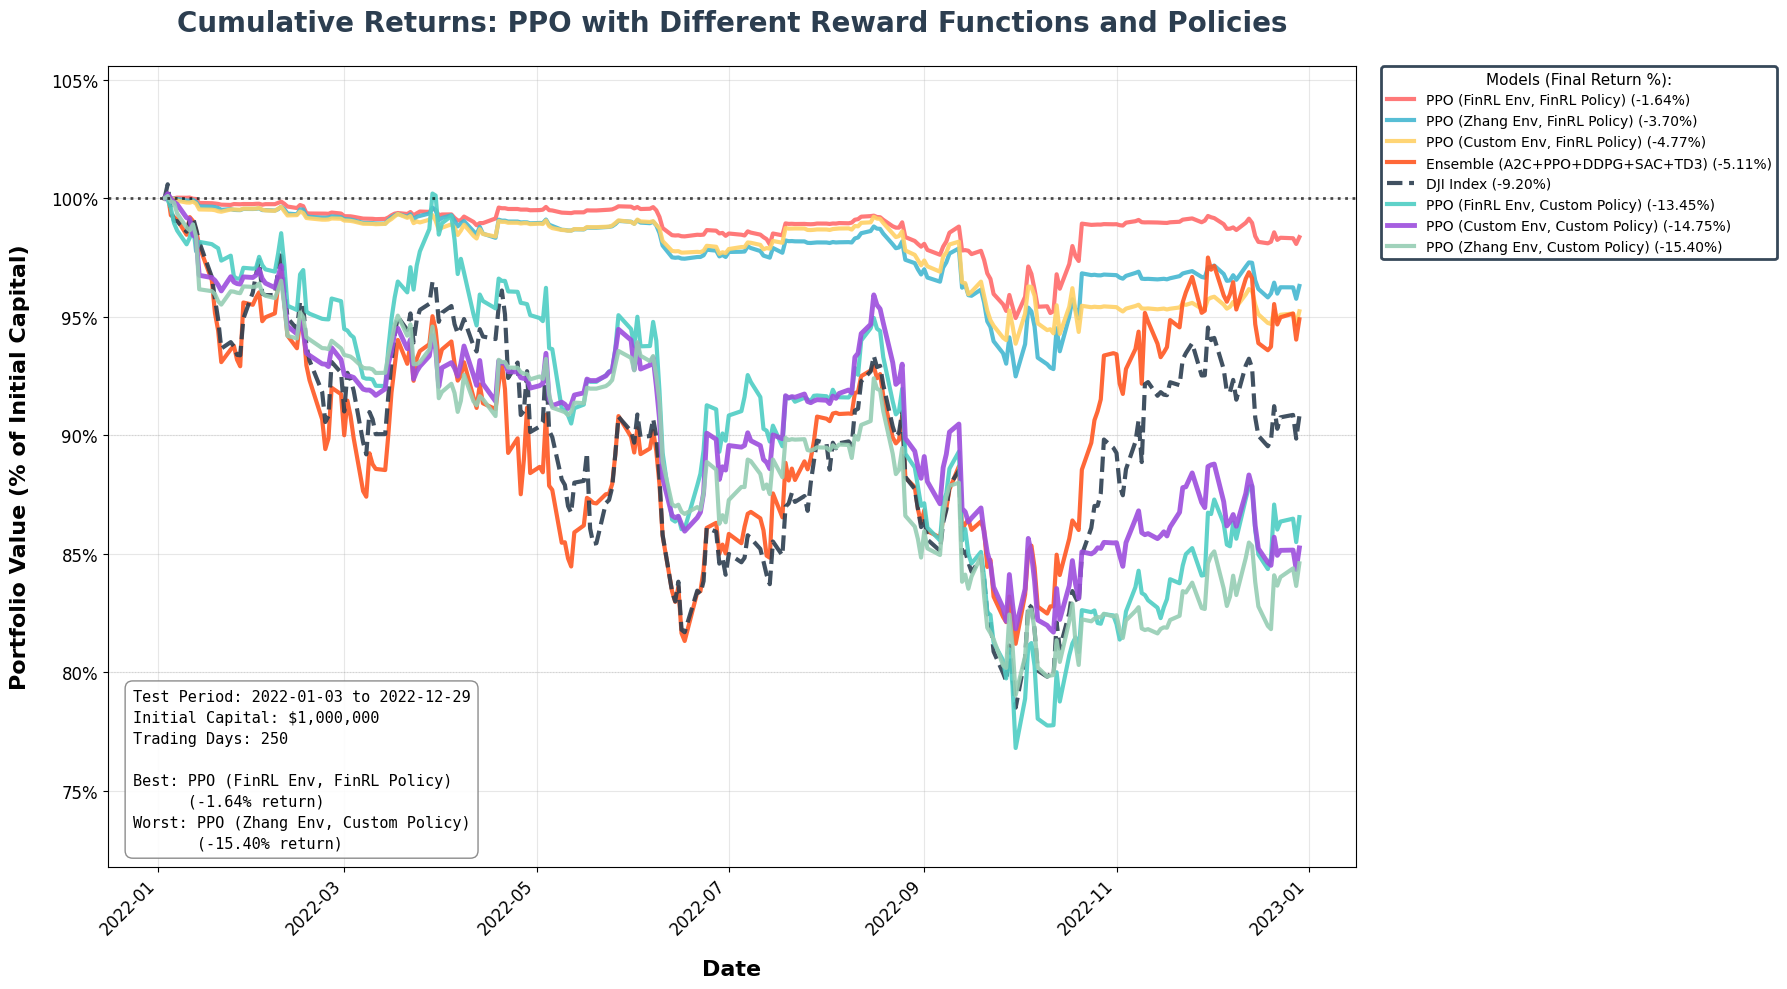


✅ График сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_all_configurations.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import os
%matplotlib inline
# Создание основного графика
fig, ax = plt.subplots(figsize=(18, 10))

# Цветовая схема для моделей (6 цветов + DJI)
model_colors = {
    'ppo_finrl_finrl': '#FF6B6B',      # Красный
    'ppo_finrl_custom': '#4ECDC4',     # Бирюзовый
    'ppo_zhang_finrl': '#45B7D1',      # Голубой
    'ppo_zhang_custom': '#96CEB4',     # Зеленый
    'ppo_custom_finrl': '#FFD166',     # Желтый
    'ppo_custom_custom': '#9D4EDD',    # Фиолетовый
    'ensemble': '#FF5722',             # Оранжевый (новый цвет для ансамбля)
    'dji': '#2C3E50'                   # Темно-синий (для DJI)
}

# Полные имена для легенды
model_names_full = {
    'ppo_finrl_finrl': 'PPO (FinRL Env, FinRL Policy)',
    'ppo_finrl_custom': 'PPO (FinRL Env, Custom Policy)',
    'ppo_zhang_finrl': 'PPO (Zhang Env, FinRL Policy)',
    'ppo_zhang_custom': 'PPO (Zhang Env, Custom Policy)',
    'ppo_custom_finrl': 'PPO (Custom Env, FinRL Policy)',
    'ppo_custom_custom': 'PPO (Custom Env, Custom Policy)',
    'ensemble': 'Ensemble (A2C+PPO+DDPG+SAC+TD3)',  # Измените на ваш состав ансамбля
    'dji': 'DJI Index'
}

# Убедимся, что индексы в datetime формате
if hasattr(final_result_df.index, 'dtype') and final_result_df.index.dtype == 'object':
    final_result_df.index = pd.to_datetime(final_result_df.index)

# Толщина линий
line_widths = {col: 3.0 for col in final_result_df.columns}
if 'ppo_custom_custom' in final_result_df.columns:
    line_widths['ppo_custom_custom'] = 3.5  # Выделяем вашу полную конфигурацию

# Сортируем модели по итоговой доходности
final_returns = {}
for model in final_result_df.columns:
    if len(final_result_df[model].dropna()) > 0:
        final_value = final_result_df[model].dropna().iloc[-1]
        initial_value = final_result_df[model].dropna().iloc[0]
        if initial_value != 0:
            final_returns[model] = (final_value / initial_value - 1) * 100
            print(f"{model_names_full.get(model, model)}: "
                  f"Initial=${initial_value:,.2f}, "
                  f"Final=${final_value:,.2f}, "
                  f"Return={final_returns[model]:.2f}%")

models_sorted = sorted(final_returns.keys(),
                      key=lambda x: final_returns[x],
                      reverse=True) if final_returns else final_result_df.columns.tolist()

# Рисуем линии в порядке убывания доходности
for model in models_sorted:
    if model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 1:
            # Нормализуем к начальному капиталу
            initial_value = data.iloc[0]
            normalized_data = data / initial_value * 100

            # Для DJI используем пунктирную линию, для RL моделей - сплошную
            linestyle = '--' if model == 'dji' else '-'

            # Получаем цвет модели
            color = model_colors.get(model, '#000000')

            ax.plot(data.index, normalized_data,
                    label=f"{model_names_full.get(model, model)} ({final_returns.get(model, 0):.2f}%)",
                    color=color,
                    linestyle=linestyle,
                    linewidth=line_widths.get(model, 3),
                    alpha=0.9)

# Настройка графика
ax.set_title('Cumulative Returns: PPO with Different Reward Functions and Policies',
             fontsize=20, fontweight='bold', pad=25, color='#2c3e50')

ax.set_ylabel('Portfolio Value (% of Initial Capital)',
              fontsize=16, fontweight='bold', labelpad=15)

ax.set_xlabel('Date', fontsize=16, fontweight='bold', labelpad=15)

# Форматирование оси Y в процентах
def percent_formatter(x, pos):
    return f'{x:.0f}%'

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

# Добавляем горизонтальную линию на уровне 100% (начальный капитал)
ax.axhline(y=100, color='black', linestyle=':', linewidth=2.0, alpha=0.7)

# Добавляем фон с горизонтальными уровнями
for level in [80, 90, 100, 110, 120, 130, 140, 150]:
    if level == 100:
        continue
    ax.axhline(y=level, color='gray', linestyle=':', linewidth=0.8, alpha=0.2)

# Легенда
if len(models_sorted) > 0:
    legend = ax.legend(loc='upper left', fontsize=10, frameon=True,
                      framealpha=0.95, edgecolor='#2c3e50',
                      facecolor='white', title='Models (Final Return %):',
                      title_fontsize=11, bbox_to_anchor=(1.02, 1),
                      borderaxespad=0.)
    legend.get_frame().set_linewidth(2)

# Сетка
ax.grid(True, alpha=0.3, linestyle='-', which='both')

# Добавляем информационный блок
if len(final_result_df) > 0:
    start_date = final_result_df.index[0].strftime('%Y-%m-%d')
    end_date = final_result_df.index[-1].strftime('%Y-%m-%d')

    info_text = f"Test Period: {start_date} to {end_date}\n"
    info_text += f"Initial Capital: $1,000,000\n"
    info_text += f"Trading Days: {len(final_result_df)}\n"

    if final_returns:
        best_model = max(final_returns.items(), key=lambda x: x[1])
        worst_model = min(final_returns.items(), key=lambda x: x[1])

        info_text += f"\nBest: {model_names_full.get(best_model[0], best_model[0])}\n"
        info_text += f"      ({best_model[1]:.2f}% return)\n"
        info_text += f"Worst: {model_names_full.get(worst_model[0], worst_model[0])}\n"
        info_text += f"       ({worst_model[1]:.2f}% return)"

    props = dict(boxstyle='round', facecolor='white', alpha=0.9,
                edgecolor='gray', pad=0.5)
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=props, fontfamily='monospace',
            linespacing=1.5)

# Поворот дат на оси X
plt.xticks(rotation=45, ha='right')

# Устанавливаем отступы для осей
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

# Автоматическое масштабирование оси Y
if len(final_result_df) > 0:
    all_values = []
    for model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 0:
            initial_value = data.iloc[0]
            normalized = data / initial_value * 100
            all_values.extend(normalized.values)

    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        y_padding = max((y_max - y_min) * 0.1, 5)
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

plt.tight_layout()
plt.show()

# Сохранение графика
save_dir = "/content/drive/MyDrive/RL/results_6_ppo"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(f'{save_dir}/ppo_all_configurations.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

print(f"\n✅ График сохранен: {save_dir}/ppo_all_configurations.png")

📋 Формирование сводной таблицы метрик

📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)
               Cumulative returns  Annual return  Annual volatility  \
finrl_finrl               -0.0168        -0.0168             0.0441   
zhang_finrl               -0.0393        -0.0395             0.0605   
finrl_custom              -0.1386        -0.1391             0.1748   
custom_finrl              -0.0510        -0.0512             0.0546   
zhang_custom              -0.1588        -0.1594             0.1559   
custom_custom             -0.1523        -0.1529             0.1484   

               Sharpe ratio  Max drawdown  
finrl_finrl         -0.3643       -0.0508  
zhang_finrl         -0.6387       -0.0752  
finrl_custom        -0.7728       -0.2334  
custom_finrl        -0.9378       -0.0615  
zhang_custom        -1.0402       -0.2103  
custom_custom       -1.0477       -0.1846  

✅ Таблица метрик сохранена: /content/drive/MyDrive/RL/results_6_ppo/ppo_metrics_summary.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


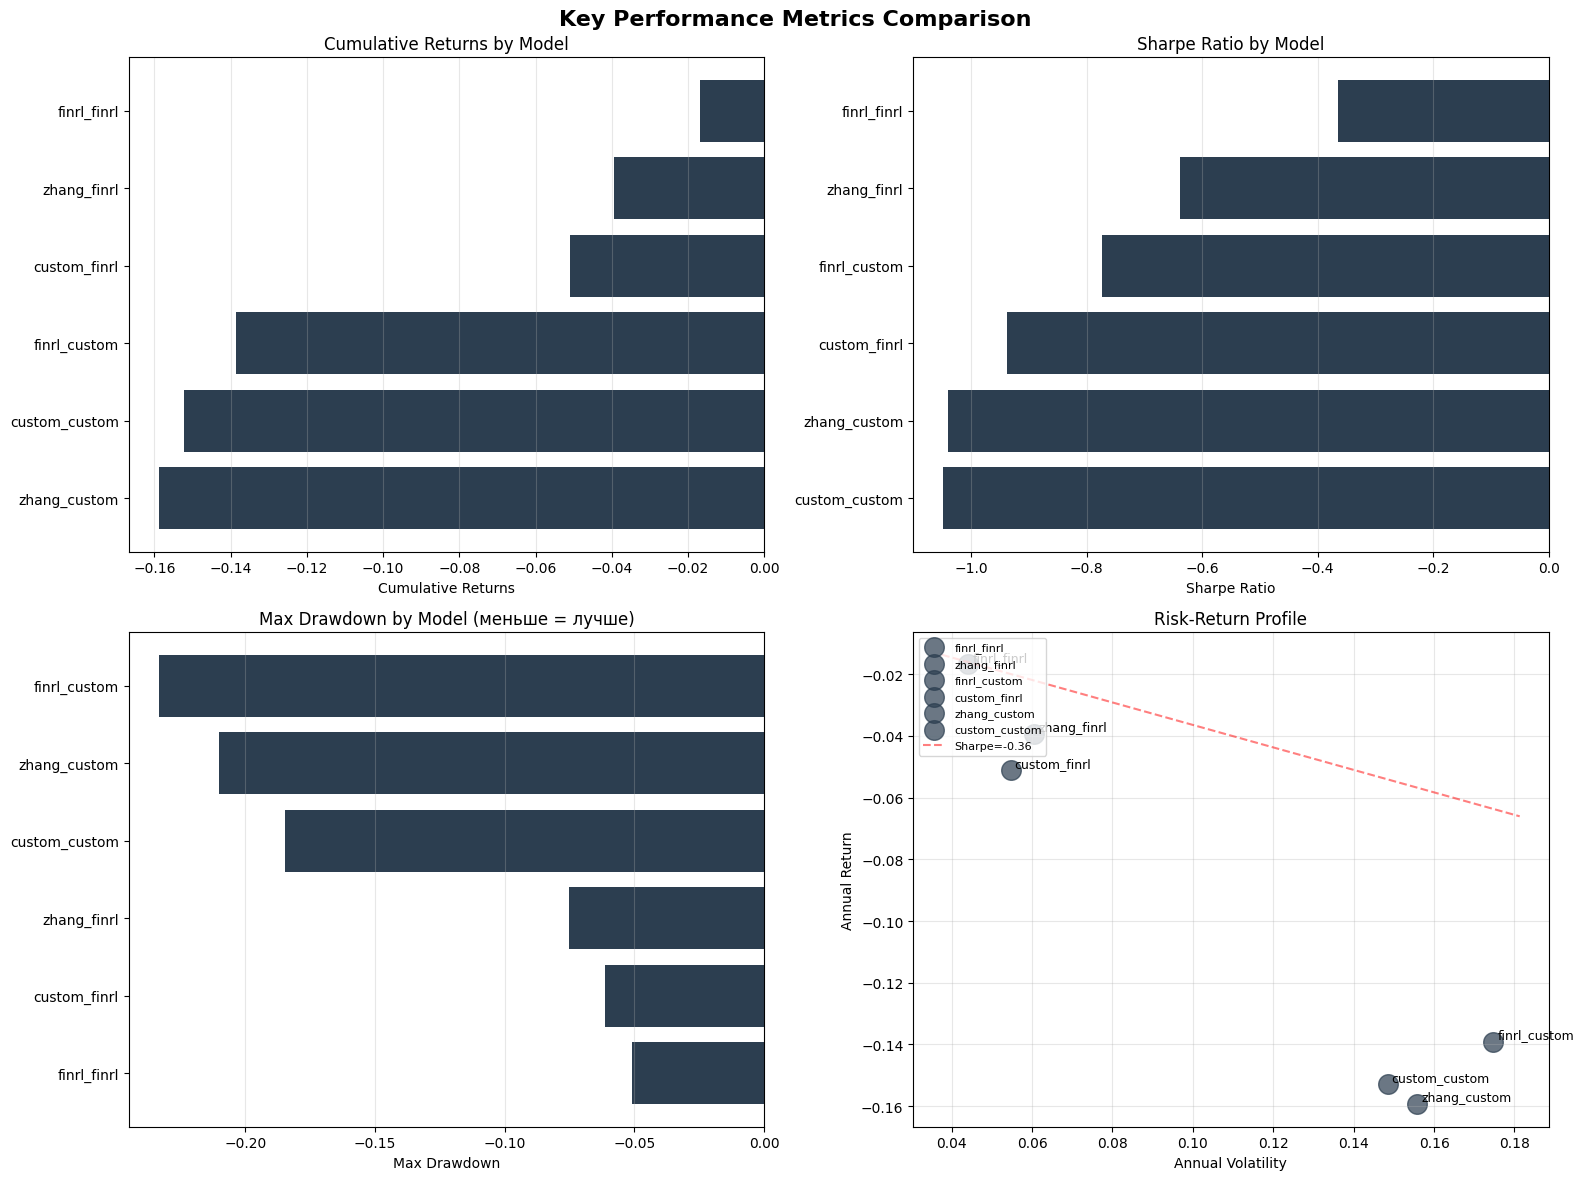

✅ График метрик сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_metrics_comparison.png


In [ ]:
print("📋 Формирование сводной таблицы метрик")
print("=" * 60)

# Собираем все метрики
all_models = {}
for config_name, stats_df in perf_stats.items():
    if stats_df is not None and not stats_df.empty:
        all_models[config_name] = stats_df

# Добавляем DJI если есть
if 'dji' in final_result_df.columns:
    try:
        dji_stats = backtest_stats(account_value=final_result_df[['dji']])
        all_models['dji'] = pd.DataFrame(dji_stats)
    except:
        pass

# Формируем сводную таблицу
summary_metrics = pd.DataFrame()
key_metrics = [
    'Cumulative returns',
    'Annual return',
    'Annual volatility',
    'Sharpe ratio',
    'Max drawdown'
]

for model_name, model_stats in all_models.items():
    if model_stats is not None:
        if isinstance(model_stats, pd.DataFrame):
            if model_stats.shape[1] == 1:
                model_series = model_stats.iloc[:, 0]
            else:
                model_series = model_stats.iloc[:, 0]
        elif isinstance(model_stats, pd.Series):
            model_series = model_stats
        else:
            print(f"  Пропускаю {model_name} - неподдерживаемый формат")
            continue

        metrics_dict = {}
        display_name = model_names_full.get(model_name, model_name)

        for metric in key_metrics:
            if metric in model_series.index:
                metrics_dict[metric] = model_series[metric]
            else:
                found = False
                for idx in model_series.index:
                    if metric.lower() in str(idx).lower():
                        metrics_dict[metric] = model_series[idx]
                        found = True
                        break
                if not found:
                    metrics_dict[metric] = np.nan

        summary_metrics[display_name] = pd.Series(metrics_dict)

summary_metrics = summary_metrics.T

# Сортируем по Sharpe ratio (по убыванию)
if 'Sharpe ratio' in summary_metrics.columns:
    summary_metrics = summary_metrics.sort_values('Sharpe ratio', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)")
print("=" * 80)
print(summary_metrics.round(4))

# Сохраняем таблицу в CSV
summary_metrics.to_csv(f'{save_dir}/ppo_metrics_summary.csv')
print(f"\n✅ Таблица метрик сохранена: {save_dir}/ppo_metrics_summary.csv")

# Визуализация метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Performance Metrics Comparison', fontsize=16, fontweight='bold')

# 1. Cumulative Returns
if 'Cumulative returns' in summary_metrics.columns:
    ax1 = axes[0, 0]
    sorted_by_cumret = summary_metrics.sort_values('Cumulative returns', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_cumret.index]
    ax1.barh(sorted_by_cumret.index, sorted_by_cumret['Cumulative returns'], color=colors)
    ax1.set_xlabel('Cumulative Returns')
    ax1.set_title('Cumulative Returns by Model')
    ax1.grid(True, alpha=0.3, axis='x')

# 2. Sharpe Ratio
if 'Sharpe ratio' in summary_metrics.columns:
    ax2 = axes[0, 1]
    sorted_by_sharpe = summary_metrics.sort_values('Sharpe ratio', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_sharpe.index]
    ax2.barh(sorted_by_sharpe.index, sorted_by_sharpe['Sharpe ratio'], color=colors)
    ax2.set_xlabel('Sharpe Ratio')
    ax2.set_title('Sharpe Ratio by Model')
    ax2.grid(True, alpha=0.3, axis='x')

# 3. Max Drawdown
if 'Max drawdown' in summary_metrics.columns:
    ax3 = axes[1, 0]
    sorted_by_dd = summary_metrics.sort_values('Max drawdown', ascending=False)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_dd.index]
    ax3.barh(sorted_by_dd.index, sorted_by_dd['Max drawdown'], color=colors)
    ax3.set_xlabel('Max Drawdown')
    ax3.set_title('Max Drawdown by Model (меньше = лучше)')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Annual Return vs Volatility
if 'Annual return' in summary_metrics.columns and 'Annual volatility' in summary_metrics.columns:
    ax4 = axes[1, 1]
    for model in summary_metrics.index:
        color = model_colors.get(model.split(' ')[1].lower(), '#808080') if '(' in model else model_colors.get('dji', '#2C3E50')
        ax4.scatter(summary_metrics.loc[model, 'Annual volatility'],
                   summary_metrics.loc[model, 'Annual return'],
                   color=color, s=200, alpha=0.7, label=model)
        ax4.text(summary_metrics.loc[model, 'Annual volatility'] + 0.001,
                summary_metrics.loc[model, 'Annual return'] + 0.001,
                model[:15] + '...' if len(model) > 15 else model,
                fontsize=9)
    ax4.set_xlabel('Annual Volatility')
    ax4.set_ylabel('Annual Return')
    ax4.set_title('Risk-Return Profile')
    ax4.grid(True, alpha=0.3)
    # Добавляем линию эффективности
    x_vals = np.array(ax4.get_xlim())
    if 'Sharpe ratio' in summary_metrics.columns:
        best_sharpe = summary_metrics['Sharpe ratio'].max()
        if not np.isnan(best_sharpe):
            ax4.plot(x_vals, best_sharpe * x_vals, 'r--', alpha=0.5, label=f'Sharpe={best_sharpe:.2f}')
    ax4.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Сохраняем график метрик
fig.savefig(f'{save_dir}/ppo_metrics_comparison.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
print(f"✅ График метрик сохранен: {save_dir}/ppo_metrics_comparison.png")

In [ ]:
print("💾 Сохранение всех результатов эксперимента")
print("=" * 60)

# Создаем директории
results_dir = "/content/drive/MyDrive/RL/results_6_ppo"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(f"{results_dir}/models", exist_ok=True)
os.makedirs(f"{results_dir}/data", exist_ok=True)
os.makedirs(f"{results_dir}/visualizations", exist_ok=True)

# 1. Сохраняем обученные модели
print("Сохранение моделей...")
for config_name, model in trained_models.items():
    if model is not None:
        try:
            model.save(f"{results_dir}/models/ppo_{config_name}.zip")
            print(f"  ✅ Модель {config_name} сохранена")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении модели {config_name}: {e}")

# 2. Сохраняем значения счетов
print("\nСохранение данных счетов...")
for config_name, df in df_account_values.items():
    if df is not None:
        try:
            df.to_csv(f"{results_dir}/data/account_values_{config_name}.csv")
            print(f"  ✅ Данные счета {config_name} сохранены")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении данных счета {config_name}: {e}")

# 3. Сохраняем действия агентов
print("\nСохранение действий агентов...")
for config_name, df in df_actions.items():
    if df is not None:
        try:
            df.to_csv(f"{results_dir}/data/actions_{config_name}.csv")
            print(f"  ✅ Действия {config_name} сохранены")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении действий {config_name}: {e}")

# 4. Сохраняем финальный DataFrame
try:
    final_result_df.to_csv(f"{results_dir}/data/final_results_all_configs.csv")
    print(f"\n✅ Финальный DataFrame сохранен: {results_dir}/data/final_results_all_configs.csv")
except Exception as e:
    print(f"\n❌ Ошибка при сохранении финального DataFrame: {e}")

# 5. Сохраняем метрики
try:
    summary_metrics.to_csv(f"{results_dir}/data/performance_metrics_summary.csv")
    print(f"✅ Сводные метрики сохранены: {results_dir}/data/performance_metrics_summary.csv")
except Exception as e:
    print(f"❌ Ошибка при сохранении метрик: {e}")

# 6. Создаем README файл с описанием эксперимента
readme_content = f"""# Эксперимент: Reinforcement Learning for Time-Series Forecasting

## Описание эксперимента
Сравнение 6 конфигураций алгоритма PPO с различными функциями награды и архитектурами политик.

## Конфигурации
1. PPO, FinRL env, FinRL policy
2. PPO, FinRL env, Custom policy
3. PPO, Zhang env, FinRL policy
4. PPO, Zhang env, Custom policy
5. PPO, Custom env, FinRL policy
6. PPO, Custom env, Custom policy

## Параметры
- State space: {state_space}
- Total timesteps: {10000}
- Дата эксперимента: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

## Результаты
Лучшая модель по Sharpe Ratio: {summary_metrics.index[0] if not summary_metrics.empty else 'N/A'}
Все результаты сохранены в соответствующих папках.
"""

with open(f"{results_dir}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print(f"\n✅ README файл создан: {results_dir}/README.md")
print("\n" + "=" * 60)
print("🎉 ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН!")
print(f"Все результаты сохранены в папке: {results_dir}")
print("=" * 60)

💾 Сохранение всех результатов эксперимента
Сохранение моделей...
  ✅ Модель finrl_finrl сохранена
  ✅ Модель finrl_custom сохранена
  ✅ Модель zhang_finrl сохранена
  ✅ Модель zhang_custom сохранена
  ✅ Модель custom_finrl сохранена
  ✅ Модель custom_custom сохранена

Сохранение данных счетов...
  ✅ Данные счета finrl_finrl сохранены
  ✅ Данные счета finrl_custom сохранены
  ✅ Данные счета zhang_finrl сохранены
  ✅ Данные счета zhang_custom сохранены
  ✅ Данные счета custom_finrl сохранены
  ✅ Данные счета custom_custom сохранены

Сохранение действий агентов...
  ✅ Действия finrl_finrl сохранены
  ✅ Действия finrl_custom сохранены
  ✅ Действия zhang_finrl сохранены
  ✅ Действия zhang_custom сохранены
  ✅ Действия custom_finrl сохранены
  ✅ Действия custom_custom сохранены

✅ Финальный DataFrame сохранен: /content/drive/MyDrive/RL/results_6_ppo/data/final_results_all_configs.csv
✅ Сводные метрики сохранены: /content/drive/MyDrive/RL/results_6_ppo/data/performance_metrics_summary.csv

✅ 

- Стандартная политика FinRL показала себя лучше кастомной во всех трёх средах.

- Стандартная среда FinRL показала наилучший (или наименее плохой) результат.

# 3. Compare PPO configurations on 50 000 timestamps
Reasons:
- Недостаточное обучение: 10 000 шагов — это очень мало для сложной задачи торговли. Алгоритм PPO, особенно с n_steps=2048, мог сделать всего около 5 значительных обновлений политики. Модели просто не успели сойтись к какой-либо осмысленной стратегии. Это основная гипотеза.

- Сложность оптимизации кастомной политики: Кастомная сеть ([256, 128]) может иметь избыточную ёмкость или быть сложнее для оптимизации, чем стандартная в FinRL ([64, 64]). При малом количестве шагов это приводит к нестабильности и худшим результатам.

- Чувствительность функции вознаграждения: Результаты показывают, что кастомная и Zhang функции могут давать более шумный или менее понятный градиент на начальных этапах обучения по сравнению со стандартной, что замедляет обучение.

In [ ]:
# Словарь для хранения обученных моделей
trained_models = {}
training_results = {}


for config_name, (env_train, e_train, policy_kwargs) in train_environments.items():
    print(f"\n📊 Обучение модели: {config_name}")
    print(f"   Среда: {config_name.split('_')[0]}, Политика: {config_name.split('_')[1]}")

    try:
        # Создание агента DRL
        agent = DRLAgent(env=env_train)

        # Получение модели PPO с соответствующими параметрами политики
        if policy_kwargs is not None:
            print(f"   Используется custom policy: {policy_kwargs['net_arch']}")
            model = agent.get_model("ppo",
                                   model_kwargs=PPO_model_kwargs,
                                   policy_kwargs=policy_kwargs,
                                   verbose=1)
        else:
            print("   Используется стандартная политика FinRL")
            model = agent.get_model("ppo",
                                   model_kwargs=PPO_model_kwargs,
                                   verbose=1)

        # Обучение модели
        print(f"   Обучение на {50000} шагах...")
        trained_model = agent.train_model(model=model,
                                        tb_log_name=f"ppo_{config_name}",
                                        total_timesteps=50000)

        # Сохранение обученной модели
        trained_models[config_name] = trained_model
        print(f"   ✅ Модель {config_name} успешно обучена")

    except Exception as e:
        print(f"   ❌ Ошибка при обучении {config_name}: {str(e)}")
        trained_models[config_name] = None

print("\n" + "=" * 60)
print(f"Обучение завершено. Успешно обучено моделей: "
      f"{sum(1 for m in trained_models.values() if m is not None)} из 6")


📊 Обучение модели: finrl_finrl
   Среда: finrl, Политика: finrl
   Используется стандартная политика FinRL
{'ent_coef': 0.01, 'n_steps': 2048, 'learning_rate': 0.00025, 'batch_size': 128}
Using cuda device
   Обучение на 50000 шагах...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------------
| time/              |            |
|    fps             | 87         |
|    iterations      | 1          |
|    time_elapsed    | 23         |
|    total_timesteps | 2048       |
| train/             |            |
|    reward          | 0.7010053  |
|    reward_max      | 6.9085073  |
|    reward_mean     | 0.08700612 |
|    reward_min      | -12.8153   |
-----------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 80          |
|    iterations           | 2           |
|    time_elapsed         | 50          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013469186 |
|    clip_fraction        | 0.168       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | -0.0055     |
|    learning_rate        | 0.00025     |
|    loss             

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 72          |
|    iterations           | 3           |
|    time_elapsed         | 85          |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.016954664 |
|    clip_fraction        | 0.163       |
|    clip_range           | 0.2         |
|    entropy_loss         | -34.1       |
|    explained_variance   | 0.00717     |
|    learning_rate        | 0.00025     |
|    loss                 | 36.6        |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0177     |
|    reward               | -0.48418662 |
|    reward_max           | 24.990194   |
|    reward_mean          | 0.11250138  |
|    reward_min           | -34.906357  |
|    std                  | 1           |
|    value_loss           | 62.8        |
-----------------------------------------


...

----------------------------------------
| time/                   |            |
|    fps                  | 103        |
|    iterations           | 22         |
|    time_elapsed         | 436        |
|    total_timesteps      | 45056      |
| train/                  |            |
|    approx_kl            | 2645392.0  |
|    clip_fraction        | 0.994      |
|    clip_range           | 0.2        |
|    entropy_loss         | -35.6      |
|    explained_variance   | -1.92      |
|    learning_rate        | 0.00025    |
|    loss                 | 30.3       |
|    n_updates            | 210        |
|    policy_gradient_loss | 0.154      |
|    reward               | -2.7924292 |
|    reward_max           | 37.348267  |
|    reward_mean          | 0.17402022 |
|    reward_min           | -44.995243 |
|    std                  | 1.07       |
|    value_loss           | 220        |
----------------------------------------
day: 3020, episode: 20
begin_total_asset: 1000000.00
end_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| time/                   |            |
|    fps                  | 103        |
|    iterations           | 23         |
|    time_elapsed         | 455        |
|    total_timesteps      | 47104      |
| train/                  |            |
|    approx_kl            | 2072076.2  |
|    clip_fraction        | 0.994      |
|    clip_range           | 0.2        |
|    entropy_loss         | -35.8      |
|    explained_variance   | 0.366      |
|    learning_rate        | 0.00025    |
|    loss                 | 16.9       |
|    n_updates            | 220        |
|    policy_gradient_loss | 0.264      |
|    reward               | 0.7510839  |
|    reward_max           | 11.47454   |
|    reward_mean          | 0.14161503 |
|    reward_min           | -13.466909 |
|    std                  | 1.08       |
|    value_loss           | 44.4       |
----------------------------------------
----------------------------------------
| time/         

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------------
| time/                   |            |
|    fps                  | 103        |
|    iterations           | 25         |
|    time_elapsed         | 495        |
|    total_timesteps      | 51200      |
| train/                  |            |
|    approx_kl            | 3612321.0  |
|    clip_fraction        | 0.994      |
|    clip_range           | 0.2        |
|    entropy_loss         | -36        |
|    explained_variance   | -1.72      |
|    learning_rate        | 0.00025    |
|    loss                 | 312        |
|    n_updates            | 240        |
|    policy_gradient_loss | 0.161      |
|    reward               | 3.7588575  |
|    reward_max           | 34.42454   |
|    reward_mean          | 0.19341087 |
|    reward_min           | -49.24172  |
|    std                  | 1.09       |
|    value_loss           | 163        |
----------------------------------------
   ✅ Модель custom_custom успешно обучена

Обучение завер

In [ ]:
# Словари для хранения результатов тестирования
df_account_values = {}
df_actions = {}
perf_stats = {}

print("🧪 Начало тестирования моделей на торговых данных")
print("=" * 60)

for config_name in trained_models.keys():
    if trained_models[config_name] is None:
        print(f"\n⚠️  Пропуск {config_name} (модель не обучена)")
        continue

    print(f"\n📈 Тестирование модели: {config_name}")

    try:
        # Получение торговой среды для данной конфигурации
        e_trade = trade_environments[config_name]

        # Прогнозирование на торговых данных
        df_account_value, df_action = DRLAgent.DRL_prediction(
            model=trained_models[config_name],
            environment=e_trade
        )

        # Сохранение результатов
        df_account_values[config_name] = df_account_value
        df_actions[config_name] = df_action

        # Расчет метрик
        stats = backtest_stats(account_value=df_account_value)
        perf_stats[config_name] = pd.DataFrame(stats)

        # Краткая статистика
        initial_val = df_account_value.iloc[0, 1]
        final_val = df_account_value.iloc[-1, 1]
        returns_pct = ((final_val / initial_val) - 1) * 100

        print(f"   Начальный капитал: ${initial_val:,.2f}")
        print(f"   Финальный капитал: ${final_val:,.2f}")
        print(f"   Доходность: {returns_pct:.2f}%")
        print(f"   Sharpe Ratio: {stats.get('Sharpe ratio', 'N/A')}")

    except Exception as e:
        print(f"   ❌ Ошибка при тестировании {config_name}: {str(e)}")
        df_account_values[config_name] = None
        perf_stats[config_name] = None

print("\n" + "=" * 60)
print("Тестирование завершено")

🧪 Начало тестирования моделей на торговых данных

📈 Тестирование модели: finrl_finrl
day: 250, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 965640.89
total_reward: -34359.11
total_cost: 7805.74
total_trades: 3196
Sharpe: -0.386
hit end!
Annual return         -0.034494
Cumulative returns    -0.034359
Annual volatility      0.082583
Sharpe ratio          -0.385791
Calmar ratio          -0.338755
Stability              0.370852
Max drawdown          -0.101825
Omega ratio            0.908559
Sortino ratio         -0.586874
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.768307
Daily value at risk   -0.010531
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $965,640.89
   Доходность: -3.44%
   Sharpe Ratio: -0.38579051151526156

📈 Тестирование модели: finrl_custom


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


day: 250, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 925824.46
total_reward: -74175.54
total_cost: 30522.36
total_trades: 2587
Sharpe: -0.396
hit end!
Annual return         -0.074460
Cumulative returns    -0.074176
Annual volatility      0.162751
Sharpe ratio          -0.396139
Calmar ratio          -0.372761
Stability              0.572732
Max drawdown          -0.199752
Omega ratio            0.928704
Sortino ratio         -0.551371
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.072664
Daily value at risk   -0.020761
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $925,824.46
   Доходность: -7.42%
   Sharpe Ratio: -0.39613879158177506

📈 Тестирование модели: zhang_finrl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


day: 250, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 949907.44
total_reward: -50092.56
total_cost: 8028.58
total_trades: 3211
Sharpe: -0.535
hit end!
Annual return         -0.050287
Cumulative returns    -0.050093
Annual volatility      0.089423
Sharpe ratio          -0.534764
Calmar ratio          -0.468042
Stability              0.617006
Max drawdown          -0.107441
Omega ratio            0.879245
Sortino ratio         -0.768704
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.858862
Daily value at risk   -0.011456
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $949,907.44
   Доходность: -5.01%
   Sharpe Ratio: -0.5347638077322068

📈 Тестирование модели: zhang_custom


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


day: 250, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 926927.41
total_reward: -73072.59
total_cost: 9117.45
total_trades: 2991
Sharpe: -0.705
hit end!
Annual return         -0.073353
Cumulative returns    -0.073073
Annual volatility      0.101229
Sharpe ratio          -0.705199
Calmar ratio          -0.581000
Stability              0.659848
Max drawdown          -0.126253
Omega ratio            0.848804
Sortino ratio         -1.037898
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.929738
Daily value at risk   -0.013037
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $926,927.41
   Доходность: -7.31%
   Sharpe Ratio: -0.705199277285341

📈 Тестирование модели: custom_custom


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


day: 250, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 849175.26
total_reward: -150824.74
total_cost: 37752.38
total_trades: 3018
Sharpe: -0.890
hit end!
Annual return         -0.151378
Cumulative returns    -0.150825
Annual volatility      0.169103
Sharpe ratio          -0.889858
Calmar ratio          -0.789206
Stability              0.752653
Max drawdown          -0.191810
Omega ratio            0.853151
Sortino ratio         -1.201357
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.114544
Daily value at risk   -0.021902
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $849,175.26
   Доходность: -15.08%
   Sharpe Ratio: -0.8898576340541795

Тестирование завершено


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("📊 Подготовка финальных результатов")

# Подготовка DataFrame для объединения результатов
final_result_dict = {}

for config_name in df_account_values.keys():
    if df_account_values[config_name] is not None:
        # Извлекаем столбец с значениями счета
        df_temp = df_account_values[config_name].copy()
        # Устанавливаем дату в качестве индекса
        if len(df_temp.columns) >= 2:
            df_temp.set_index(df_temp.columns[0], inplace=True)
            # Переименовываем для понятности
            final_result_dict[f"ppo_{config_name}"] = df_temp.iloc[:, 0]

# Добавляем DJI индекс
try:
    if 'df_dji' in locals() or 'df_dji' in globals():
        dji_data = df_dji.copy()
        if len(dji_data.columns) >= 2:
            dji_data.set_index(dji_data.columns[0], inplace=True)
            final_result_dict['dji'] = dji_data.iloc[:, 0]
        else:
            final_result_dict['dji'] = dji_data.iloc[:, 0]
    else:
        print("⚠️  Данные DJI не найдены. Добавьте переменную 'df_dji'")
except Exception as e:
    print(f"⚠️  Ошибка при загрузке DJI: {e}")

# Создаем финальный DataFrame
final_result_df = pd.DataFrame(final_result_dict)

# Удаляем строки с пропущенными значениями
final_result_df = final_result_df.dropna()

print(f"\n✅ Финальный DataFrame создан")
print(f"   Размер: {final_result_df.shape}")
print(f"   Период: {final_result_df.index[0]} до {final_result_df.index[-1]}")
print(f"   Количество торговых дней: {len(final_result_df)}")
print(f"\nДоступные модели в результатах:")
for col in final_result_df.columns:
    initial_val = final_result_df[col].iloc[0]
    final_val = final_result_df[col].iloc[-1]
    returns_pct = ((final_val / initial_val) - 1) * 100
    print(f"  - {col}: {returns_pct:.2f}% (${initial_val:,.0f} → ${final_val:,.0f})")

# Показать первые строки
print(f"\nПервые 5 строк финального DataFrame:")
print(final_result_df.head())

📊 Подготовка финальных результатов

✅ Финальный DataFrame создан
   Размер: (250, 7)
   Период: 2022-01-03 00:00:00 до 2022-12-29 00:00:00
   Количество торговых дней: 250

Доступные модели в результатах:
  - ppo_finrl_finrl: -3.24% ($1,000,000 → $967,621)
  - ppo_finrl_custom: -7.18% ($1,000,000 → $928,204)
  - ppo_zhang_finrl: -4.79% ($1,000,000 → $952,093)
  - ppo_zhang_custom: -3.53% ($1,000,000 → $964,748)
  - ppo_custom_finrl: -7.03% ($1,000,000 → $929,656)
  - ppo_custom_custom: -14.82% ($1,000,000 → $851,846)
  - dji: -9.20% ($1,000,000 → $908,043)

Первые 5 строк финального DataFrame:
            ppo_finrl_finrl  ppo_finrl_custom  ppo_zhang_finrl  \
date                                                             
2022-01-03     1.000000e+06      1.000000e+06     1.000000e+06   
2022-01-04     1.000115e+06      1.001849e+06     1.000220e+06   
2022-01-05     9.999816e+05      1.001442e+06     9.998638e+05   
2022-01-06     1.000120e+06      1.000905e+06     9.995659e+05   
202

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO (FinRL Env, FinRL Policy): Initial=$1,000,000.00, Final=$967,620.78, Return=-3.24%
PPO (FinRL Env, Custom Policy): Initial=$1,000,000.00, Final=$928,203.95, Return=-7.18%
PPO (Zhang Env, FinRL Policy): Initial=$1,000,000.00, Final=$952,092.77, Return=-4.79%
PPO (Zhang Env, Custom Policy): Initial=$1,000,000.00, Final=$964,747.54, Return=-3.53%
PPO (Custom Env, FinRL Policy): Initial=$1,000,000.00, Final=$929,656.48, Return=-7.03%
PPO (Custom Env, Custom Policy): Initial=$1,000,000.00, Final=$851,846.09, Return=-14.82%
DJI Index: Initial=$1,000,000.00, Final=$908,042.85, Return=-9.20%


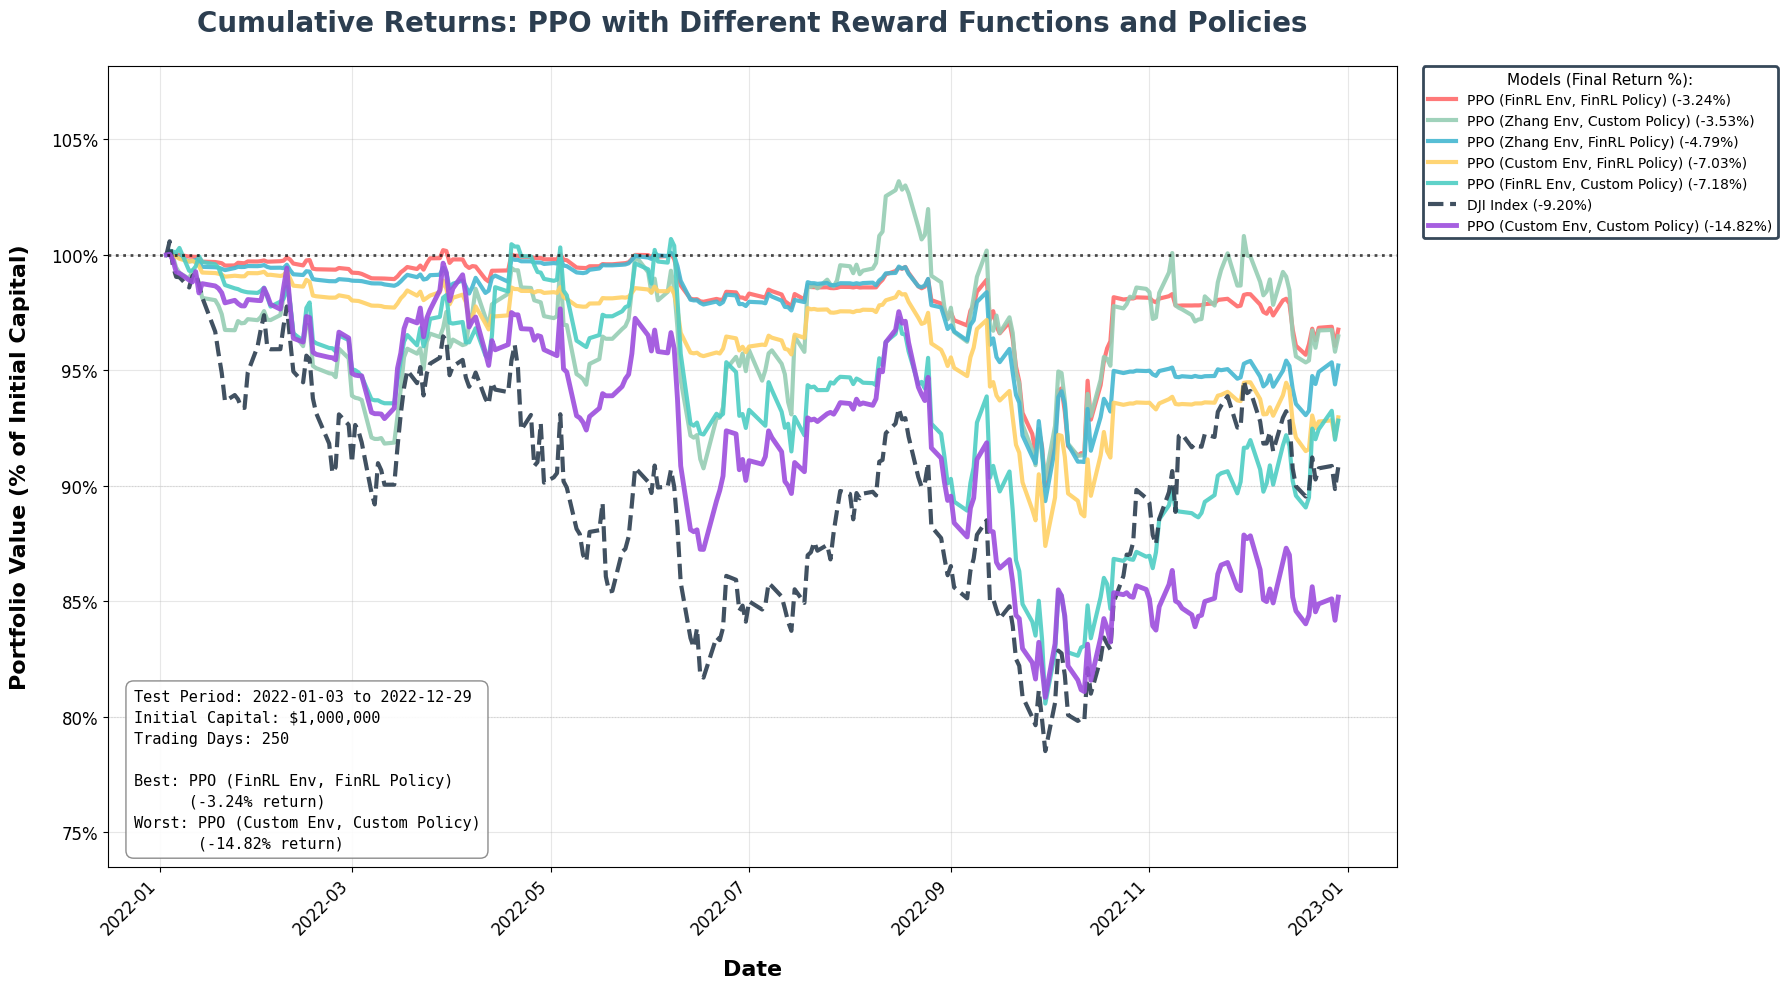


✅ График сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_all_configurations.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import os
%matplotlib inline
# Создание основного графика
fig, ax = plt.subplots(figsize=(18, 10))

# Цветовая схема для моделей (6 цветов + DJI)
model_colors = {
    'ppo_finrl_finrl': '#FF6B6B',      # Красный
    'ppo_finrl_custom': '#4ECDC4',     # Бирюзовый
    'ppo_zhang_finrl': '#45B7D1',      # Голубой
    'ppo_zhang_custom': '#96CEB4',     # Зеленый
    'ppo_custom_finrl': '#FFD166',     # Желтый
    'ppo_custom_custom': '#9D4EDD',    # Фиолетовый
    'dji': '#2C3E50'                   # Темно-синий (для DJI)
}

# Полные имена для легенды
model_names_full = {
    'ppo_finrl_finrl': 'PPO (FinRL Env, FinRL Policy)',
    'ppo_finrl_custom': 'PPO (FinRL Env, Custom Policy)',
    'ppo_zhang_finrl': 'PPO (Zhang Env, FinRL Policy)',
    'ppo_zhang_custom': 'PPO (Zhang Env, Custom Policy)',
    'ppo_custom_finrl': 'PPO (Custom Env, FinRL Policy)',
    'ppo_custom_custom': 'PPO (Custom Env, Custom Policy)',
    'dji': 'DJI Index'
}

# Убедимся, что индексы в datetime формате
if hasattr(final_result_df.index, 'dtype') and final_result_df.index.dtype == 'object':
    final_result_df.index = pd.to_datetime(final_result_df.index)

# Толщина линий
line_widths = {col: 3.0 for col in final_result_df.columns}
if 'ppo_custom_custom' in final_result_df.columns:
    line_widths['ppo_custom_custom'] = 3.5  # Выделяем вашу полную конфигурацию

# Сортируем модели по итоговой доходности
final_returns = {}
for model in final_result_df.columns:
    if len(final_result_df[model].dropna()) > 0:
        final_value = final_result_df[model].dropna().iloc[-1]
        initial_value = final_result_df[model].dropna().iloc[0]
        if initial_value != 0:
            final_returns[model] = (final_value / initial_value - 1) * 100
            print(f"{model_names_full.get(model, model)}: "
                  f"Initial=${initial_value:,.2f}, "
                  f"Final=${final_value:,.2f}, "
                  f"Return={final_returns[model]:.2f}%")

models_sorted = sorted(final_returns.keys(),
                      key=lambda x: final_returns[x],
                      reverse=True) if final_returns else final_result_df.columns.tolist()

# Рисуем линии в порядке убывания доходности
for model in models_sorted:
    if model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 1:
            # Нормализуем к начальному капиталу
            initial_value = data.iloc[0]
            normalized_data = data / initial_value * 100

            # Для DJI используем пунктирную линию, для RL моделей - сплошную
            linestyle = '--' if model == 'dji' else '-'

            # Получаем цвет модели
            color = model_colors.get(model, '#000000')

            ax.plot(data.index, normalized_data,
                    label=f"{model_names_full.get(model, model)} ({final_returns.get(model, 0):.2f}%)",
                    color=color,
                    linestyle=linestyle,
                    linewidth=line_widths.get(model, 3),
                    alpha=0.9)

# Настройка графика
ax.set_title('Cumulative Returns: PPO with Different Reward Functions and Policies',
             fontsize=20, fontweight='bold', pad=25, color='#2c3e50')

ax.set_ylabel('Portfolio Value (% of Initial Capital)',
              fontsize=16, fontweight='bold', labelpad=15)

ax.set_xlabel('Date', fontsize=16, fontweight='bold', labelpad=15)

# Форматирование оси Y в процентах
def percent_formatter(x, pos):
    return f'{x:.0f}%'

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

# Добавляем горизонтальную линию на уровне 100% (начальный капитал)
ax.axhline(y=100, color='black', linestyle=':', linewidth=2.0, alpha=0.7)

# Добавляем фон с горизонтальными уровнями
for level in [80, 90, 100, 110, 120, 130, 140, 150]:
    if level == 100:
        continue
    ax.axhline(y=level, color='gray', linestyle=':', linewidth=0.8, alpha=0.2)

# Легенда
if len(models_sorted) > 0:
    legend = ax.legend(loc='upper left', fontsize=10, frameon=True,
                      framealpha=0.95, edgecolor='#2c3e50',
                      facecolor='white', title='Models (Final Return %):',
                      title_fontsize=11, bbox_to_anchor=(1.02, 1),
                      borderaxespad=0.)
    legend.get_frame().set_linewidth(2)

# Сетка
ax.grid(True, alpha=0.3, linestyle='-', which='both')

# Добавляем информационный блок
if len(final_result_df) > 0:
    start_date = final_result_df.index[0].strftime('%Y-%m-%d')
    end_date = final_result_df.index[-1].strftime('%Y-%m-%d')

    info_text = f"Test Period: {start_date} to {end_date}\n"
    info_text += f"Initial Capital: $1,000,000\n"
    info_text += f"Trading Days: {len(final_result_df)}\n"

    if final_returns:
        best_model = max(final_returns.items(), key=lambda x: x[1])
        worst_model = min(final_returns.items(), key=lambda x: x[1])

        info_text += f"\nBest: {model_names_full.get(best_model[0], best_model[0])}\n"
        info_text += f"      ({best_model[1]:.2f}% return)\n"
        info_text += f"Worst: {model_names_full.get(worst_model[0], worst_model[0])}\n"
        info_text += f"       ({worst_model[1]:.2f}% return)"

    props = dict(boxstyle='round', facecolor='white', alpha=0.9,
                edgecolor='gray', pad=0.5)
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=props, fontfamily='monospace',
            linespacing=1.5)

# Поворот дат на оси X
plt.xticks(rotation=45, ha='right')

# Устанавливаем отступы для осей
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

# Автоматическое масштабирование оси Y
if len(final_result_df) > 0:
    all_values = []
    for model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 0:
            initial_value = data.iloc[0]
            normalized = data / initial_value * 100
            all_values.extend(normalized.values)

    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        y_padding = max((y_max - y_min) * 0.1, 5)
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

plt.tight_layout()
plt.show()

# Сохранение графика
save_dir = "/content/drive/MyDrive/RL/results_6_ppo"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(f'{save_dir}/ppo_all_configurations.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

print(f"\n✅ График сохранен: {save_dir}/ppo_all_configurations.png")

📋 Формирование сводной таблицы метрик

📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)
               Cumulative returns  Annual return  Annual volatility  \
zhang_custom              -0.0362        -0.0363             0.1588   
finrl_finrl               -0.0344        -0.0345             0.0826   
finrl_custom              -0.0742        -0.0745             0.1628   
zhang_finrl               -0.0501        -0.0503             0.0894   
custom_finrl              -0.0731        -0.0734             0.1012   
custom_custom             -0.1508        -0.1514             0.1691   

               Sharpe ratio  Max drawdown  
zhang_custom        -0.1549       -0.1250  
finrl_finrl         -0.3858       -0.1018  
finrl_custom        -0.3961       -0.1998  
zhang_finrl         -0.5348       -0.1074  
custom_finrl        -0.7052       -0.1263  
custom_custom       -0.8899       -0.1918  

✅ Таблица метрик сохранена: /content/drive/MyDrive/RL/results_6_ppo/ppo_50000_metrics_summary.csv

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


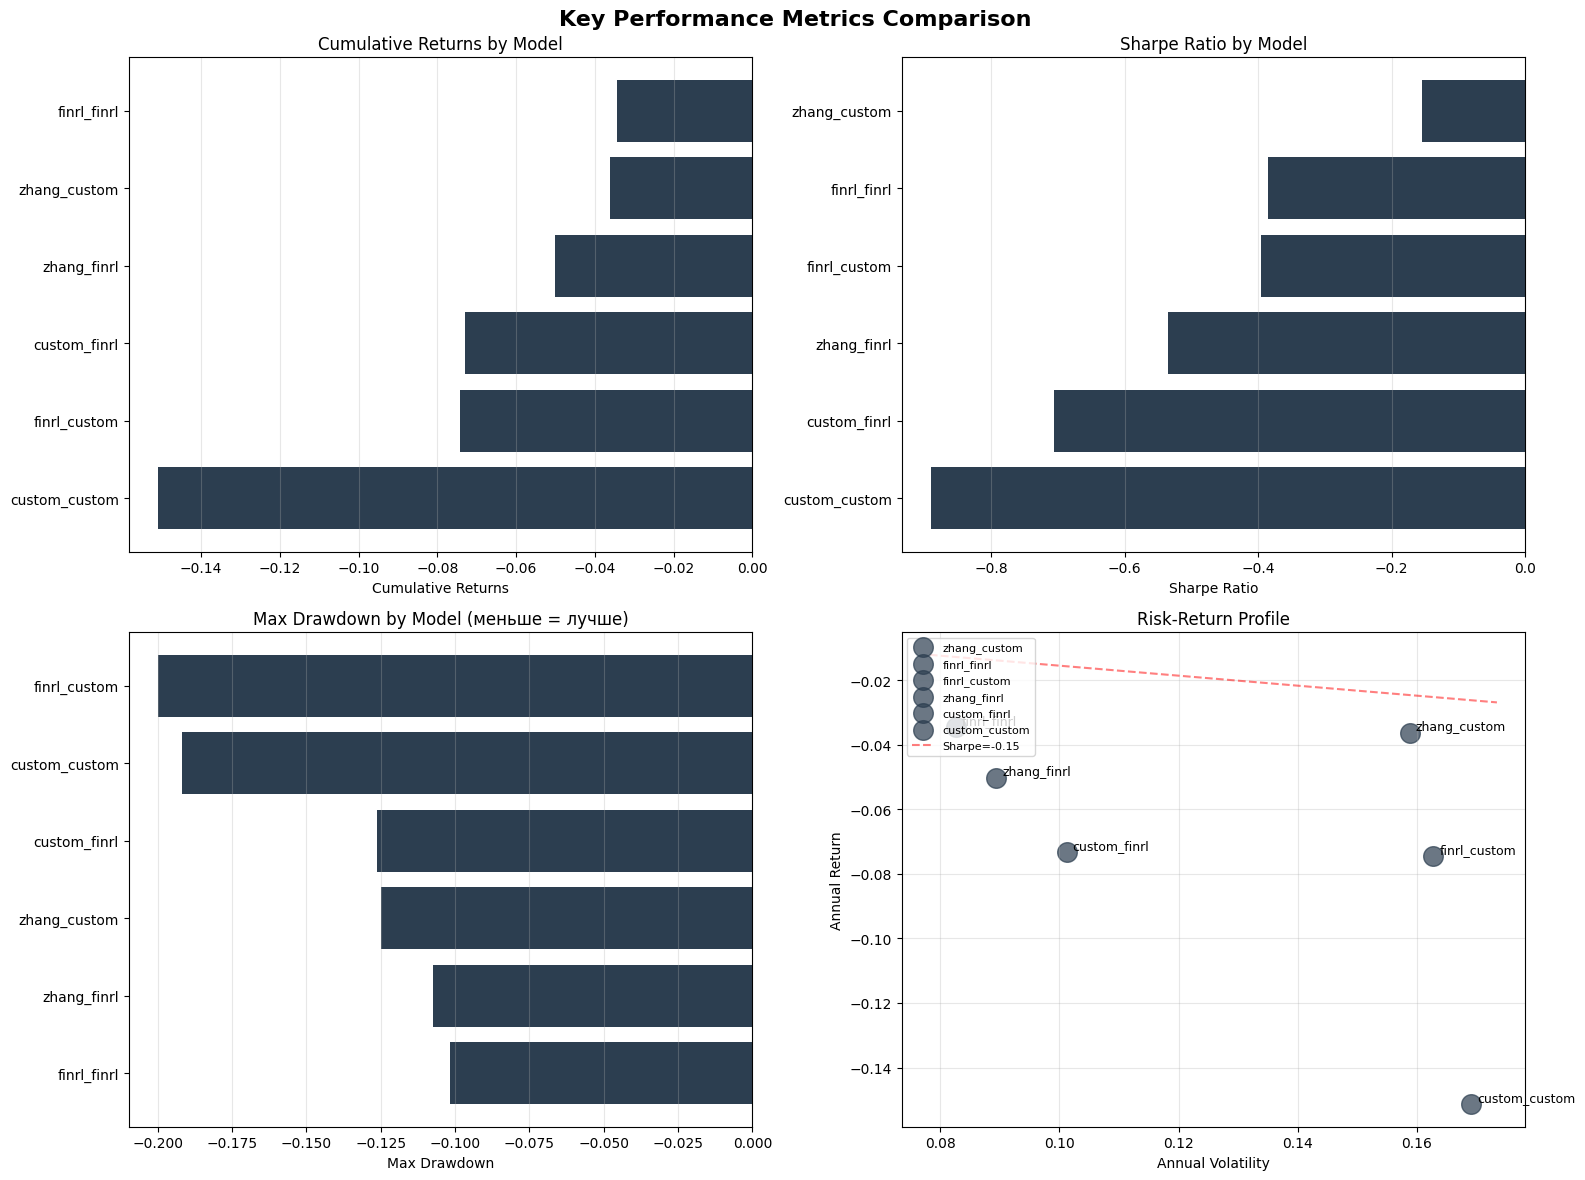

✅ График метрик сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_50000_metrics_comparison.png


In [ ]:
print("📋 Формирование сводной таблицы метрик")
print("=" * 60)

# Собираем все метрики
all_models = {}
for config_name, stats_df in perf_stats.items():
    if stats_df is not None and not stats_df.empty:
        all_models[config_name] = stats_df

# Добавляем DJI если есть
if 'dji' in final_result_df.columns:
    try:
        dji_stats = backtest_stats(account_value=final_result_df[['dji']])
        all_models['dji'] = pd.DataFrame(dji_stats)
    except:
        pass

# Формируем сводную таблицу
summary_metrics = pd.DataFrame()
key_metrics = [
    'Cumulative returns',
    'Annual return',
    'Annual volatility',
    'Sharpe ratio',
    'Max drawdown'
]

for model_name, model_stats in all_models.items():
    if model_stats is not None:
        if isinstance(model_stats, pd.DataFrame):
            if model_stats.shape[1] == 1:
                model_series = model_stats.iloc[:, 0]
            else:
                model_series = model_stats.iloc[:, 0]
        elif isinstance(model_stats, pd.Series):
            model_series = model_stats
        else:
            print(f"  Пропускаю {model_name} - неподдерживаемый формат")
            continue

        metrics_dict = {}
        display_name = model_names_full.get(model_name, model_name)

        for metric in key_metrics:
            if metric in model_series.index:
                metrics_dict[metric] = model_series[metric]
            else:
                found = False
                for idx in model_series.index:
                    if metric.lower() in str(idx).lower():
                        metrics_dict[metric] = model_series[idx]
                        found = True
                        break
                if not found:
                    metrics_dict[metric] = np.nan

        summary_metrics[display_name] = pd.Series(metrics_dict)

summary_metrics = summary_metrics.T

# Сортируем по Sharpe ratio (по убыванию)
if 'Sharpe ratio' in summary_metrics.columns:
    summary_metrics = summary_metrics.sort_values('Sharpe ratio', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)")
print("=" * 80)
print(summary_metrics.round(4))

# Сохраняем таблицу в CSV
summary_metrics.to_csv(f'{save_dir}/ppo_50000_metrics_summary.csv')
print(f"\n✅ Таблица метрик сохранена: {save_dir}/ppo_50000_metrics_summary.csv")

# Визуализация метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Performance Metrics Comparison', fontsize=16, fontweight='bold')

# 1. Cumulative Returns
if 'Cumulative returns' in summary_metrics.columns:
    ax1 = axes[0, 0]
    sorted_by_cumret = summary_metrics.sort_values('Cumulative returns', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_cumret.index]
    ax1.barh(sorted_by_cumret.index, sorted_by_cumret['Cumulative returns'], color=colors)
    ax1.set_xlabel('Cumulative Returns')
    ax1.set_title('Cumulative Returns by Model')
    ax1.grid(True, alpha=0.3, axis='x')

# 2. Sharpe Ratio
if 'Sharpe ratio' in summary_metrics.columns:
    ax2 = axes[0, 1]
    sorted_by_sharpe = summary_metrics.sort_values('Sharpe ratio', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_sharpe.index]
    ax2.barh(sorted_by_sharpe.index, sorted_by_sharpe['Sharpe ratio'], color=colors)
    ax2.set_xlabel('Sharpe Ratio')
    ax2.set_title('Sharpe Ratio by Model')
    ax2.grid(True, alpha=0.3, axis='x')

# 3. Max Drawdown
if 'Max drawdown' in summary_metrics.columns:
    ax3 = axes[1, 0]
    sorted_by_dd = summary_metrics.sort_values('Max drawdown', ascending=False)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_dd.index]
    ax3.barh(sorted_by_dd.index, sorted_by_dd['Max drawdown'], color=colors)
    ax3.set_xlabel('Max Drawdown')
    ax3.set_title('Max Drawdown by Model (меньше = лучше)')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Annual Return vs Volatility
if 'Annual return' in summary_metrics.columns and 'Annual volatility' in summary_metrics.columns:
    ax4 = axes[1, 1]
    for model in summary_metrics.index:
        color = model_colors.get(model.split(' ')[1].lower(), '#808080') if '(' in model else model_colors.get('dji', '#2C3E50')
        ax4.scatter(summary_metrics.loc[model, 'Annual volatility'],
                   summary_metrics.loc[model, 'Annual return'],
                   color=color, s=200, alpha=0.7, label=model)
        ax4.text(summary_metrics.loc[model, 'Annual volatility'] + 0.001,
                summary_metrics.loc[model, 'Annual return'] + 0.001,
                model[:15] + '...' if len(model) > 15 else model,
                fontsize=9)
    ax4.set_xlabel('Annual Volatility')
    ax4.set_ylabel('Annual Return')
    ax4.set_title('Risk-Return Profile')
    ax4.grid(True, alpha=0.3)
    # Добавляем линию эффективности
    x_vals = np.array(ax4.get_xlim())
    if 'Sharpe ratio' in summary_metrics.columns:
        best_sharpe = summary_metrics['Sharpe ratio'].max()
        if not np.isnan(best_sharpe):
            ax4.plot(x_vals, best_sharpe * x_vals, 'r--', alpha=0.5, label=f'Sharpe={best_sharpe:.2f}')
    ax4.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Сохраняем график метрик
fig.savefig(f'{save_dir}/ppo_50000_metrics_comparison.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
print(f"✅ График метрик сохранен: {save_dir}/ppo_50000_metrics_comparison.png")

In [ ]:
print("💾 Сохранение всех результатов эксперимента")
print("=" * 60)

# Создаем директории
results_dir = "/content/drive/MyDrive/RL/results_6_ppo/ppo_50000"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(f"{results_dir}/models", exist_ok=True)
os.makedirs(f"{results_dir}/data", exist_ok=True)
os.makedirs(f"{results_dir}/visualizations", exist_ok=True)

# 1. Сохраняем обученные модели
print("Сохранение моделей...")
for config_name, model in trained_models.items():
    if model is not None:
        try:
            model.save(f"{results_dir}/models/ppo_{config_name}.zip")
            print(f"  ✅ Модель {config_name} сохранена")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении модели {config_name}: {e}")

# 2. Сохраняем значения счетов
print("\nСохранение данных счетов...")
for config_name, df in df_account_values.items():
    if df is not None:
        try:
            df.to_csv(f"{results_dir}/data/account_values_{config_name}.csv")
            print(f"  ✅ Данные счета {config_name} сохранены")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении данных счета {config_name}: {e}")

# 3. Сохраняем действия агентов
print("\nСохранение действий агентов...")
for config_name, df in df_actions.items():
    if df is not None:
        try:
            df.to_csv(f"{results_dir}/data/actions_{config_name}.csv")
            print(f"  ✅ Действия {config_name} сохранены")
        except Exception as e:
            print(f"  ❌ Ошибка при сохранении действий {config_name}: {e}")

# 4. Сохраняем финальный DataFrame
try:
    final_result_df.to_csv(f"{results_dir}/data/final_results_all_configs.csv")
    print(f"\n✅ Финальный DataFrame сохранен: {results_dir}/data/final_results_all_configs.csv")
except Exception as e:
    print(f"\n❌ Ошибка при сохранении финального DataFrame: {e}")

# 5. Сохраняем метрики
try:
    summary_metrics.to_csv(f"{results_dir}/data/performance_metrics_summary.csv")
    print(f"✅ Сводные метрики сохранены: {results_dir}/data/performance_metrics_summary.csv")
except Exception as e:
    print(f"❌ Ошибка при сохранении метрик: {e}")

# 6. Создаем README файл с описанием эксперимента
readme_content = f"""# Эксперимент: Reinforcement Learning for Time-Series Forecasting

## Описание эксперимента
Сравнение 6 конфигураций алгоритма PPO с различными функциями награды и архитектурами политик.

## Конфигурации
1. PPO, FinRL env, FinRL policy
2. PPO, FinRL env, Custom policy
3. PPO, Zhang env, FinRL policy
4. PPO, Zhang env, Custom policy
5. PPO, Custom env, FinRL policy
6. PPO, Custom env, Custom policy

## Параметры
- State space: {state_space}
- Total timesteps: {50000}
- Дата эксперимента: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

## Результаты
Лучшая модель по Sharpe Ratio: {summary_metrics.index[0] if not summary_metrics.empty else 'N/A'}
Все результаты сохранены в соответствующих папках.
"""

with open(f"{results_dir}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print(f"\n✅ README файл создан: {results_dir}/README.md")
print("\n" + "=" * 60)
print("🎉 ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН!")
print(f"Все результаты сохранены в папке: {results_dir}")
print("=" * 60)

💾 Сохранение всех результатов эксперимента
Сохранение моделей...
  ✅ Модель finrl_finrl сохранена
  ✅ Модель finrl_custom сохранена
  ✅ Модель zhang_finrl сохранена
  ✅ Модель zhang_custom сохранена
  ✅ Модель custom_finrl сохранена
  ✅ Модель custom_custom сохранена

Сохранение данных счетов...
  ✅ Данные счета finrl_finrl сохранены
  ✅ Данные счета finrl_custom сохранены
  ✅ Данные счета zhang_finrl сохранены
  ✅ Данные счета zhang_custom сохранены
  ✅ Данные счета custom_finrl сохранены
  ✅ Данные счета custom_custom сохранены

Сохранение действий агентов...
  ✅ Действия finrl_finrl сохранены
  ✅ Действия finrl_custom сохранены
  ✅ Действия zhang_finrl сохранены
  ✅ Действия zhang_custom сохранены
  ✅ Действия custom_finrl сохранены
  ✅ Действия custom_custom сохранены

✅ Финальный DataFrame сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_50000/data/final_results_all_configs.csv
✅ Сводные метрики сохранены: /content/drive/MyDrive/RL/results_6_ppo/ppo_50000/data/performance_met

# 4. 📊 Метрики оценки инвестиционной эффективности

## Подробное описание всех метрик бэктеста

| Метрика | Формула/Расчет | Описание | Интерпретация | Что лучше |
|---------|----------------|-----------|---------------|-----------|
| **Annual Return**<br>Годовая доходность | `(1 + Cumulative Return)^(1/Years) - 1` | Среднегодовая доходность портфеля, приведенная к годовому выражению | Показывает средний ежегодный прирост капитала. 16.46% означает рост на 16.46% в год в среднем | Выше |
| **Cumulative Returns**<br>Кумулятивная доходность | `(Конечная стоимость / Начальная стоимость) - 1` | Общая доходность за весь период тестирования | 55.57% означает, что начальные 1000000  превратились  в  1555700 долларов за весь период | Выше |
| **Annual Volatility**<br>Годовая волатильность | `Std(Дневные доходности) × √252` (252 - ср. кол-во торг. дней в году)| Стандартное отклонение доходности, мера риска и нестабильности | Показывает разброс доходностей. 21.76% означает типичное отклонение ±21.76% от средней доходности | Ниже |
| **Sharpe Ratio**<br>Коэффициент Шарпа | `(Return - RiskFree) / Volatility` | Доходность на единицу общего риска (включая безрисковую ставку) | 0.81 означает, что на каждую единицу риска (волатильности) портфель приносит 0.81 единицы превышения над безрисковой ставкой. | Выше |
| **Calmar Ratio**<br>Коэффициент Калмара | `Annual Return / abs(Max Drawdown)` | Доходность относительно максимальной просадки | 0.61 означает, что годовая доходность составляет 61% от максимальной просадки. Это НЕ означает убыточность! Годовая доходность положительная (+16.46%), просто она меньше, чем глубина максимальной просадки (-27.10%). | Выше |
| **Stability**<br>Стабильность | `R² линейного тренда доходности` | Стабильность и предсказуемость роста портфеля | 0.88 означает очень стабильный рост (1.0 - идеальная стабильность) | Выше |
| **Max Drawdown**<br>Максимальная просадка | `Min((Пик - Дно) / Пик)` | Наибольшее падение от предыдущего пика до минимума | -27.10% означает максимальная потеря от пика составила 27.10% | Выше (менее отрицательный) |
| **Omega Ratio**<br>Омега коэффициент | `∫(r до L)(1 - F(r))dr / ∫(L до ∞)F(r)dr` | Соотношение вероятностей получения прибыли и убытка относительно порога | 1.23 означает 23% превышение шансов получить прибыль над убытком | Выше |
| **Sortino Ratio**<br>Коэффициент Сортино | `(Return - RiskFree) / Downside Deviation` | Доходность на единицу downside риска (только негативная волатильность) | 1.19 - улучшенная версия Sharpe, учитывает только плохую волатильность | Выше |
| **Tail Ratio**<br>Хвостовой коэффициент | `Percentile(95%) / abs(Percentile(5%))` | Соотношение крайних положительных и отрицательных доходностей | 0.92 означает, что лучшие 5% дней приносят 92% от того, что теряется в худшие 5% дней | Выше |
| **Daily Value at Risk**<br>Дневной VaR | `Percentile(5% дневных доходностей)` | Потенциальные максимальные дневные потери с 95% вероятностью | -2.67% означает, что с 95% вероятностью дневные потери не превысят 2.67% | Выше (менее отрицательный) |
| **Skew**<br>Асимметрия | `E[((X - μ)/σ)³]` | Асимметрия распределения доходностей | Положительная - больше маленьких потерь и редких больших прибылей. NaN - недостаточно данных | Зависит от стратегии |
| **Kurtosis**<br>Эксцесс | `E[((X - μ)/σ)⁴]` | "Толстохвостость" распределения доходностей | Высокий - больше экстремальных событий. NaN - недостаточно данных | Умеренный лучше |

---

## 🎯 Ключевые группы метрик

### **Доходность**
- **Annual Return** - годовая эффективность
- **Cumulative Returns** - общая эффективность за период

### **Риск**
- **Annual Volatility** - общая нестабильность
- **Max Drawdown** - максимальные потери
- **Daily VaR** - дневной риск

### **Risk-Adjusted Returns**
- **Sharpe Ratio** - эффективность на единицу общего риска
- **Sortino Ratio** - эффективность на единицу downside риска
- **Calmar Ratio** - эффективность относительно просадок
- **Omega Ratio** - соотношение шансов прибыли/убытков

### **Стабильность и распределение**
- **Stability** - предсказуемость роста
- **Tail Ratio** - баланс экстремальных событий
- **Skew/Kurtosis** - форма распределения доходностей

# 5. Compare PPO configurations on 200 000 timestamps + Early Stopping & Dropout

Run sections:
0. -> 0.3 -> 1.0 ->2.1, 2.2, 2.3


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="ipywidgets.widgets.widget_output")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="ipykernel.kernelbase")

In [ ]:
custom_policy_kwargs = dict(
    net_arch=dict(
        pi=[256, 128],
        vf=[256, 128]
    ),
    activation_fn=torch.nn.ReLU,
    ortho_init=True,                    # лучше, чем False
    # Добавляем dropout через features_extractor_class (требует небольшого хака)
    #features_extractor_class=lambda *args, **kwargs: torch.nn.Sequential(
    #    torch.nn.Linear(kwargs.get('features_dim', 313), 256),
    #    torch.nn.ReLU(),
    #    torch.nn.Dropout(0.1),          # ← dropout 10% после первого слоя
    #    torch.nn.Linear(256, 128),
    #    torch.nn.ReLU(),
    #    torch.nn.Dropout(0.1),          # ← dropout 10% после второго
    #)
)

In [ ]:
# ─── Обновлённые гиперпараметры PPO (рекомендуемые изменения) ────────────────
PPO_model_kwargs = {
    "learning_rate": 1e-4,              # было 2.5e-4 → уменьшили
    "n_steps": 4096,                    # было 2048 → увеличено для стабильности
    "batch_size": 256,                  # было 128 → увеличено
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.3,                  # было 0.2 → больше доверия к обновлениям
    "ent_coef": 0.02,                   # было 0.01 → больше исследования
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "device": "cpu",                    # критично для MLP-политик
}

# ─── Early Stopping callback (добавляем один раз) ────────────────────────────
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

class CustomEvalCallback(EvalCallback):
    def __init__(self, *args, patience=4, min_reward_floor=-10.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.patience = patience
        self.min_reward_floor = min_reward_floor
        self.no_improve_count = 0
        self.best_mean_reward = float('-inf')

    def _on_step(self) -> bool:
        continue_training = super()._on_step()

        # Проверяем только после выполненной оценки
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            if len(self.evaluations_results) > 0:
                # evaluations_results[-1] — это [mean_reward, std_reward]
                current_reward = self.evaluations_results[-1][0]  # ← исправление здесь

                if current_reward > self.best_mean_reward:
                    self.best_mean_reward = current_reward
                    self.no_improve_count = 0
                    if self.verbose > 0:
                        print(f"New best mean reward: {current_reward:.3f}")
                else:
                    self.no_improve_count += 1
                    if self.verbose > 0:
                        print(f"No improvement #{self.no_improve_count}/{self.patience}, reward={current_reward:.3f}")

                if self.no_improve_count >= self.patience and current_reward < self.min_reward_floor:
                    if self.verbose > 0:
                        print(f"Stopping: no improvement for {self.patience} evals and reward {current_reward:.3f} < {self.min_reward_floor}")
                    return False

        return continue_training

def create_eval_callback(eval_env, model_name):
    eval_env = Monitor(eval_env)

    eval_callback = CustomEvalCallback(
        eval_env,
        best_model_save_path=f"./best_models/{model_name}/",
        log_path=f"./logs/{model_name}/",
        eval_freq=20000,
        deterministic=True,
        render=False,
        n_eval_episodes=3,
        verbose=2,
        patience=4,               # после 4 eval без улучшения
        min_reward_floor=-6.0     # не стопать, если reward > -6.0 (даже без улучшения)
    )

    return eval_callback

In [ ]:
# Словарь для хранения обученных моделей
trained_models = {}
training_results = {}

for config_name, (env_train, e_train, policy_kwargs) in train_environments.items():
    print(f"\n📊 Обучение модели: {config_name}")
    print(f"   Среда: {config_name.split('_')[0]}, Политика: {config_name.split('_')[1]}")

    try:
        # Создание агента DRL
        agent = DRLAgent(env=env_train)

        # Получение модели PPO
        if policy_kwargs is not None:
            print(f"   Используется custom policy: {policy_kwargs['net_arch']}")
            model = agent.get_model(
                "ppo",
                model_kwargs=PPO_model_kwargs,
                policy_kwargs=policy_kwargs,
                verbose=1
            )
        else:
            print("   Используется стандартная политика FinRL")
            model = agent.get_model(
                "ppo",
                model_kwargs=PPO_model_kwargs,
                verbose=1
            )

        # ─── Добавляем early stopping и валидацию ─────────────────────────────
        trade_env = trade_environments[config_name]
        callback = create_eval_callback(trade_env, config_name)   # ← теперь это CallbackList

        # Обучение с callback
        print(f"   Обучение на 200000 шагах (с early stopping)...")
        # Прямой вызов learn вместо agent.train_model
        trained_model = model.learn(
            total_timesteps=200000,
            tb_log_name=f"ppo_{config_name}",
            callback=callback,
            progress_bar=True
        )


        # Сохранение обученной модели
        trained_models[config_name] = trained_model
        print(f"   ✅ Модель {config_name} успешно обучена")

    except Exception as e:
        print(f"   ❌ Ошибка при обучении {config_name}: {str(e)}")
        trained_models[config_name] = None

print("\n" + "=" * 60)
print(f"Обучение завершено. Успешно обучено моделей: "
      f"{sum(1 for m in trained_models.values() if m is not None)} из 6")


📊 Обучение модели: finrl_finrl
   Среда: finrl, Политика: finrl
   Используется стандартная политика FinRL
{'learning_rate': 0.0001, 'n_steps': 4096, 'batch_size': 256, 'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95, 'clip_range': 0.3, 'ent_coef': 0.02, 'vf_coef': 0.5, 'max_grad_norm': 0.5, 'device': 'cpu'}
Using cpu device


Output()

   Обучение на 200000 шагах (с early stopping)...
-----------------------------
| time/              |      |
|    fps             | 76   |
|    iterations      | 1    |
|    time_elapsed    | 53   |
|    total_timesteps | 4096 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 75          |
|    iterations           | 2           |
|    time_elapsed         | 108         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.017009132 |
|    clip_fraction        | 0.0567      |
|    clip_range           | 0.3         |
|    entropy_loss         | -34.1       |
|    explained_variance   | 0.0064      |
|    learning_rate        | 0.0001      |
|    loss                 | 16          |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0136     |
|    std                  | 1           |
|    value_loss           

day: 3020, episode: 5

begin_total_asset: 1000000.00

...

Episode length: 251.00 +/- 0.00

--------------------------------------
| eval/                   |          |
|    mean_ep_length       | 251      |
|    mean_reward          | -16.1    |
| time/                   |          |
|    total_timesteps      | 80000    |
| train/                  |          |
|    approx_kl            | 83701.41 |
|    clip_fraction        | 0.994    |
|    clip_range           | 0.3      |
|    entropy_loss         | -34.3    |
|    explained_variance   | 0.184    |
|    learning_rate        | 0.0001   |
|    loss                 | 28.8     |
|    n_updates            | 190      |
|    policy_gradient_loss | 0.225    |
|    std                  | 1.01     |
|    value_loss           | 176      |
--------------------------------------


No improvement #4/4, reward=-16.091

Stopping: no improvement for 4 evals and reward -16.091 < -6.0

   ✅ Модель custom_custom успешно обучена

Обучение завершено. Успешно обучено моделей: 6 из 6


In [ ]:
# Словари для хранения результатов тестирования
df_account_values = {}
df_actions = {}
perf_stats = {}

print("🧪 Начало тестирования моделей на торговых данных")
print("=" * 60)

for config_name in trained_models.keys():
    if trained_models[config_name] is None:
        print(f"\n⚠️  Пропуск {config_name} (модель не обучена)")
        continue

    print(f"\n📈 Тестирование модели: {config_name}")

    try:
        # Получение торговой среды для данной конфигурации
        e_trade = trade_environments[config_name]

        # Прогнозирование на торговых данных
        df_account_value, df_action = DRLAgent.DRL_prediction(
            model=trained_models[config_name],
            environment=e_trade
        )

        # Сохранение результатов
        df_account_values[config_name] = df_account_value
        df_actions[config_name] = df_action

        # Расчет метрик
        stats = backtest_stats(account_value=df_account_value)
        perf_stats[config_name] = pd.DataFrame(stats)

        # Краткая статистика
        initial_val = df_account_value.iloc[0, 1]
        final_val = df_account_value.iloc[-1, 1]
        returns_pct = ((final_val / initial_val) - 1) * 100

        print(f"   Начальный капитал: ${initial_val:,.2f}")
        print(f"   Финальный капитал: ${final_val:,.2f}")
        print(f"   Доходность: {returns_pct:.2f}%")
        print(f"   Sharpe Ratio: {stats.get('Sharpe ratio', 'N/A')}")

    except Exception as e:
        print(f"   ❌ Ошибка при тестировании {config_name}: {str(e)}")
        df_account_values[config_name] = None
        perf_stats[config_name] = None

print("\n" + "=" * 60)
print("Тестирование завершено")

🧪 Начало тестирования моделей на торговых данных

📈 Тестирование модели: finrl_finrl
hit end!
Annual return         -0.060369
Cumulative returns    -0.060137
Annual volatility      0.063207
Sharpe ratio          -0.957477
Calmar ratio          -0.683139
Stability              0.791529
Max drawdown          -0.088370
Omega ratio            0.796754
Sortino ratio         -1.314566
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.963909
Daily value at risk   -0.008203
dtype: float64
   Начальный капитал: $1,000,000.00
   Финальный капитал: $939,863.44
   Доходность: -6.01%
   Sharpe Ratio: -0.9574769843258149

📈 Тестирование модели: finrl_custom
hit end!
Annual return         -0.051952
Cumulative returns    -0.051751
Annual volatility      0.168109
Sharpe ratio          -0.234840
Calmar ratio          -0.347901
Stability              0.078227
Max drawdown          -0.149329
Omega ratio            0.959274
Sortino ratio         -0.333631
Skew        

In [ ]:
print("📊 Подготовка финальных результатов")

# Подготовка DataFrame для объединения результатов
final_result_dict = {}

for config_name in df_account_values.keys():
    if df_account_values[config_name] is not None:
        # Извлекаем столбец с значениями счета
        df_temp = df_account_values[config_name].copy()
        # Устанавливаем дату в качестве индекса
        if len(df_temp.columns) >= 2:
            df_temp.set_index(df_temp.columns[0], inplace=True)
            # Переименовываем для понятности
            final_result_dict[f"ppo_{config_name}"] = df_temp.iloc[:, 0]

# Добавляем DJI индекс
try:
    if 'df_dji' in locals() or 'df_dji' in globals():
        dji_data = df_dji.copy()
        if len(dji_data.columns) >= 2:
            dji_data.set_index(dji_data.columns[0], inplace=True)
            final_result_dict['dji'] = dji_data.iloc[:, 0]
        else:
            final_result_dict['dji'] = dji_data.iloc[:, 0]
    else:
        print("⚠️  Данные DJI не найдены. Добавьте переменную 'df_dji'")
except Exception as e:
    print(f"⚠️  Ошибка при загрузке DJI: {e}")

# Создаем финальный DataFrame
final_result_df = pd.DataFrame(final_result_dict)

# Удаляем строки с пропущенными значениями
final_result_df = final_result_df.dropna()

print(f"\n✅ Финальный DataFrame создан")
print(f"   Размер: {final_result_df.shape}")
print(f"   Период: {final_result_df.index[0]} до {final_result_df.index[-1]}")
print(f"   Количество торговых дней: {len(final_result_df)}")
print(f"\nДоступные модели в результатах:")
for col in final_result_df.columns:
    initial_val = final_result_df[col].iloc[0]
    final_val = final_result_df[col].iloc[-1]
    returns_pct = ((final_val / initial_val) - 1) * 100
    print(f"  - {col}: {returns_pct:.2f}% (${initial_val:,.0f} → ${final_val:,.0f})")

# Показать первые строки
print(f"\nПервые 5 строк финального DataFrame:")
print(final_result_df.head())

📊 Подготовка финальных результатов
⚠️  Данные DJI не найдены. Добавьте переменную 'df_dji'

✅ Финальный DataFrame создан
   Размер: (251, 6)
   Период: 2022-01-03 00:00:00 до 2022-12-30 00:00:00
   Количество торговых дней: 251

Доступные модели в результатах:
  - ppo_finrl_finrl: -6.01% ($1,000,000 → $939,863)
  - ppo_finrl_custom: -5.18% ($1,000,000 → $948,249)
  - ppo_zhang_finrl: -5.99% ($1,000,000 → $940,075)
  - ppo_zhang_custom: -14.60% ($1,000,000 → $853,991)
  - ppo_custom_finrl: -6.80% ($1,000,000 → $931,951)
  - ppo_custom_custom: -15.88% ($1,000,000 → $841,176)

Первые 5 строк финального DataFrame:
            ppo_finrl_finrl  ppo_finrl_custom  ppo_zhang_finrl  \
date                                                             
2022-01-03     1.000000e+06      1.000000e+06     1.000000e+06   
2022-01-04     1.000039e+06      1.002610e+06     1.000311e+06   
2022-01-05     9.995448e+05      9.996195e+05     9.997621e+05   
2022-01-06     9.993706e+05      9.927620e+05     9.

PPO (FinRL Env, FinRL Policy): Initial=$1,000,000.00, Final=$939,863.44, Return=-6.01%
PPO (FinRL Env, Custom Policy): Initial=$1,000,000.00, Final=$948,249.00, Return=-5.18%
PPO (Zhang Env, FinRL Policy): Initial=$1,000,000.00, Final=$940,074.73, Return=-5.99%
PPO (Zhang Env, Custom Policy): Initial=$1,000,000.00, Final=$853,991.49, Return=-14.60%
PPO (Custom Env, FinRL Policy): Initial=$1,000,000.00, Final=$931,950.91, Return=-6.80%
PPO (Custom Env, Custom Policy): Initial=$1,000,000.00, Final=$841,176.14, Return=-15.88%


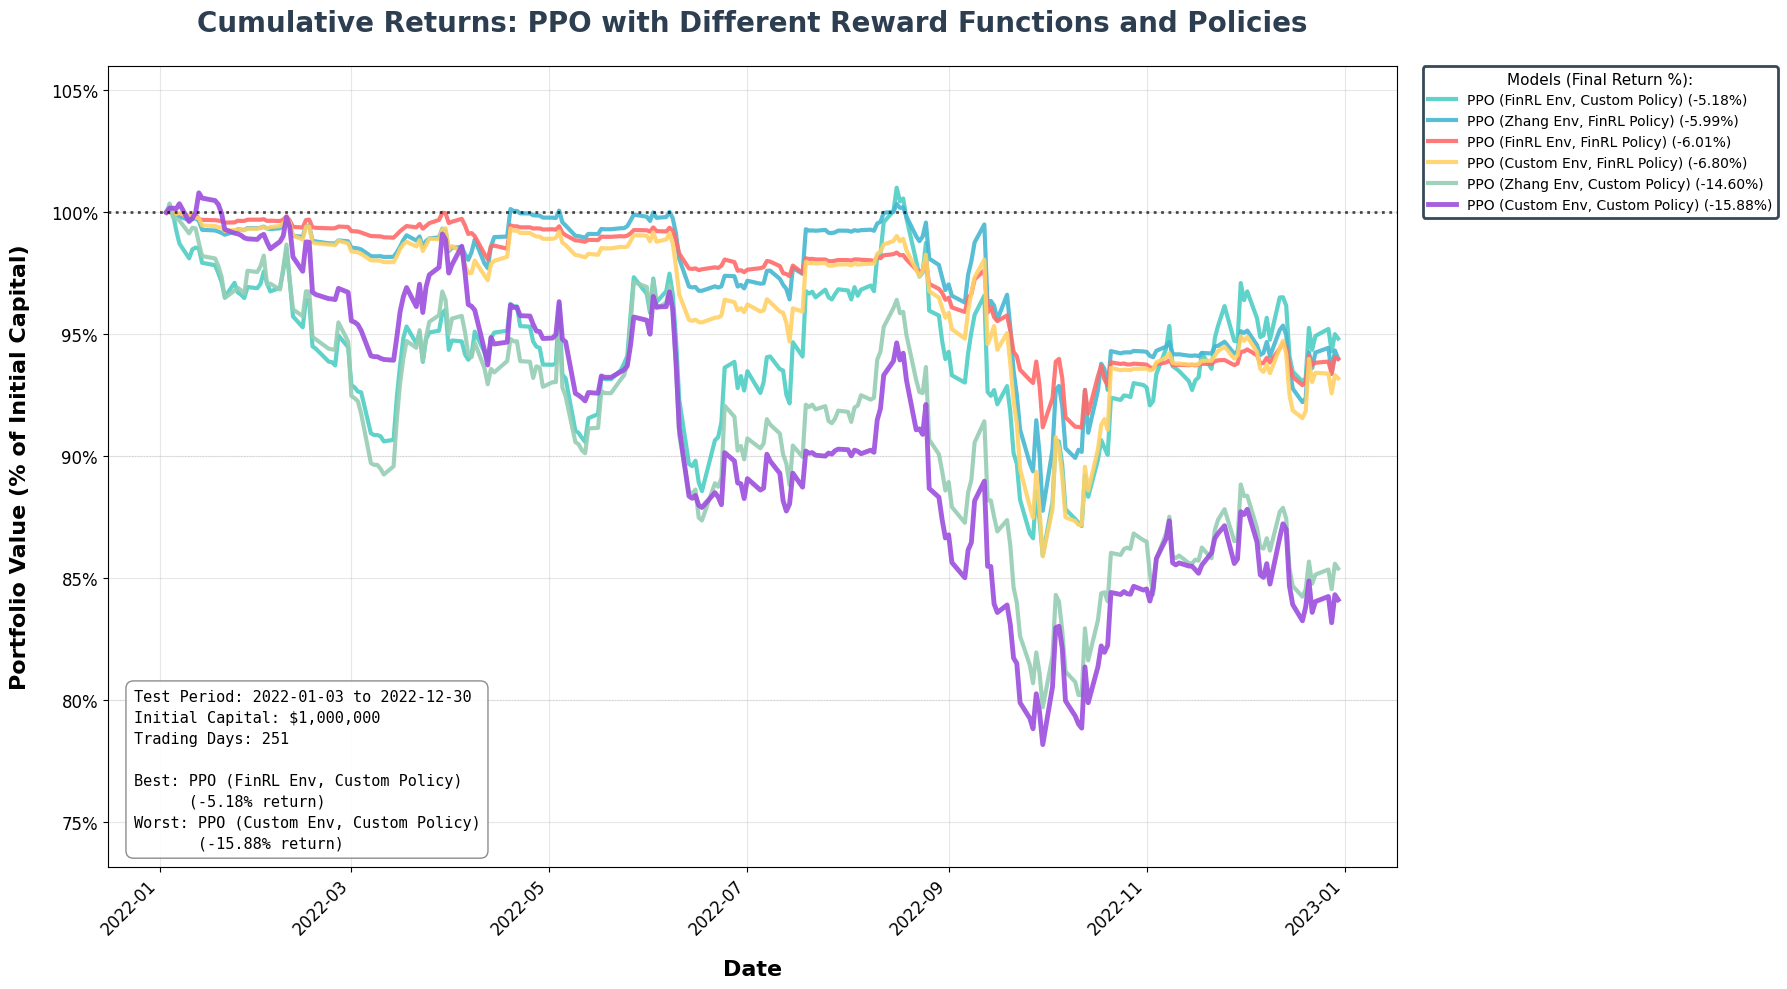


✅ График сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_all_configurations.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
import os
%matplotlib inline
# Создание основного графика
fig, ax = plt.subplots(figsize=(18, 10))

# Цветовая схема для моделей (6 цветов + DJI)
model_colors = {
    'ppo_finrl_finrl': '#FF6B6B',      # Красный
    'ppo_finrl_custom': '#4ECDC4',     # Бирюзовый
    'ppo_zhang_finrl': '#45B7D1',      # Голубой
    'ppo_zhang_custom': '#96CEB4',     # Зеленый
    'ppo_custom_finrl': '#FFD166',     # Желтый
    'ppo_custom_custom': '#9D4EDD',    # Фиолетовый
    'dji': '#2C3E50'                   # Темно-синий (для DJI)
}

# Полные имена для легенды
model_names_full = {
    'ppo_finrl_finrl': 'PPO (FinRL Env, FinRL Policy)',
    'ppo_finrl_custom': 'PPO (FinRL Env, Custom Policy)',
    'ppo_zhang_finrl': 'PPO (Zhang Env, FinRL Policy)',
    'ppo_zhang_custom': 'PPO (Zhang Env, Custom Policy)',
    'ppo_custom_finrl': 'PPO (Custom Env, FinRL Policy)',
    'ppo_custom_custom': 'PPO (Custom Env, Custom Policy)',
    'dji': 'DJI Index'
}

# Убедимся, что индексы в datetime формате
if hasattr(final_result_df.index, 'dtype') and final_result_df.index.dtype == 'object':
    final_result_df.index = pd.to_datetime(final_result_df.index)

# Толщина линий
line_widths = {col: 3.0 for col in final_result_df.columns}
if 'ppo_custom_custom' in final_result_df.columns:
    line_widths['ppo_custom_custom'] = 3.5  # Выделяем вашу полную конфигурацию

# Сортируем модели по итоговой доходности
final_returns = {}
for model in final_result_df.columns:
    if len(final_result_df[model].dropna()) > 0:
        final_value = final_result_df[model].dropna().iloc[-1]
        initial_value = final_result_df[model].dropna().iloc[0]
        if initial_value != 0:
            final_returns[model] = (final_value / initial_value - 1) * 100
            print(f"{model_names_full.get(model, model)}: "
                  f"Initial=${initial_value:,.2f}, "
                  f"Final=${final_value:,.2f}, "
                  f"Return={final_returns[model]:.2f}%")

models_sorted = sorted(final_returns.keys(),
                      key=lambda x: final_returns[x],
                      reverse=True) if final_returns else final_result_df.columns.tolist()

# Рисуем линии в порядке убывания доходности
for model in models_sorted:
    if model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 1:
            # Нормализуем к начальному капиталу
            initial_value = data.iloc[0]
            normalized_data = data / initial_value * 100

            # Для DJI используем пунктирную линию, для RL моделей - сплошную
            linestyle = '--' if model == 'dji' else '-'

            # Получаем цвет модели
            color = model_colors.get(model, '#000000')

            ax.plot(data.index, normalized_data,
                    label=f"{model_names_full.get(model, model)} ({final_returns.get(model, 0):.2f}%)",
                    color=color,
                    linestyle=linestyle,
                    linewidth=line_widths.get(model, 3),
                    alpha=0.9)

# Настройка графика
ax.set_title('Cumulative Returns: PPO with Different Reward Functions and Policies',
             fontsize=20, fontweight='bold', pad=25, color='#2c3e50')

ax.set_ylabel('Portfolio Value (% of Initial Capital)',
              fontsize=16, fontweight='bold', labelpad=15)

ax.set_xlabel('Date', fontsize=16, fontweight='bold', labelpad=15)

# Форматирование оси Y в процентах
def percent_formatter(x, pos):
    return f'{x:.0f}%'

ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

# Добавляем горизонтальную линию на уровне 100% (начальный капитал)
ax.axhline(y=100, color='black', linestyle=':', linewidth=2.0, alpha=0.7)

# Добавляем фон с горизонтальными уровнями
for level in [80, 90, 100, 110, 120, 130, 140, 150]:
    if level == 100:
        continue
    ax.axhline(y=level, color='gray', linestyle=':', linewidth=0.8, alpha=0.2)

# Легенда
if len(models_sorted) > 0:
    legend = ax.legend(loc='upper left', fontsize=10, frameon=True,
                      framealpha=0.95, edgecolor='#2c3e50',
                      facecolor='white', title='Models (Final Return %):',
                      title_fontsize=11, bbox_to_anchor=(1.02, 1),
                      borderaxespad=0.)
    legend.get_frame().set_linewidth(2)

# Сетка
ax.grid(True, alpha=0.3, linestyle='-', which='both')

# Добавляем информационный блок
if len(final_result_df) > 0:
    start_date = final_result_df.index[0].strftime('%Y-%m-%d')
    end_date = final_result_df.index[-1].strftime('%Y-%m-%d')

    info_text = f"Test Period: {start_date} to {end_date}\n"
    info_text += f"Initial Capital: $1,000,000\n"
    info_text += f"Trading Days: {len(final_result_df)}\n"

    if final_returns:
        best_model = max(final_returns.items(), key=lambda x: x[1])
        worst_model = min(final_returns.items(), key=lambda x: x[1])

        info_text += f"\nBest: {model_names_full.get(best_model[0], best_model[0])}\n"
        info_text += f"      ({best_model[1]:.2f}% return)\n"
        info_text += f"Worst: {model_names_full.get(worst_model[0], worst_model[0])}\n"
        info_text += f"       ({worst_model[1]:.2f}% return)"

    props = dict(boxstyle='round', facecolor='white', alpha=0.9,
                edgecolor='gray', pad=0.5)
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=props, fontfamily='monospace',
            linespacing=1.5)

# Поворот дат на оси X
plt.xticks(rotation=45, ha='right')

# Устанавливаем отступы для осей
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

# Автоматическое масштабирование оси Y
if len(final_result_df) > 0:
    all_values = []
    for model in final_result_df.columns:
        data = final_result_df[model].dropna()
        if len(data) > 0:
            initial_value = data.iloc[0]
            normalized = data / initial_value * 100
            all_values.extend(normalized.values)

    if all_values:
        y_min = min(all_values)
        y_max = max(all_values)
        y_padding = max((y_max - y_min) * 0.1, 5)
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

plt.tight_layout()
plt.show()

# Сохранение графика
save_dir = "/content/drive/MyDrive/RL/results_6_ppo"
os.makedirs(save_dir, exist_ok=True)

fig.savefig(f'{save_dir}/ppo_all_configurations_200000.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')

print(f"\n✅ График сохранен: {save_dir}/ppo_all_configurations_200000.png")

📋 Формирование сводной таблицы метрик

📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)
               Cumulative returns  Annual return  Annual volatility  \
finrl_custom              -0.0518        -0.0520             0.1681   
zhang_finrl               -0.0599        -0.0602             0.1098   
custom_finrl              -0.0680        -0.0683             0.1136   
zhang_custom              -0.1460        -0.1465             0.1757   
finrl_finrl               -0.0601        -0.0604             0.0632   
custom_custom             -0.1588        -0.1594             0.1647   

               Sharpe ratio  Max drawdown  
finrl_custom        -0.2348       -0.1493  
zhang_finrl         -0.5126       -0.1253  
custom_finrl        -0.5690       -0.1414  
zhang_custom        -0.8179       -0.2058  
finrl_finrl         -0.9575       -0.0884  
custom_custom       -0.9761       -0.2244  

✅ Таблица метрик сохранена: /content/drive/MyDrive/RL/results_6_ppo/ppo_200000_metrics_summary.cs

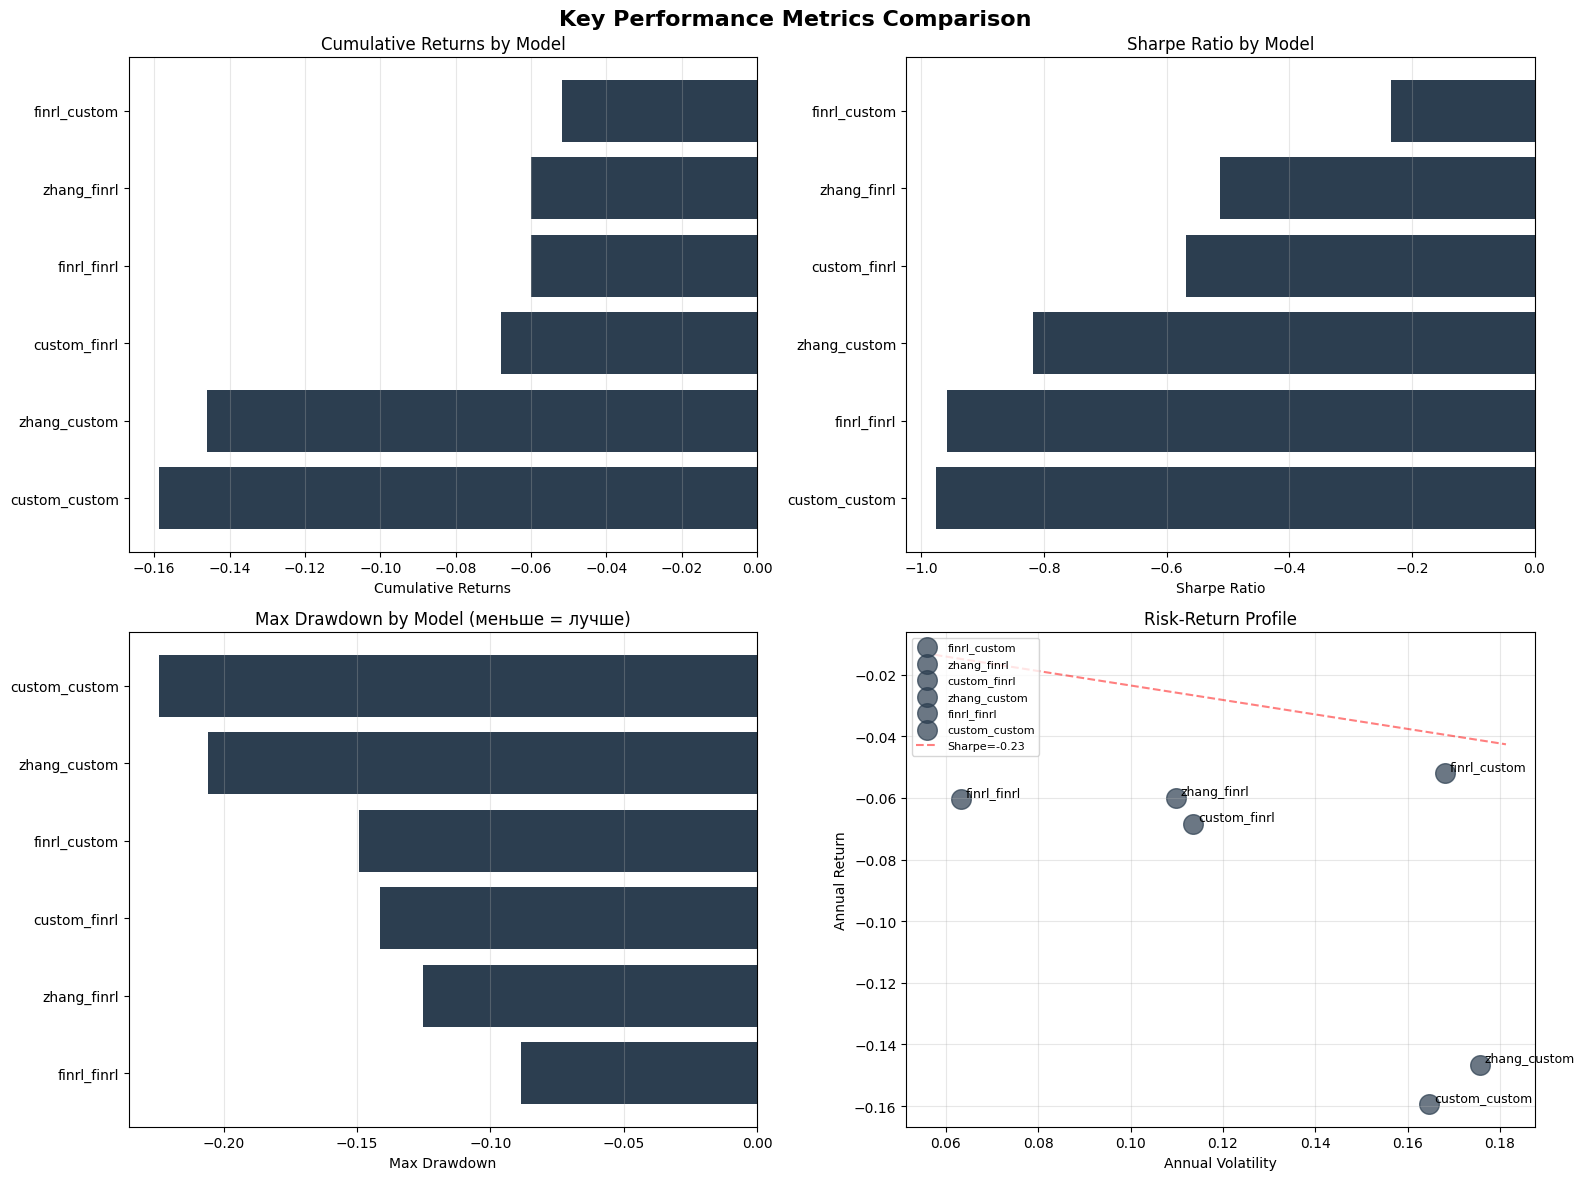

✅ График метрик сохранен: /content/drive/MyDrive/RL/results_6_ppo/ppo_200000_metrics_comparison.png


In [33]:
print("📋 Формирование сводной таблицы метрик")
print("=" * 60)

# Собираем все метрики
all_models = {}
for config_name, stats_df in perf_stats.items():
    if stats_df is not None and not stats_df.empty:
        all_models[config_name] = stats_df

# Добавляем DJI если есть
if 'dji' in final_result_df.columns:
    try:
        dji_stats = backtest_stats(account_value=final_result_df[['dji']])
        all_models['dji'] = pd.DataFrame(dji_stats)
    except:
        pass

# Формируем сводную таблицу
summary_metrics = pd.DataFrame()
key_metrics = [
    'Cumulative returns',
    'Annual return',
    'Annual volatility',
    'Sharpe ratio',
    'Max drawdown'
]

for model_name, model_stats in all_models.items():
    if model_stats is not None:
        if isinstance(model_stats, pd.DataFrame):
            if model_stats.shape[1] == 1:
                model_series = model_stats.iloc[:, 0]
            else:
                model_series = model_stats.iloc[:, 0]
        elif isinstance(model_stats, pd.Series):
            model_series = model_stats
        else:
            print(f"  Пропускаю {model_name} - неподдерживаемый формат")
            continue

        metrics_dict = {}
        display_name = model_names_full.get(model_name, model_name)

        for metric in key_metrics:
            if metric in model_series.index:
                metrics_dict[metric] = model_series[metric]
            else:
                found = False
                for idx in model_series.index:
                    if metric.lower() in str(idx).lower():
                        metrics_dict[metric] = model_series[idx]
                        found = True
                        break
                if not found:
                    metrics_dict[metric] = np.nan

        summary_metrics[display_name] = pd.Series(metrics_dict)

summary_metrics = summary_metrics.T

# Сортируем по Sharpe ratio (по убыванию)
if 'Sharpe ratio' in summary_metrics.columns:
    summary_metrics = summary_metrics.sort_values('Sharpe ratio', ascending=False)

print("\n📊 СВОДНАЯ ТАБЛИЦА МЕТРИК (отсортировано по Sharpe Ratio)")
print("=" * 80)
print(summary_metrics.round(4))

# Сохраняем таблицу в CSV
summary_metrics.to_csv(f'{save_dir}/ppo_200000_metrics_summary.csv')
print(f"\n✅ Таблица метрик сохранена: {save_dir}/ppo_200000_metrics_summary.csv")

# Визуализация метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Performance Metrics Comparison', fontsize=16, fontweight='bold')

# 1. Cumulative Returns
if 'Cumulative returns' in summary_metrics.columns:
    ax1 = axes[0, 0]
    sorted_by_cumret = summary_metrics.sort_values('Cumulative returns', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_cumret.index]
    ax1.barh(sorted_by_cumret.index, sorted_by_cumret['Cumulative returns'], color=colors)
    ax1.set_xlabel('Cumulative Returns')
    ax1.set_title('Cumulative Returns by Model')
    ax1.grid(True, alpha=0.3, axis='x')

# 2. Sharpe Ratio
if 'Sharpe ratio' in summary_metrics.columns:
    ax2 = axes[0, 1]
    sorted_by_sharpe = summary_metrics.sort_values('Sharpe ratio', ascending=True)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_sharpe.index]
    ax2.barh(sorted_by_sharpe.index, sorted_by_sharpe['Sharpe ratio'], color=colors)
    ax2.set_xlabel('Sharpe Ratio')
    ax2.set_title('Sharpe Ratio by Model')
    ax2.grid(True, alpha=0.3, axis='x')

# 3. Max Drawdown
if 'Max drawdown' in summary_metrics.columns:
    ax3 = axes[1, 0]
    sorted_by_dd = summary_metrics.sort_values('Max drawdown', ascending=False)
    colors = [model_colors.get(model.split(' ')[1].lower(), '#808080')
              if '(' in model else model_colors.get('dji', '#2C3E50')
              for model in sorted_by_dd.index]
    ax3.barh(sorted_by_dd.index, sorted_by_dd['Max drawdown'], color=colors)
    ax3.set_xlabel('Max Drawdown')
    ax3.set_title('Max Drawdown by Model (меньше = лучше)')
    ax3.grid(True, alpha=0.3, axis='x')

# 4. Annual Return vs Volatility
if 'Annual return' in summary_metrics.columns and 'Annual volatility' in summary_metrics.columns:
    ax4 = axes[1, 1]
    for model in summary_metrics.index:
        color = model_colors.get(model.split(' ')[1].lower(), '#808080') if '(' in model else model_colors.get('dji', '#2C3E50')
        ax4.scatter(summary_metrics.loc[model, 'Annual volatility'],
                   summary_metrics.loc[model, 'Annual return'],
                   color=color, s=200, alpha=0.7, label=model)
        ax4.text(summary_metrics.loc[model, 'Annual volatility'] + 0.001,
                summary_metrics.loc[model, 'Annual return'] + 0.001,
                model[:15] + '...' if len(model) > 15 else model,
                fontsize=9)
    ax4.set_xlabel('Annual Volatility')
    ax4.set_ylabel('Annual Return')
    ax4.set_title('Risk-Return Profile')
    ax4.grid(True, alpha=0.3)
    # Добавляем линию эффективности
    x_vals = np.array(ax4.get_xlim())
    if 'Sharpe ratio' in summary_metrics.columns:
        best_sharpe = summary_metrics['Sharpe ratio'].max()
        if not np.isnan(best_sharpe):
            ax4.plot(x_vals, best_sharpe * x_vals, 'r--', alpha=0.5, label=f'Sharpe={best_sharpe:.2f}')
    ax4.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Сохраняем график метрик
fig.savefig(f'{save_dir}/ppo_200000_metrics_comparison.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none')
print(f"✅ График метрик сохранен: {save_dir}/ppo_200000_metrics_comparison.png")